
# <span style="color:rgb(213,80,0)">Evlaución de las capacidades de robot Scara</span>

### Roberto Miranda Meza

Grupo 1

## Introducción

El presente reporte tiene como objetivo mostrar de forma detallada el funcionamiento de un robot SCARA mediante la programación de una tarea específica y el análisis de su desempeño a partir de las herramientas matemáticas y dinámicas que rigen su operación. Para ello, se desarrolla primero la implementación de las ecuaciones de cinemática directa e inversa, las cuales permiten determinar la posición y orientación del efector final en función de las variables articulares, así como obtener los movimientos necesarios para que el robot alcance los puntos deseados de su trayectoria. Estas ecuaciones constituyen la base del análisis, pues describen cómo se transmite el movimiento desde las articulaciones hasta el espacio cartesiano donde se ejecuta la tarea.


Posteriormente, se presentan los modelos de par (τ) obtenidos para cada junta del robot. Estos modelos permiten conocer el esfuerzo mecánico que debe ejercer cada articulación para seguir la trayectoria programada, considerando tanto la inercia de los eslabones como los efectos dinámicos asociados al movimiento. A partir de estos torques articulares, se realiza el cálculo de la potencia, indispensable para evaluar la eficiencia energética del robot y verificar si los actuadores seleccionados tienen la capacidad requerida para la tarea asignada.


El reporte incluye también un análisis de las gráficas cinemáticas, de par y de potencia, las cuales permiten interpretar de forma visual el comportamiento del robot durante la ejecución de la tarea. Estas representaciones ofrecen información clave sobre velocidades, aceleraciones, esfuerzos articulares y demanda energética, elementos fundamentales para validar el desempeño del sistema mecánico y del controlador implementado.


Un aspecto central en la evaluación del robot SCARA es el índice de manipulabilidad, una métrica que permite determinar qué tan hábil o competente es el robot para generar movimientos en todas las direcciones del espacio operativo. Este índice se obtiene a partir del Jacobiano del robot, específicamente mediante el cálculo del determinante de J(q)J(q)TJ(q)J(q)^TJ(q)J(q)T o, en el caso planar, directamente del determinante de J(q)J(q)J(q). Un valor alto del índice indica que el robot se encuentra en una configuración donde puede generar movimientos con facilidad y sin amplificación excesiva de los torques, mientras que valores bajos sugieren posturas cercanas a singularidades, donde se pierde capacidad de movimiento o se requieren esfuerzos muy elevados para producir desplazamientos mínimos.


Finalmente, todos estos elementos —la programación de la tarea, el análisis cinemático, el cálculo del par y la potencia, y la evaluación de la manipulabilidad— se integran para ofrecer una visión completa del desempeño del robot SCARA ante la tarea asignada. Esto permite no solo verificar su correcto funcionamiento, sino también evaluar su eficiencia, robustez y configuración óptima, asegurando que cumple con las características necesarias para ejecutar la operación encomendada.

## Defición de la tarea

El robot debe lleva su efector final de un punto a un punto formando un cuadrado en el proceso y repetir esta tarea cada 60 segundos. La intención es que aparente soldar una caja cuadrada de acero de 50 cm por lado. El centro de la caja se encuentra a 80 cm de distancia de la base del robot.


En la imagen a continuación se muestra un recuadro negro que contiene una trayectoria de color rojo, es la trayectoria que se propone que siga el efector final del robot.

<p style="text-align:left">
   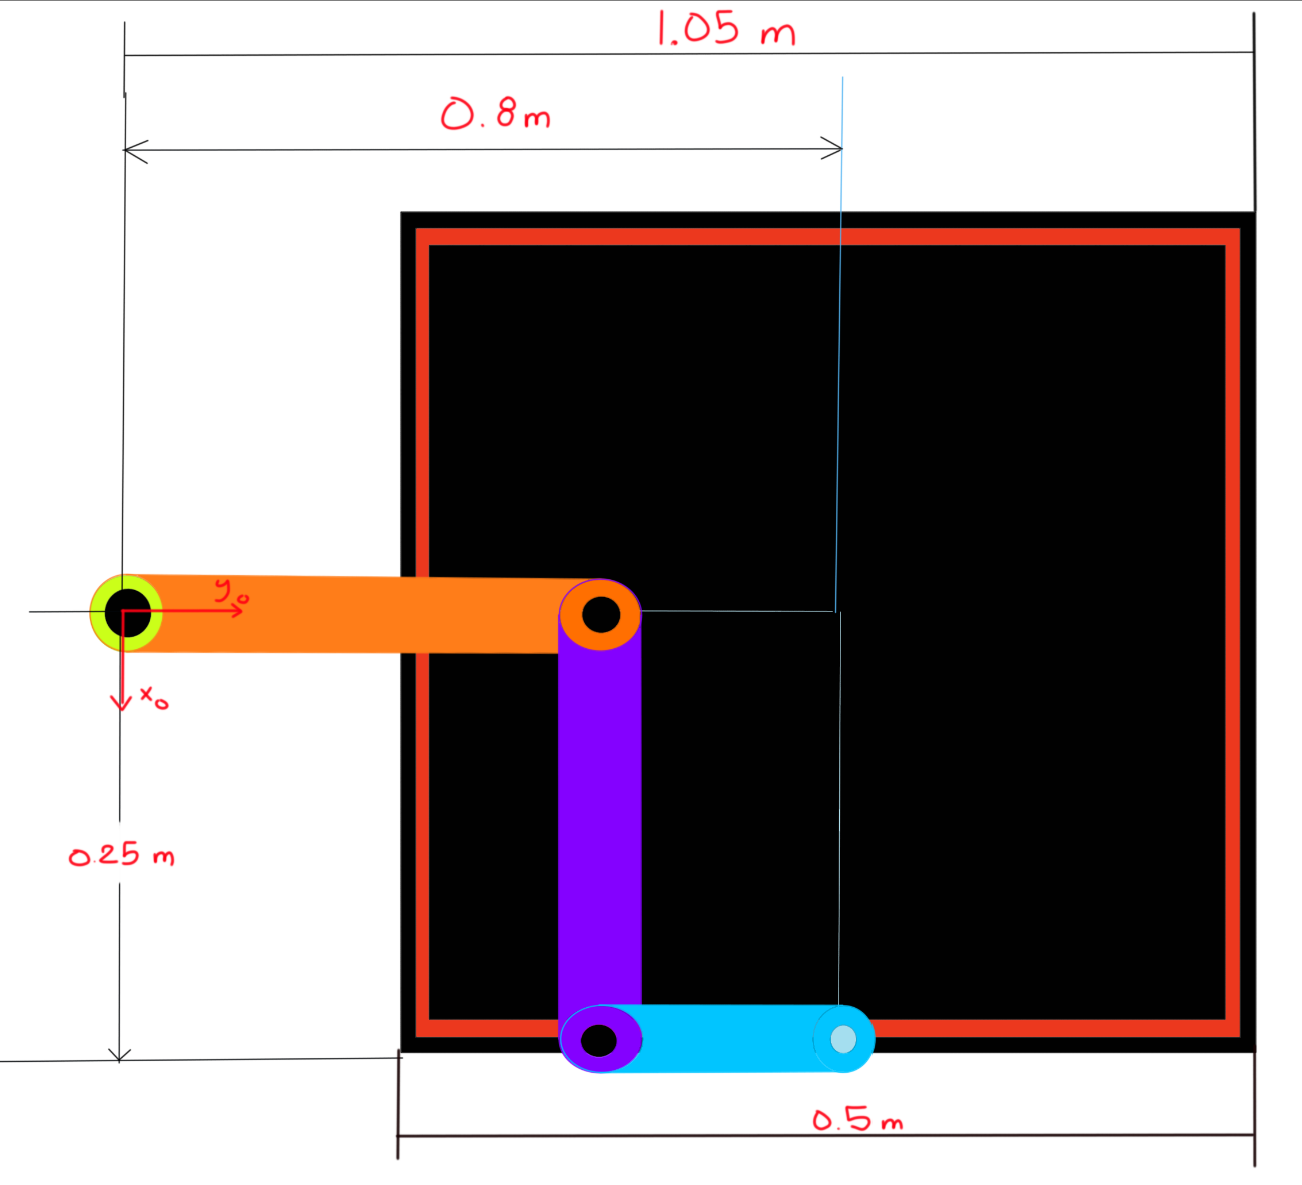
</p>

## Desarrollo

Para solucionar el problema se propone que el robot ejecute cinco trayectorias para recorrer todo el perímetro del cuadrado.


Las 5 trayectorias se analizarán considerando que la posición inicial es la que se mostró en la imagen anterior.

<p style="text-align:left">
   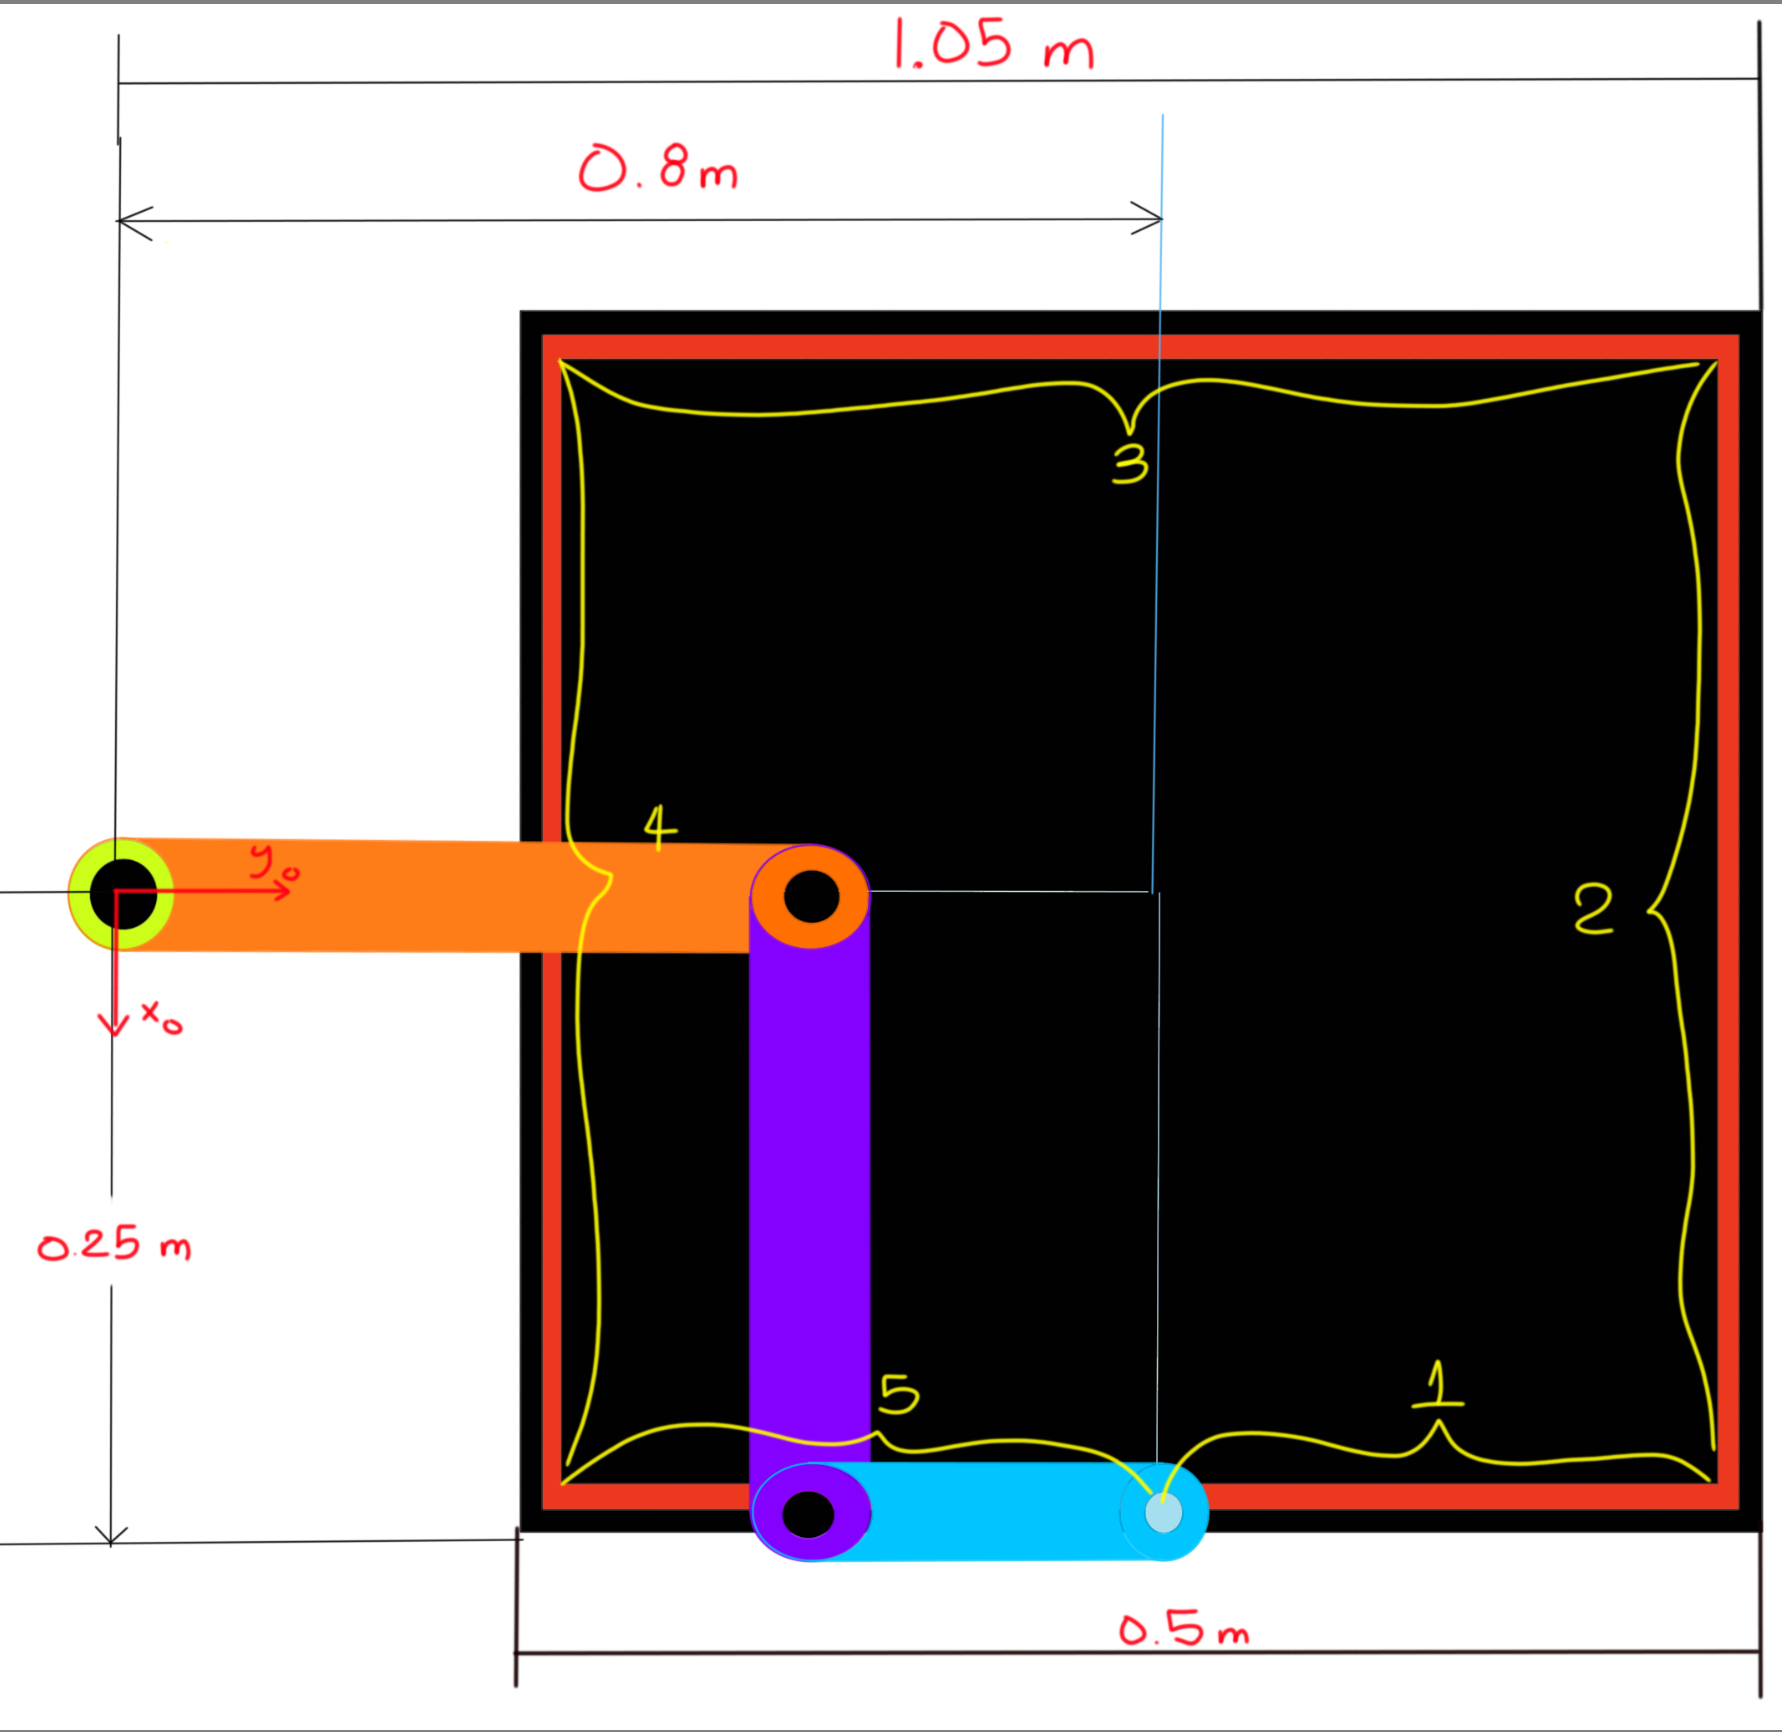
</p>


Las ecuaciones que se van a emplear para que el robot ejecute los movimientos son las siguientes:

-  Cálculo de la postura con el método geométrico

$${}^0x_3=x_p -L_3 \times \cos \left({}^0{\theta }_P\right)$$

$${}^0y_3=y_p -L_3 \times \cos \left({}^0{\theta }_P\right)$$

$${{}^1{\theta }_2}_{\mathrm{inicial},\mathrm{final}} =\mathrm{angcos}\left(\frac{\left({{}^0x_3}^2 +{{}^0y_3}^2 -L_1^2 -L_2^2 \right)}{2\times L_1 \times L_2 }\right)$$

$$\beta =\mathrm{angtan2}\left(y_{2,3} \;,x_{2,3} \right)$$

$$\psi =\mathrm{angcos}\left(\frac{{{}^0x_3}^2 +{{}^0y_3}^2 +L_1^2 -L_2^2 }{2\times L_1 \times \sqrt{{{}^0x_3}^2 +{{}^0y_3}^2 }}\right)$$

$${{}^0{\theta }_1}_{\mathrm{inicial},\mathrm{final}} =\beta +\psi$$

$${{}^2{\theta }_3}_{\mathrm{inicial},\mathrm{final}} ={}^0{\theta }_P-{}^0{\theta }_1-{}^1{\theta }_2$$

-  Perfil quintico de trayectoria

$${}^{i-1}{\theta }_i={{}^{i-1}{\theta }_i}_{\mathrm{inicial}} +\left(\left(\frac{10}{t_f^3 }\right)t^3 -\left(\frac{15}{t_f^4 }\right)t^4 +\left(\frac{6}{t_f^5 }\right)t^5 \right)\times \left({{}^{i-1}{\theta }_i}_{\mathrm{final}} -{{}^{i-1}{\theta }_i}_{\mathrm{inicial}} \right)\;\;\;;\;i=\left\lbrace 1,2,3\right\rbrace$$

$${}^{i-1}{\dot{\theta} }_i=\left(\left(\frac{30}{t_f^3 }\right)t^2 -\left(\frac{60}{t_f^4 }\right)t^3 +\left(\frac{30}{t_f^5 }\right)t^4 \right)\times \left({{}^{i-1}{\theta }_i}_{\mathrm{final}} -{{}^{i-1}{\theta }_i}_{\mathrm{inicial}} \right)\;\;\;;\;i=\left\lbrace 1,2,3\right\rbrace$$

$${}^{i-1}{\ddot{\theta} }_i=\left(\left(\frac{60}{t_f^3 }\right)t-\left(\frac{180}{t_f^4 }\right)t^2 +\left(\frac{120}{t_f^5 }\right)t^3 \right)\times \left({{}^{i-1}{\theta }_i}_{\mathrm{final}} -{{}^{i-1}{\theta }_i}_{\mathrm{inicial}} \right)\;\;\;;\;i=\left\lbrace 1,2,3\right\rbrace$$

-  Par para cada una de las juntas. NOTA: las masas y los momentos de inercia se consideraron unitarias.

$${\ddot{\theta} }_{O,1} \,{\left(I_{\mathrm{zz1}} +I_{\mathrm{zz2}} +I_{\mathrm{zz3}} +m_3 \,{\sigma_{12} }^2 +{L_1 }^2 \,m_2 +m_3 \,{\sigma_{14} }^2 +m_1 \,{x_{1,\mathrm{C1}} }^2 +m_2 \,{x_{2,\mathrm{C2}} }^2 +2\,L_1 \,m_2 \,x_{2,\mathrm{C2}} \,\cos \left(\theta_{1,2} \right)\right)}-{\dot{\theta} }_{1,2} \,{\left(m_3 \,\sigma_2 \,\sigma_{12} -m_3 \,\sigma_{14} \,\sigma_1 -\sigma_9 +\sigma_8 +L_1 \,m_2 \,{\dot{\theta} }_{1,2} \,x_{2,\mathrm{C2}} \,\sin \left(\theta_{1,2} \right)+2\,L_1 \,m_2 \,{\dot{\theta} }_{O,1} \,x_{2,\mathrm{C2}} \,\sin \left(\theta_{1,2} \right)\right)}+{\ddot{\theta} }_{1,2} \,\sigma_3 -{\dot{\theta} }_{2,3} \,{\left(m_3 \,\sigma_{12} \,\sigma_5 -m_3 \,\sigma_{14} \,\sigma_4 -m_3 \,x_{3,\mathrm{C3}} \,\sigma_{16} \,\sigma_{11} +m_3 \,x_{3,\mathrm{C3}} \,\sigma_{18} \,\sigma_{10} \right)}+{\ddot{\theta} }_{2,3} \,\sigma_7 +g\,m_3 \,\sigma_{12} +g\,m_2 \,{\left(x_{2,\mathrm{C2}} \,\cos \left(\theta_{1,2} +\theta_{O,1} \right)+L_1 \,\cos \left(\theta_{O,1} \right)\right)}+g\,m_1 \,x_{1,\mathrm{C1}} \,\cos \left(\theta_{O,1} \right)$$

$${\ddot{\theta} }_{1,2} \,{\left(I_{\mathrm{zz2}} +I_{\mathrm{zz3}} +m_2 \,{x_{2,\mathrm{C2}} }^2 +m_3 \,{{\left(\sigma_{17} +x_{3,\mathrm{C3}} \,\sigma_{16} \right)}}^2 +m_3 \,{{\left(x_{3,\mathrm{C3}} \,\sigma_{18} +\sigma_{19} \right)}}^2 \right)}-{\dot{\theta} }_{1,2} \,{\left(m_3 \,{\left(\sigma_{17} +x_{3,\mathrm{C3}} \,\sigma_{16} \right)}\,\sigma_2 -m_3 \,{\left(x_{3,\mathrm{C3}} \,\sigma_{18} +\sigma_{19} \right)}\,\sigma_1 -\sigma_9 +\sigma_8 +L_1 \,m_2 \,{\dot{\theta} }_{O,1} \,x_{2,\mathrm{C2}} \,\sin \left(\theta_{1,2} \right)\right)}+{\ddot{\theta} }_{O,1} \,\sigma_3 +{\dot{\theta} }_{2,3} \,{\left(m_3 \,{\left(x_{3,\mathrm{C3}} \,\sigma_{18} +\sigma_{19} \right)}\,\sigma_4 -m_3 \,{\left(\sigma_{17} +x_{3,\mathrm{C3}} \,\sigma_{16} \right)}\,\sigma_5 +m_3 \,x_{3,\mathrm{C3}} \,\sigma_{16} \,\sigma_{11} -m_3 \,x_{3,\mathrm{C3}} \,\sigma_{18} \,\sigma_{10} \right)}+{\ddot{\theta} }_{2,3} \,\sigma_6 +m_3 \,\sigma_2 \,\sigma_{10} -m_3 \,\sigma_{11} \,\sigma_1 +g\,m_3 \,{\left(\sigma_{17} +x_{3,\mathrm{C3}} \,\sigma_{16} \right)}+g\,m_2 \,x_{2,\mathrm{C2}} \,\cos \left(\theta_{1,2} +\theta_{O,1} \right)+L_1 \,m_2 \,{{\dot{\theta} }_{O,1} }^2 \,x_{2,\mathrm{C2}} \,\sin \left(\theta_{1,2} \right)+L_1 \,m_2 \,{\dot{\theta} }_{1,2} \,{\dot{\theta} }_{O,1} \,x_{2,\mathrm{C2}} \,\sin \left(\theta_{1,2} \right)$$

$${\dot{\theta} }_{2,3} \,{\left(m_3 \,x_{3,\mathrm{C3}} \,\sigma_{18} \,\sigma_4 +m_3 \,x_{3,\mathrm{C3}} \,\sigma_{16} \,\sigma_{11} -m_3 \,x_{3,\mathrm{C3}} \,\sigma_{16} \,\sigma_5 -m_3 \,x_{3,\mathrm{C3}} \,\sigma_{18} \,\sigma_{10} \right)}+{\ddot{\theta} }_{1,2} \,\sigma_6 +{\ddot{\theta} }_{2,3} \,{\left(m_3 \,{x_{3,\mathrm{C3}} }^2 \,{\sigma_{16} }^2 +m_3 \,{x_{3,\mathrm{C3}} }^2 \,{\sigma_{18} }^2 +I_{\mathrm{zz3}} \right)}+{\dot{\theta} }_{1,2} \,{\left(m_3 \,x_{3,\mathrm{C3}} \,\sigma_{16} \,\sigma_{11} +m_3 \,x_{3,\mathrm{C3}} \,\sigma_{18} \,\sigma_1 -m_3 \,x_{3,\mathrm{C3}} \,\sigma_{16} \,\sigma_2 -m_3 \,x_{3,\mathrm{C3}} \,\sigma_{18} \,\sigma_{10} \right)}+{\ddot{\theta} }_{O,1} \,\sigma_7 -m_3 \,\sigma_4 \,\sigma_{11} +m_3 \,\sigma_{10} \,\sigma_5 +g\,m_3 \,x_{3,\mathrm{C3}} \,\sigma_{16}$$

**donde:**


$$\sigma_1 =\sigma_{13} +{\dot{\theta} }_{O,1} \,{\left(\sigma_{17} +x_{3,\mathrm{C3}} \,\sigma_{16} \right)}+{\dot{\theta} }_{2,3} \,x_{3,\mathrm{C3}} \,\sigma_{16}$$

$$\sigma_2 =\sigma_{15} +{\dot{\theta} }_{O,1} \,{\left(x_{3,\mathrm{C3}} \,\sigma_{18} +\sigma_{19} \right)}+{\dot{\theta} }_{2,3} \,x_{3,\mathrm{C3}} \,\sigma_{18}$$

$$\sigma_3 =m_2 \,{x_{2,\mathrm{C2}} }^2 +L_1 \,m_2 \,\cos \left(\theta_{1,2} \right)\,x_{2,\mathrm{C2}} +I_{\mathrm{zz2}} +I_{\mathrm{zz3}} +m_3 \,{\left(\sigma_{17} +x_{3,\mathrm{C3}} \,\sigma_{16} \right)}\,\sigma_{12} +m_3 \,{\left(x_{3,\mathrm{C3}} \,\sigma_{18} +\sigma_{19} \right)}\,\sigma_{14}$$

$$\sigma_4 ={\dot{\theta} }_{1,2} \,x_{3,\mathrm{C3}} \,\sigma_{16} +{\dot{\theta} }_{2,3} \,x_{3,\mathrm{C3}} \,\sigma_{16} +{\dot{\theta} }_{O,1} \,x_{3,\mathrm{C3}} \,\sigma_{16}$$

$$\sigma_5 ={\dot{\theta} }_{1,2} \,x_{3,\mathrm{C3}} \,\sigma_{18} +{\dot{\theta} }_{2,3} \,x_{3,\mathrm{C3}} \,\sigma_{18} +{\dot{\theta} }_{O,1} \,x_{3,\mathrm{C3}} \,\sigma_{18}$$

$$\sigma_6 =I_{\mathrm{zz3}} +m_3 \,x_{3,\mathrm{C3}} \,\sigma_{16} \,{\left(\sigma_{17} +x_{3,\mathrm{C3}} \,\sigma_{16} \right)}+m_3 \,x_{3,\mathrm{C3}} \,\sigma_{18} \,{\left(x_{3,\mathrm{C3}} \,\sigma_{18} +\sigma_{19} \right)}$$

$$\sigma_7 =I_{\mathrm{zz3}} +m_3 \,x_{3,\mathrm{C3}} \,\sigma_{16} \,\sigma_{12} +m_3 \,x_{3,\mathrm{C3}} \,\sigma_{18} \,\sigma_{14}$$

$$\sigma_8 =m_3 \,{\left(x_{3,\mathrm{C3}} \,\sigma_{18} +\sigma_{19} \right)}\,\sigma_{10}$$

$$\sigma_9 =m_3 \,{\left(\sigma_{17} +x_{3,\mathrm{C3}} \,\sigma_{16} \right)}\,\sigma_{11}$$

$$\sigma_{10} ={\dot{\theta} }_{O,1} \,\sigma_{12} +\sigma_{13} +{\dot{\theta} }_{2,3} \,x_{3,\mathrm{C3}} \,\sigma_{16}$$

$$\sigma_{11} ={\dot{\theta} }_{O,1} \,\sigma_{14} +\sigma_{15} +{\dot{\theta} }_{2,3} \,x_{3,\mathrm{C3}} \,\sigma_{18}$$

$$\sigma_{12} =\sigma_{17} +L_1 \,\cos \left(\theta_{O,1} \right)+x_{3,\mathrm{C3}} \,\sigma_{16}$$

$$\sigma_{13} ={\dot{\theta} }_{1,2} \,{\left(\sigma_{17} +x_{3,\mathrm{C3}} \,\sigma_{16} \right)}$$

$$\sigma_{14} =x_{3,\mathrm{C3}} \,\sigma_{18} +\sigma_{19} +L_1 \,\sin \left(\theta_{O,1} \right)$$

$$\sigma_{15} ={\dot{\theta} }_{1,2} \,{\left(x_{3,\mathrm{C3}} \,\sigma_{18} +\sigma_{19} \right)}$$

$$\sigma_{16} =\cos \left(\theta_{1,2} +\theta_{2,3} +\theta_{O,1} \right)$$

$$\sigma_{17} =L_2 \,\cos \left(\theta_{1,2} +\theta_{O,1} \right)$$

$$\sigma_{18} =\sin \left(\theta_{1,2} +\theta_{2,3} +\theta_{O,1} \right)$$

-  Potencia

$$P_i =|\tau_i \times {}^{i-1}{\dot{\theta} }_i|$$

$$P_{\mathrm{Total}} =\sum_{i=1}^3 P_i$$
###     Características del robot
-  Longitud del primer eslabón (L1): 0.5 \[m\]
-  Longitud del segundo eslabón (L2): 0.5 \[m\]
-  Longitud del tercer eslabón (L3): 0.2 \[m\]

Se plantea utilizar estas ecuaciones para cada una de las trayectorias del robot, obtener el índice de manipulabilidad de cada trayectoria y comparar las potencias de modo que se pueda concluir qué tan accesible es que el robot haga esta tarea y se obtengan los requerimientos necesarios para los motores a utilizar en las juntas del robot SCARA.

## Resultados

El siguiente es un enlace a un video en Youtube de cómo se intentó simular que un robot SCARA en un ambiente de simulación de Gazebo realizara la tarea de seguir esta trayectoria cuadrada:


A continuación se muestran las gráficas de:

-  Planeación de movimientos en el espacio articular.
-  Planeación de movimientos en el espacio de trabajo.
-  Velocidades desde el espacio articular.
-  Aceleraciones desde el espacio articular.
-  Velocidades desde el espacio de trabajo.
-  Índice de manipulabilidad.
-  Par de las articulaciones.
-  Potencia en las articulaciones y potencia total.

Para cada una de las 5 trayectorias planteadas para la tarea del robot SCARA.

### Planeación de movimientos en el espacio articular
<p style="text-align:left">
   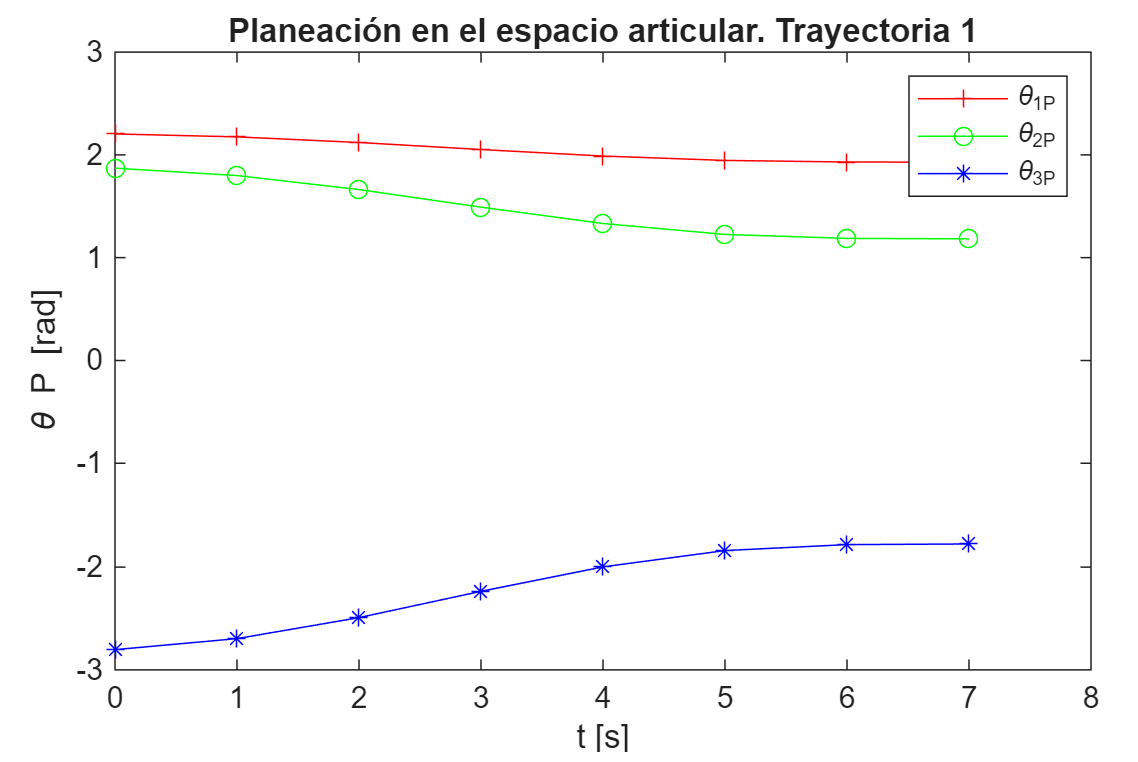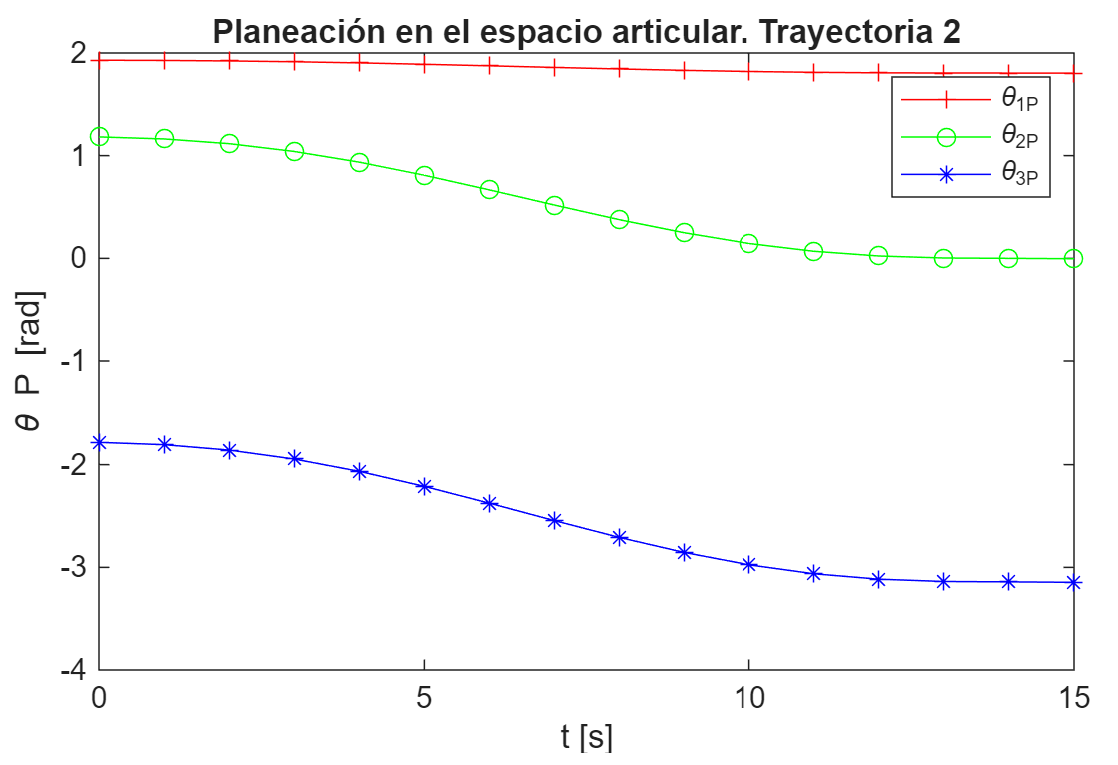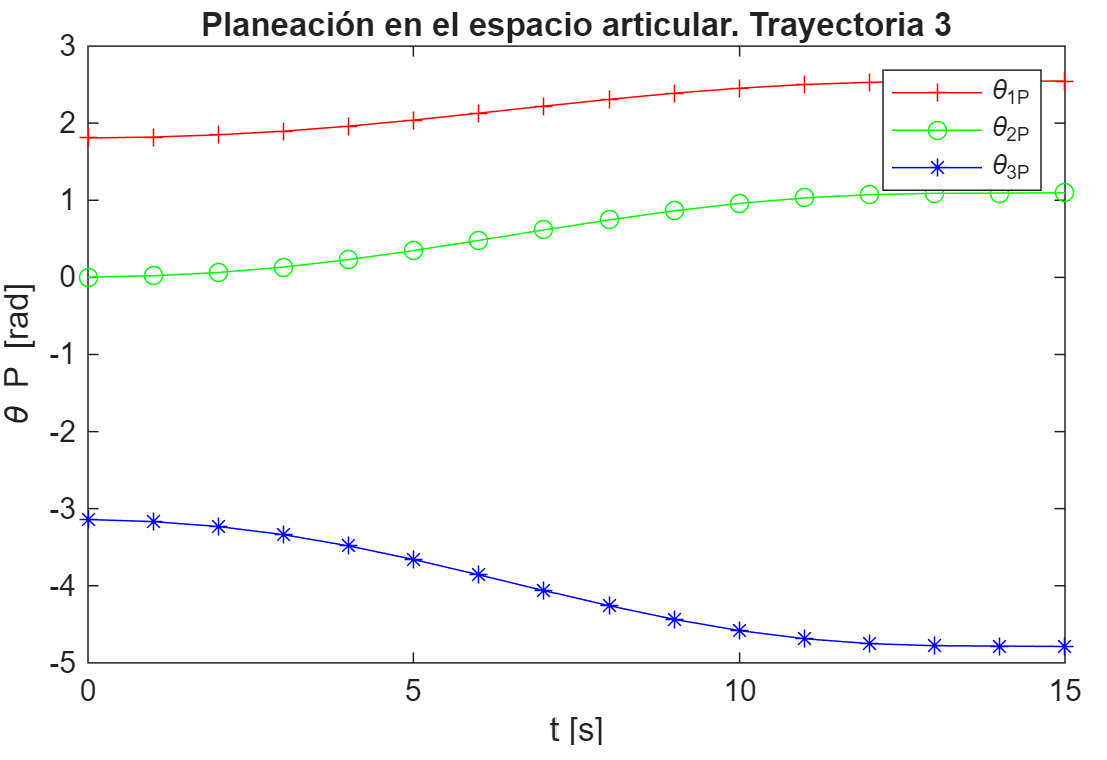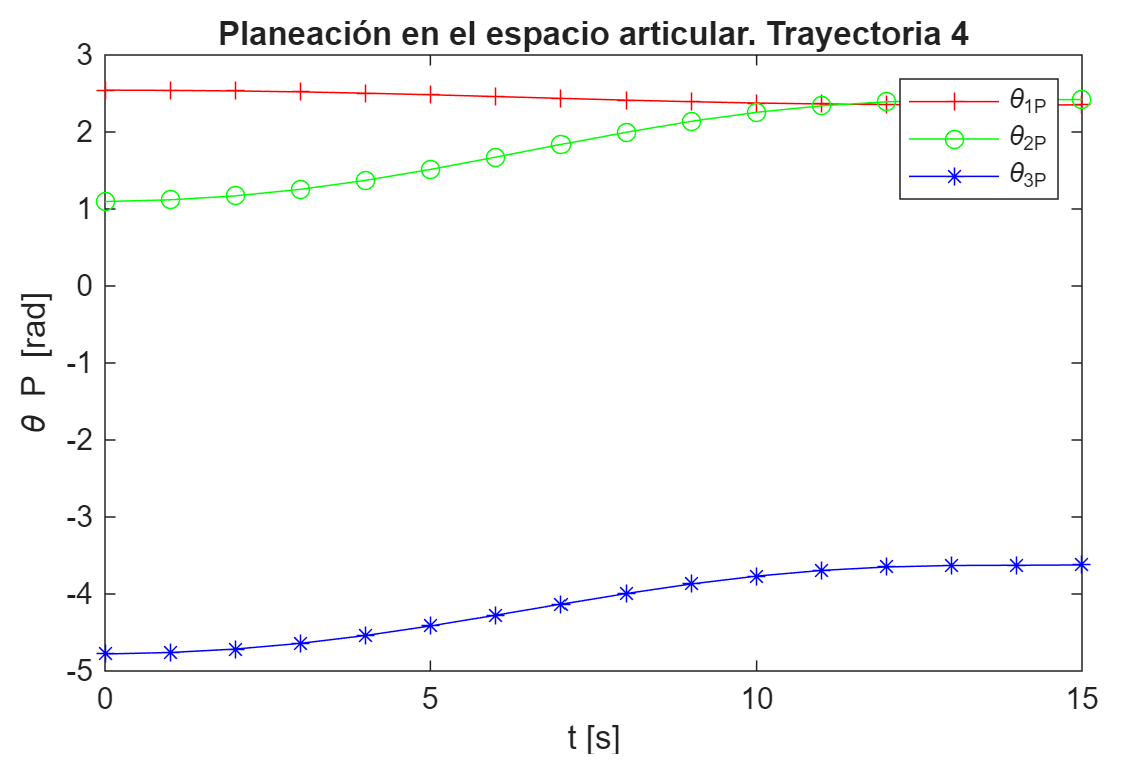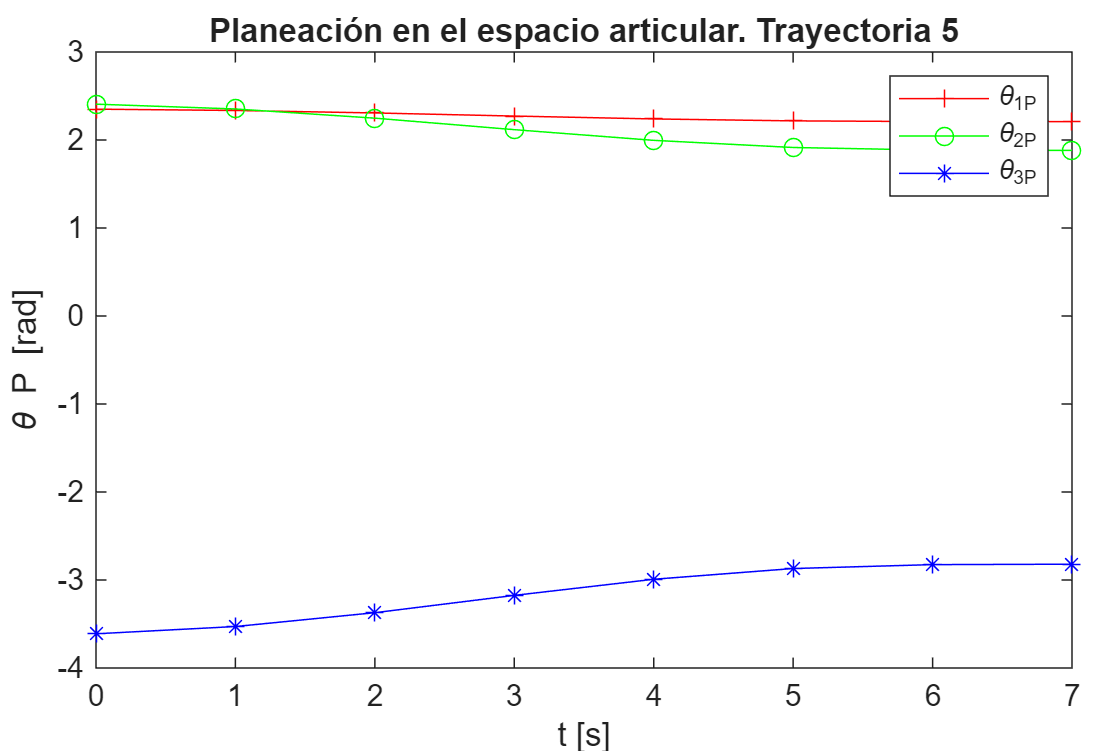
</p>

### Planeación de movimientos en el espacio de trabajo.
<p style="text-align:left">
   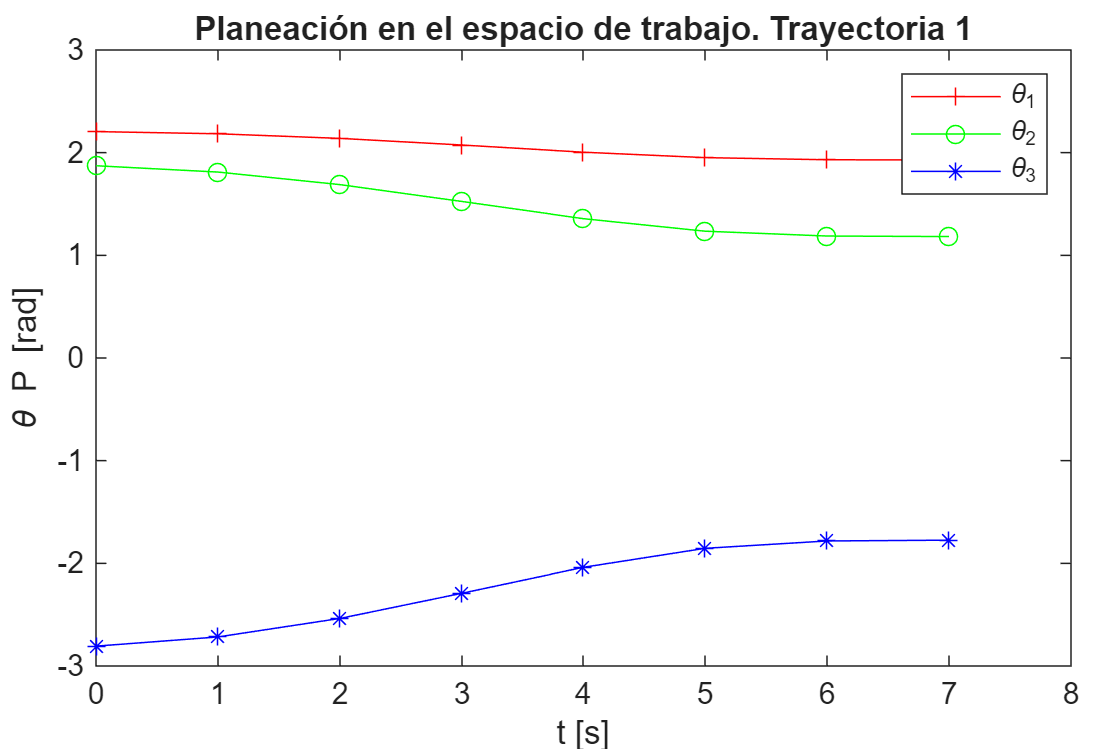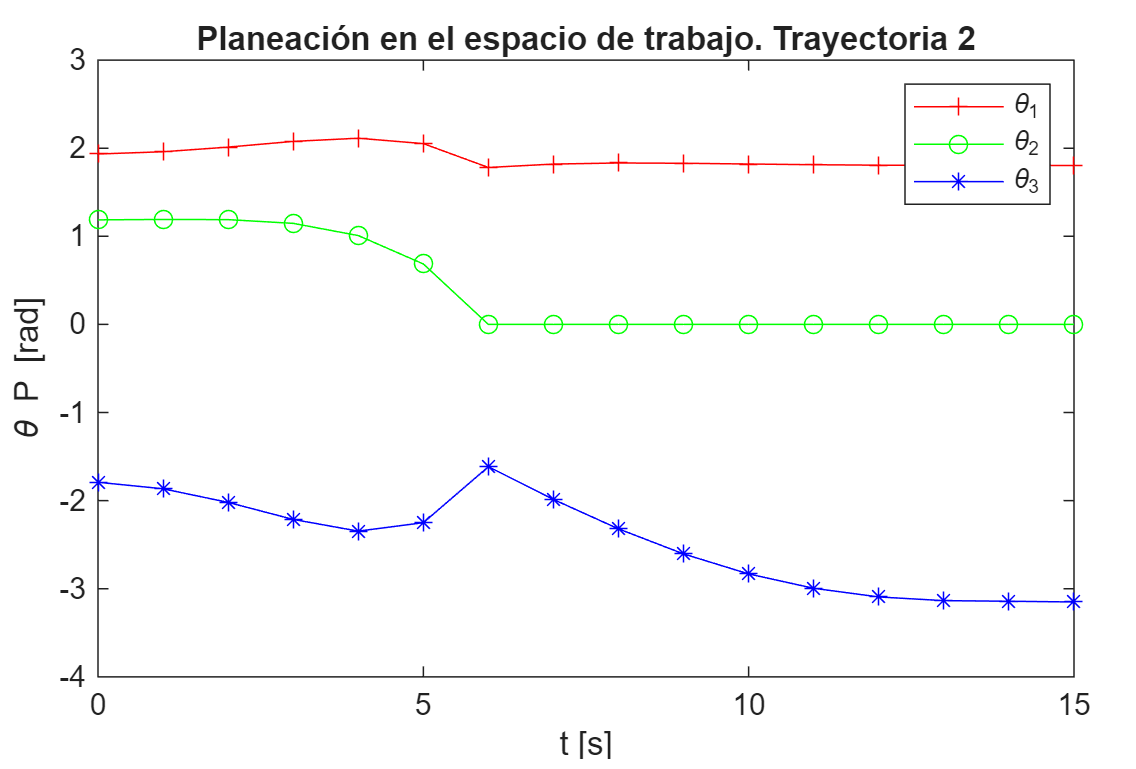
</p>


<p style="text-align:left">
   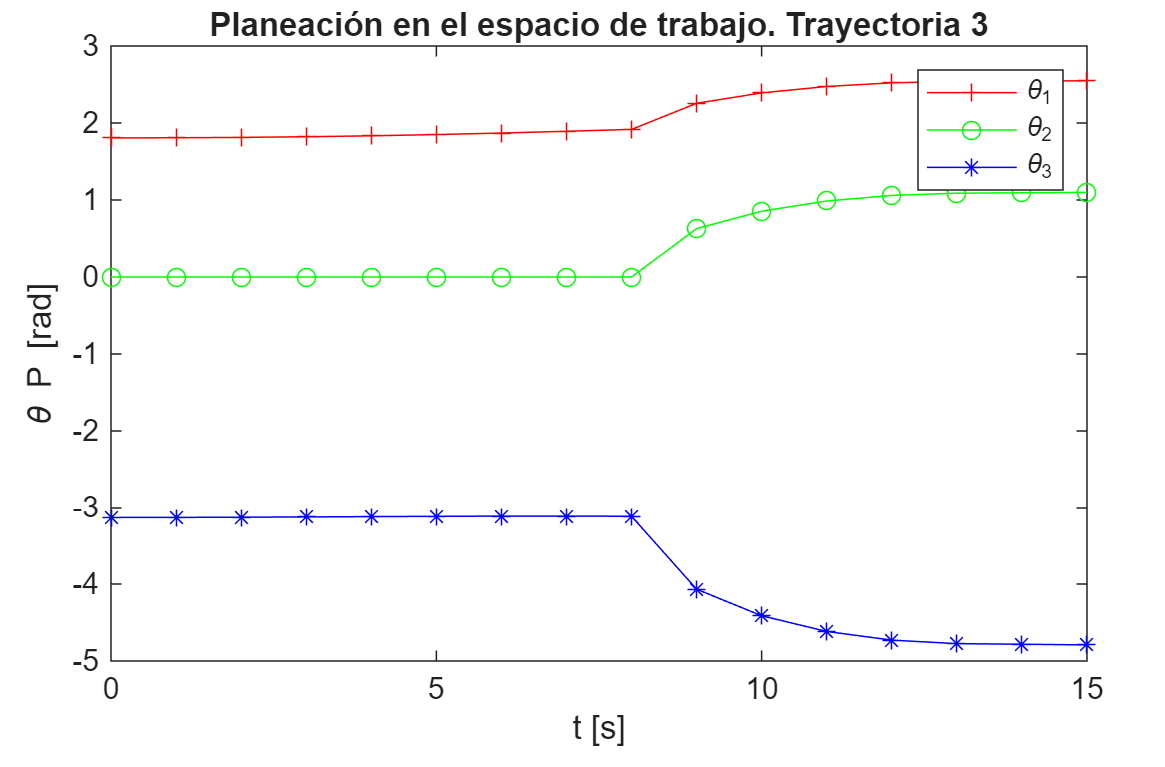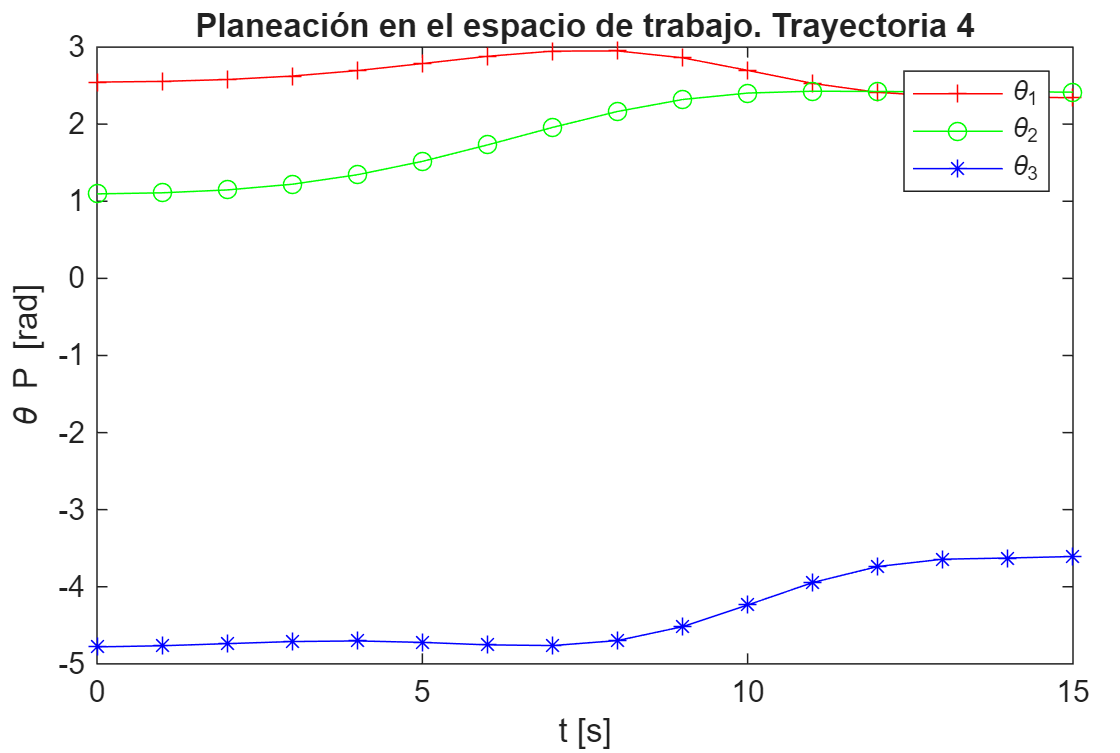
</p>


<p style="text-align:left">
   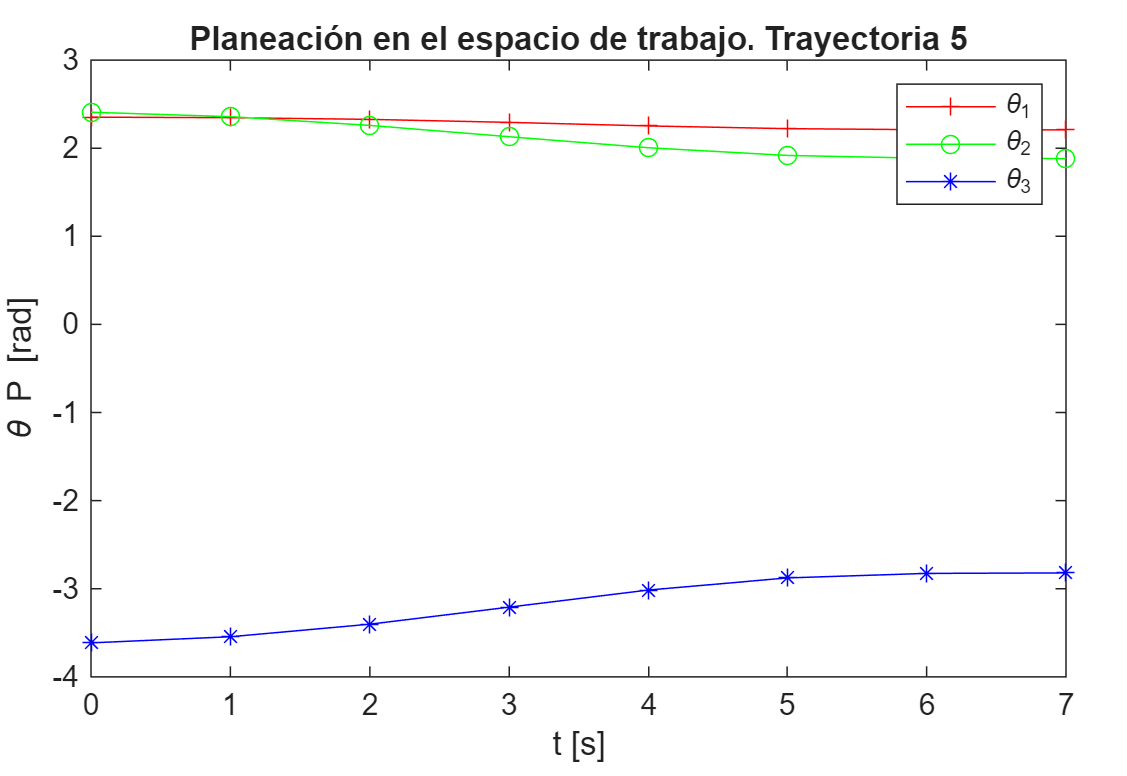
</p>

### Velocidades desde el espacio articular.
<p style="text-align:left">
   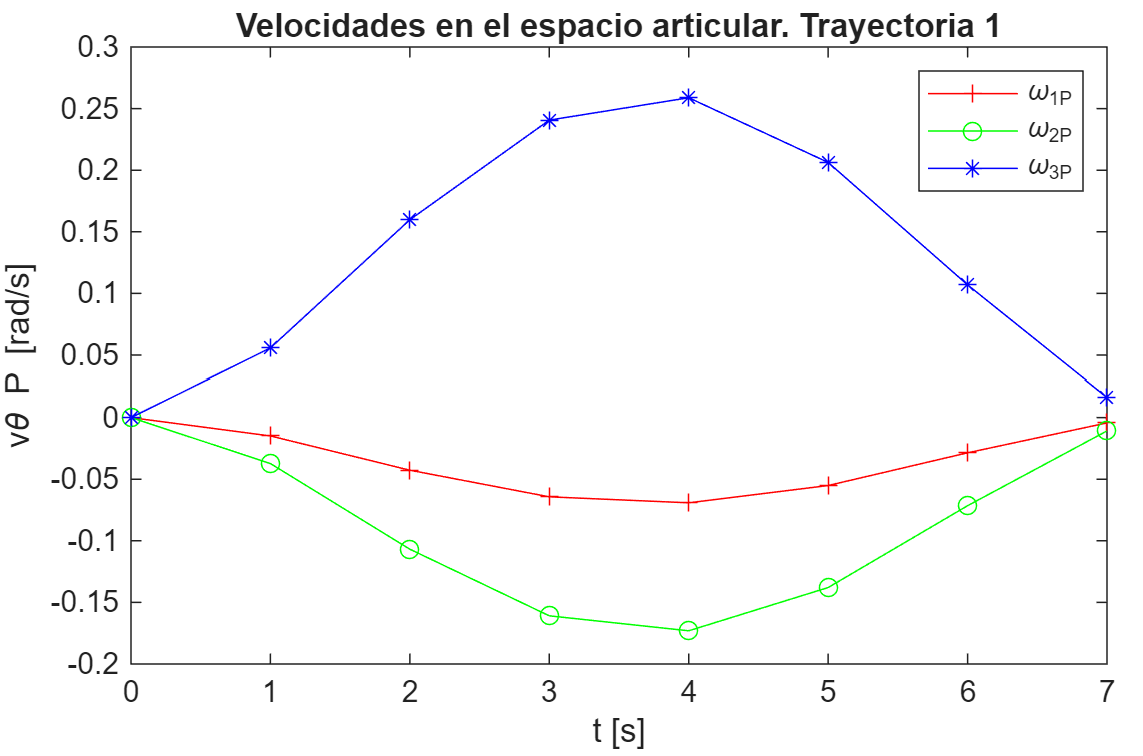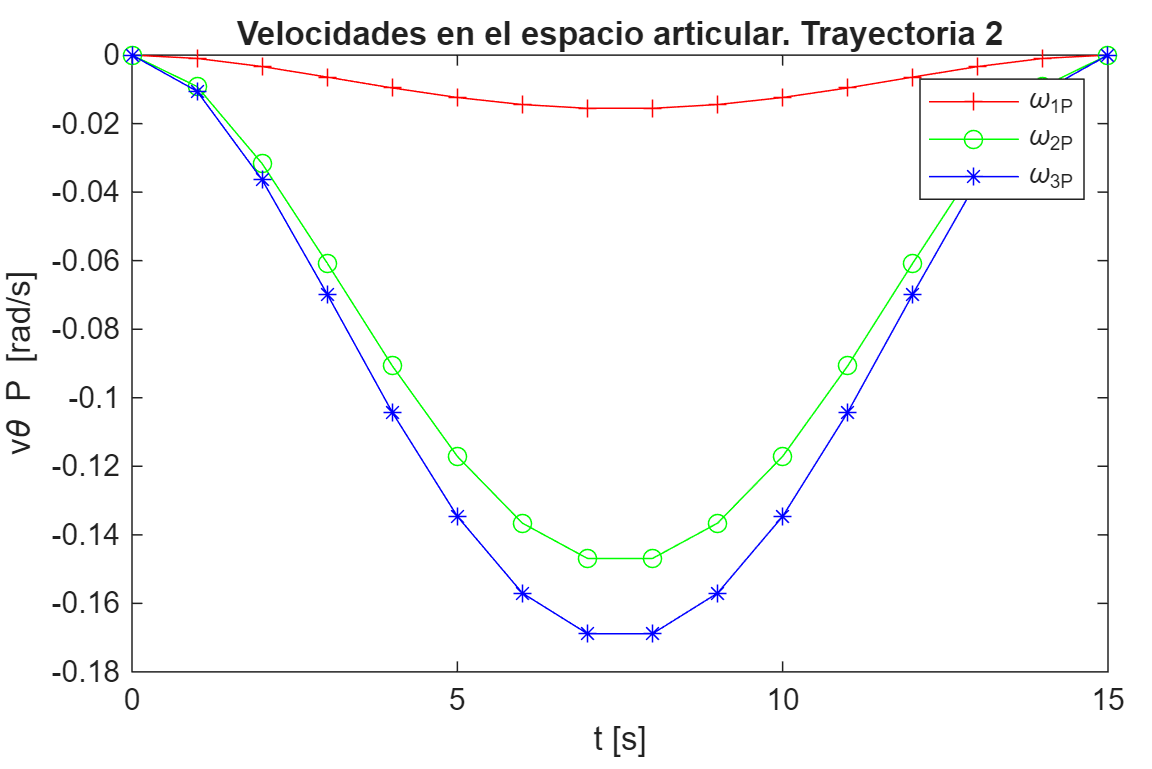
</p>


<p style="text-align:left">
   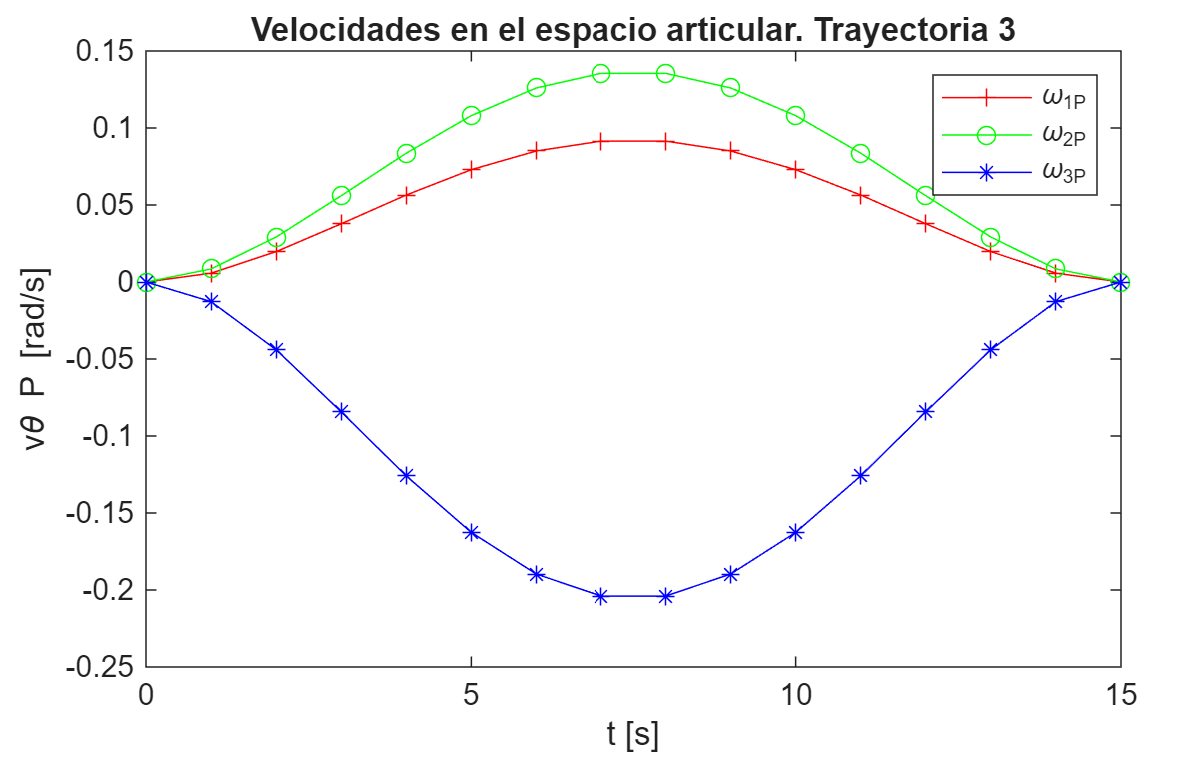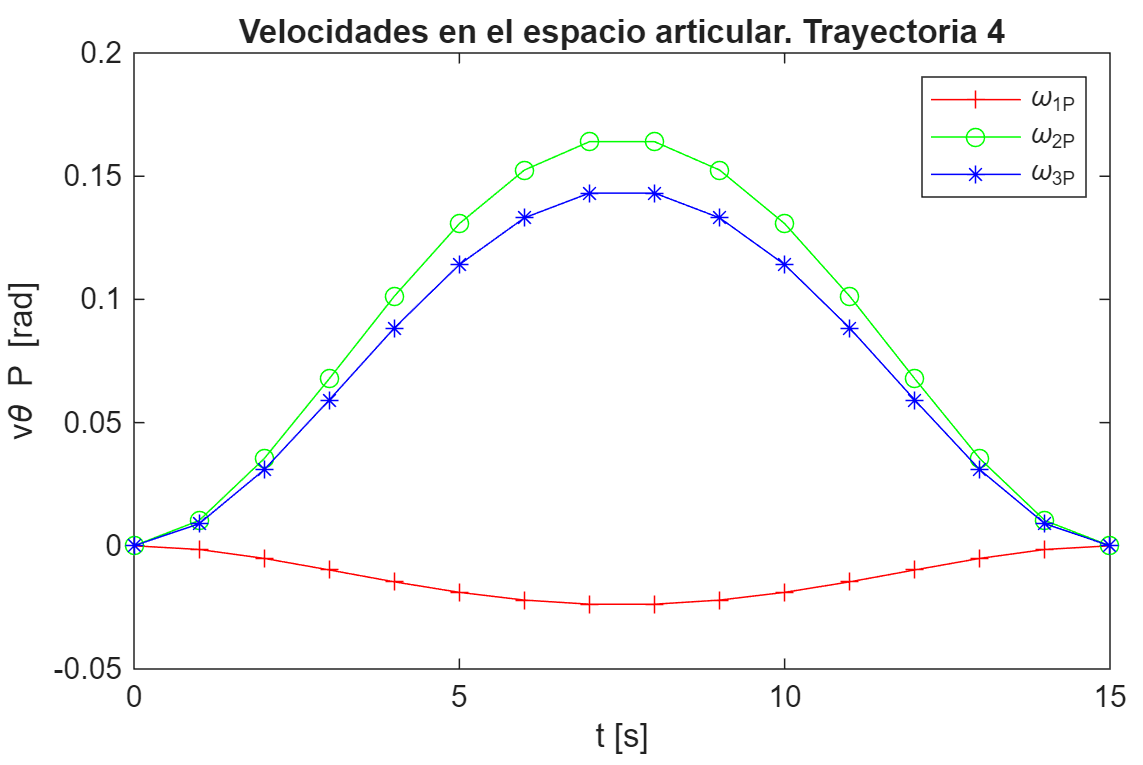
</p>


<p style="text-align:left">
   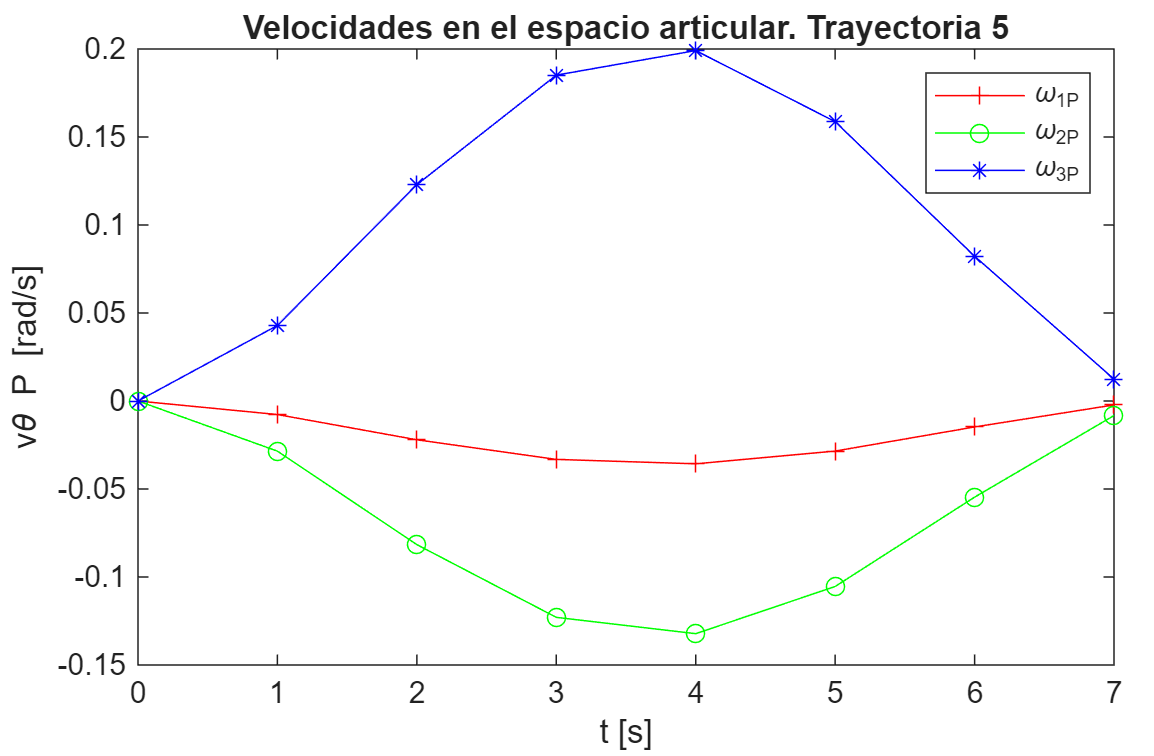
</p>

### Velocidades desde el espacio de trabajo
<p style="text-align:left">
   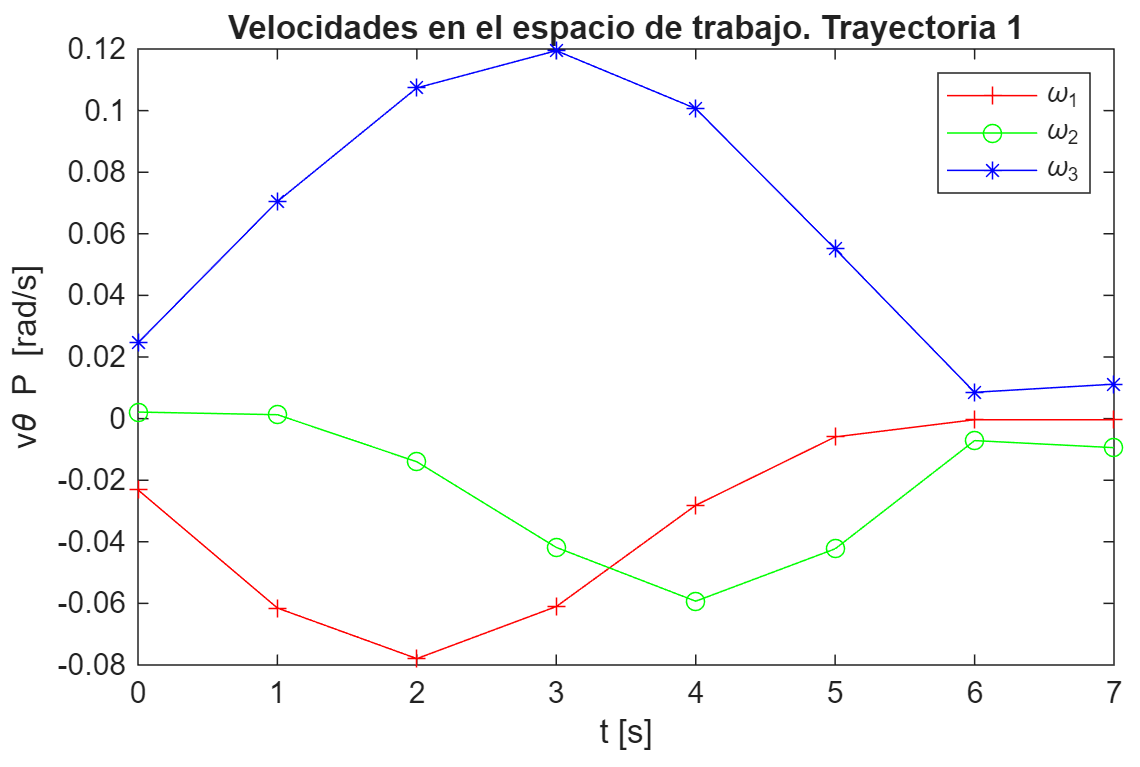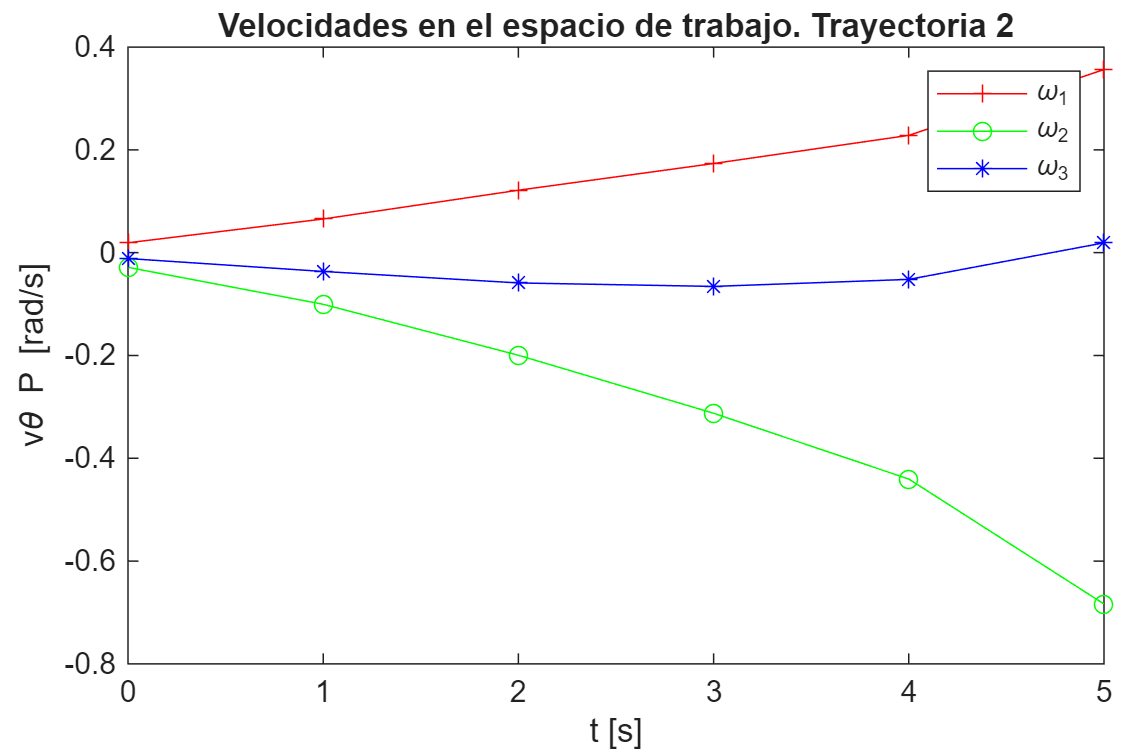
</p>


<p style="text-align:left">
   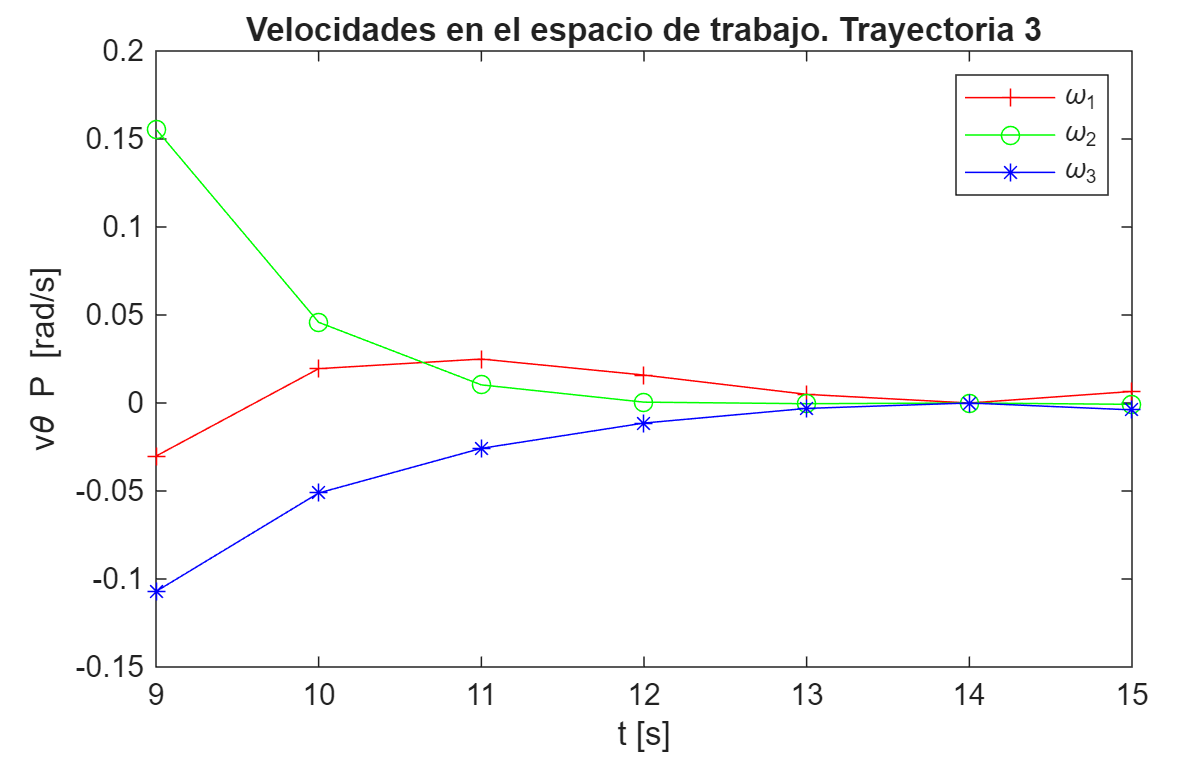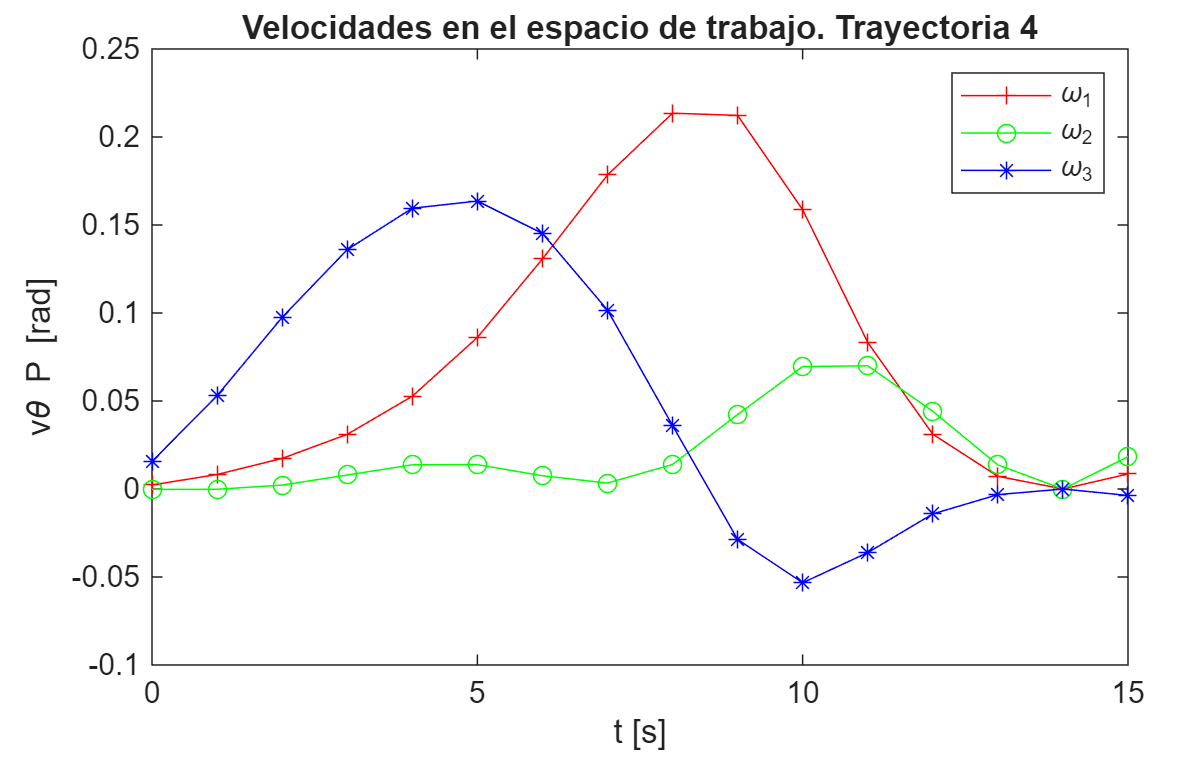
</p>


<p style="text-align:left">
   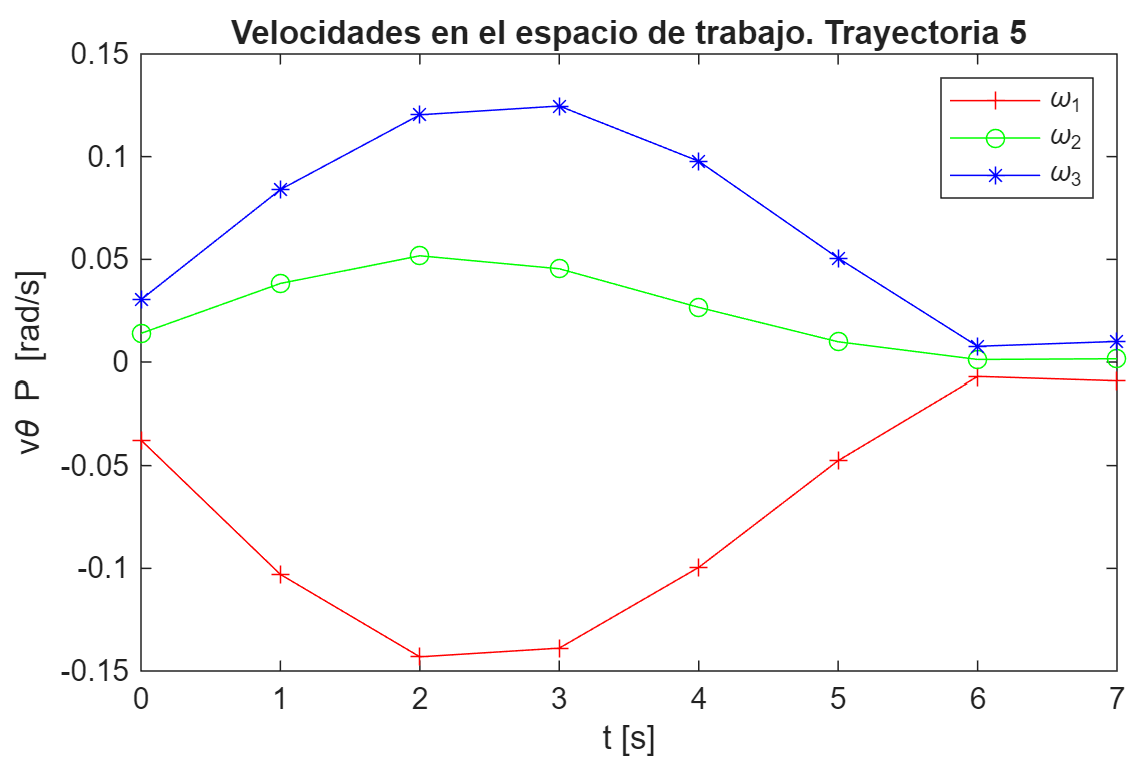
</p>

### Aceleraciones desde el espacio articular
<p style="text-align:left">
   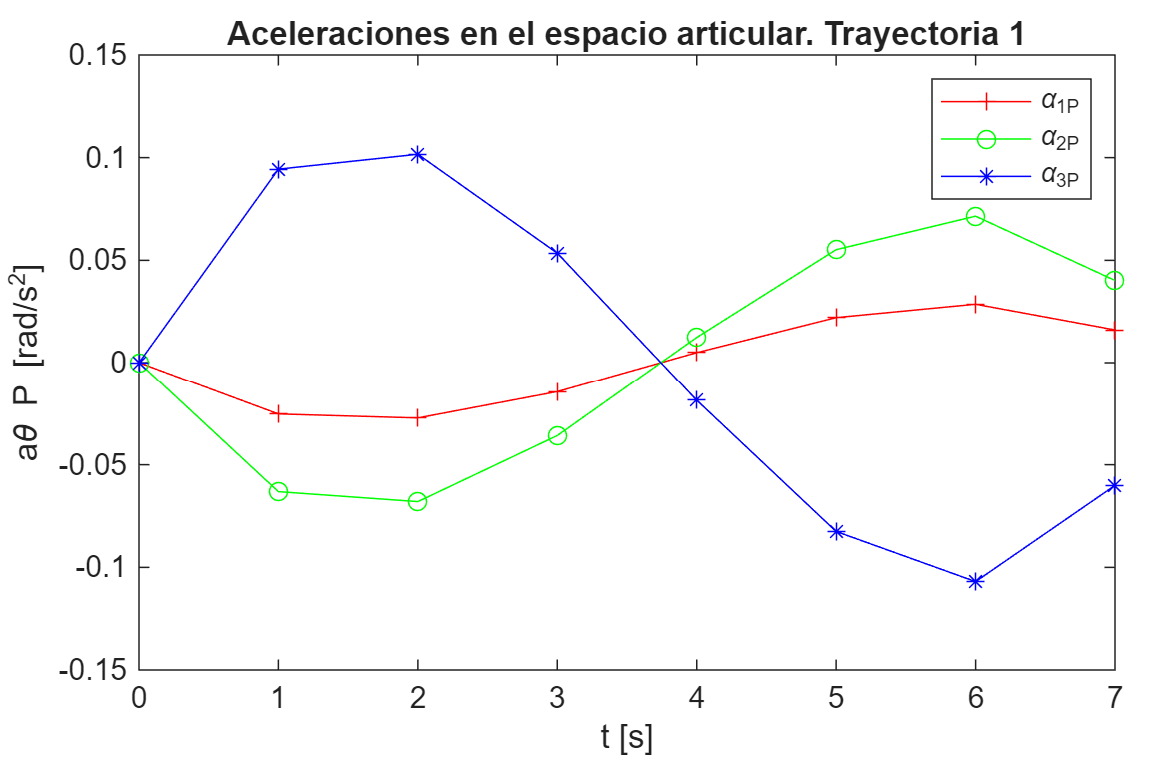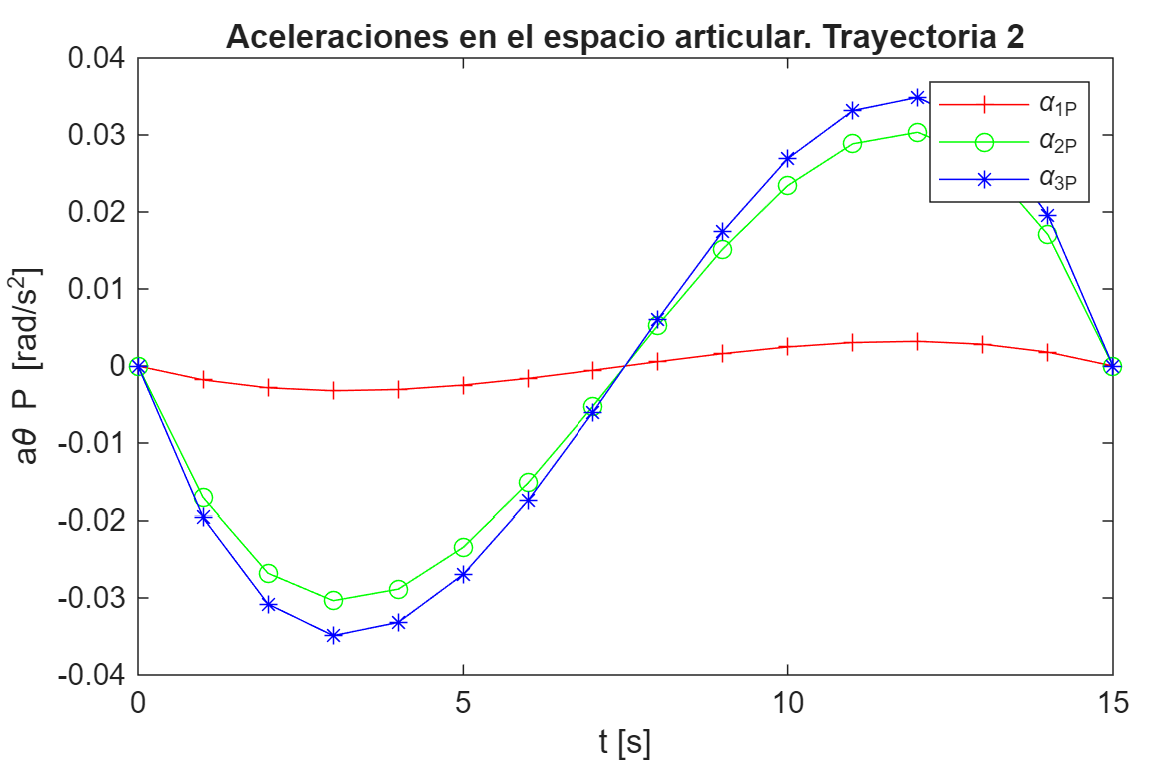
</p>


<p style="text-align:left">
   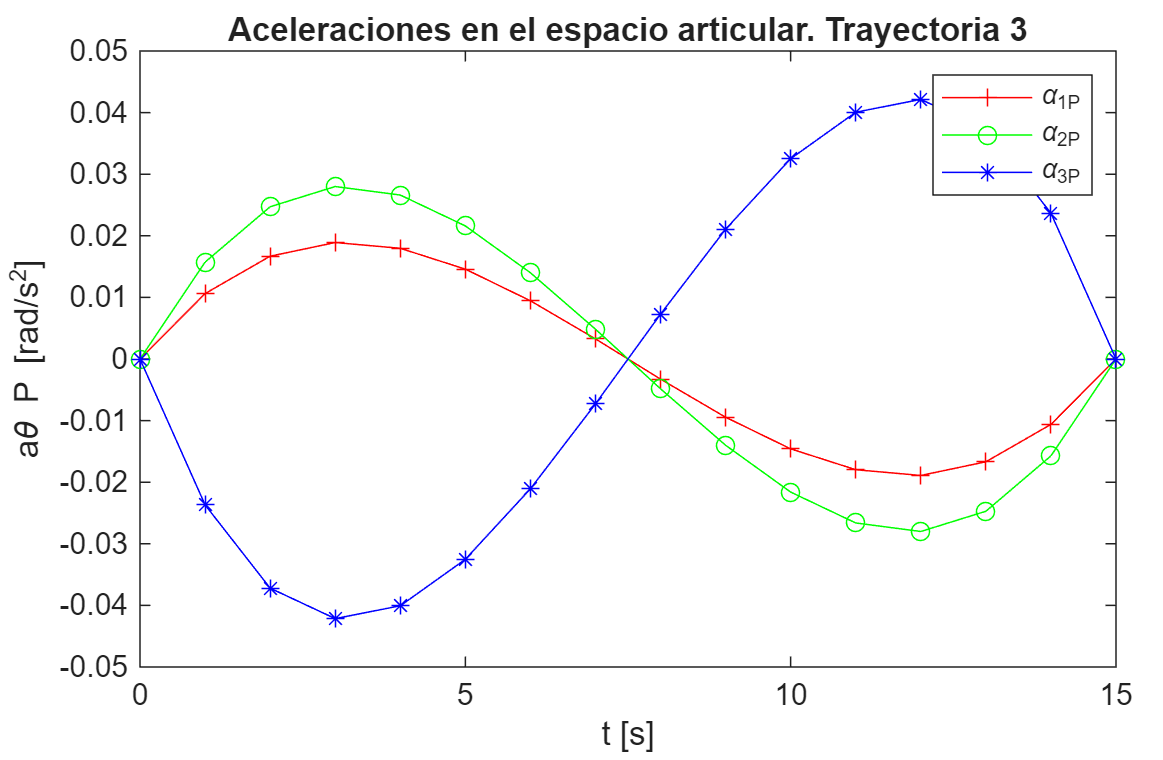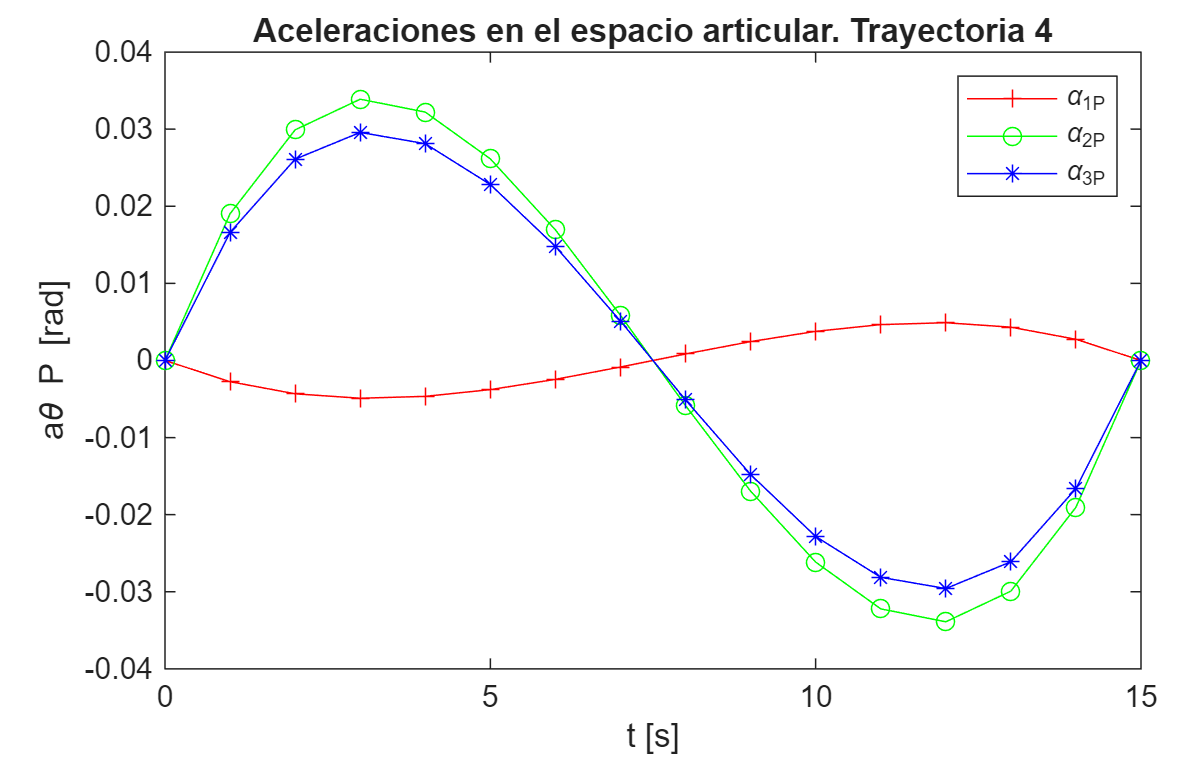
</p>


<p style="text-align:left">
   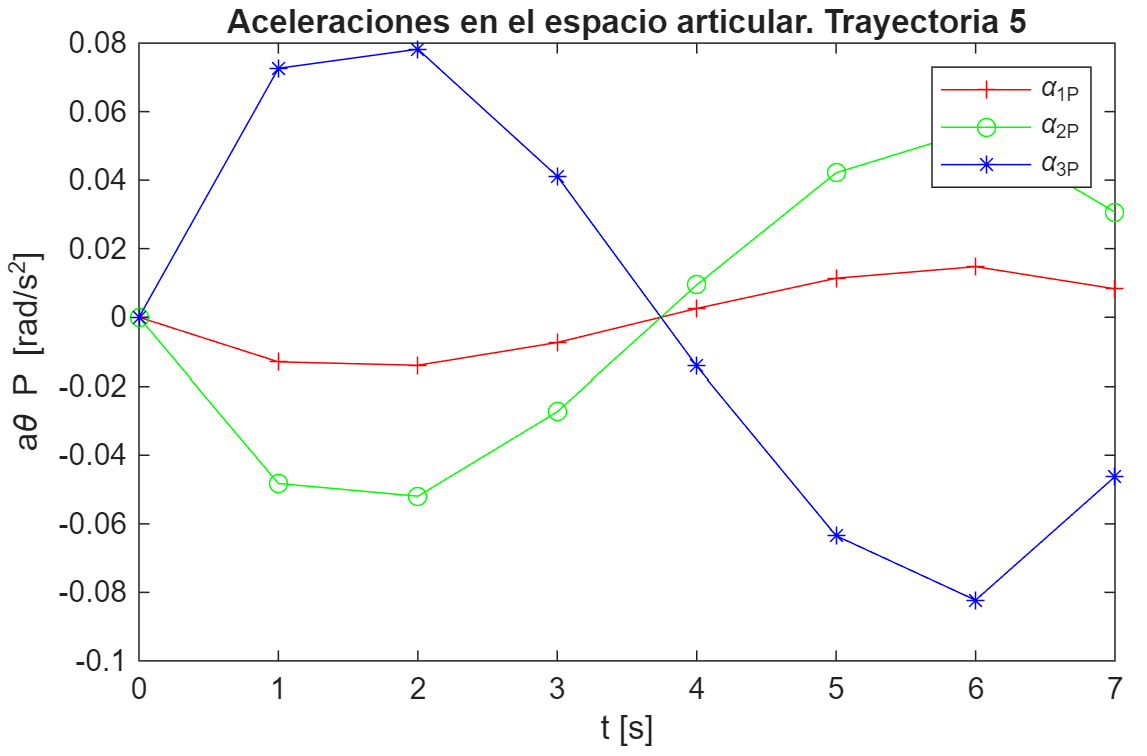
</p>

### Índice de manipulabilidad
<p style="text-align:left">
   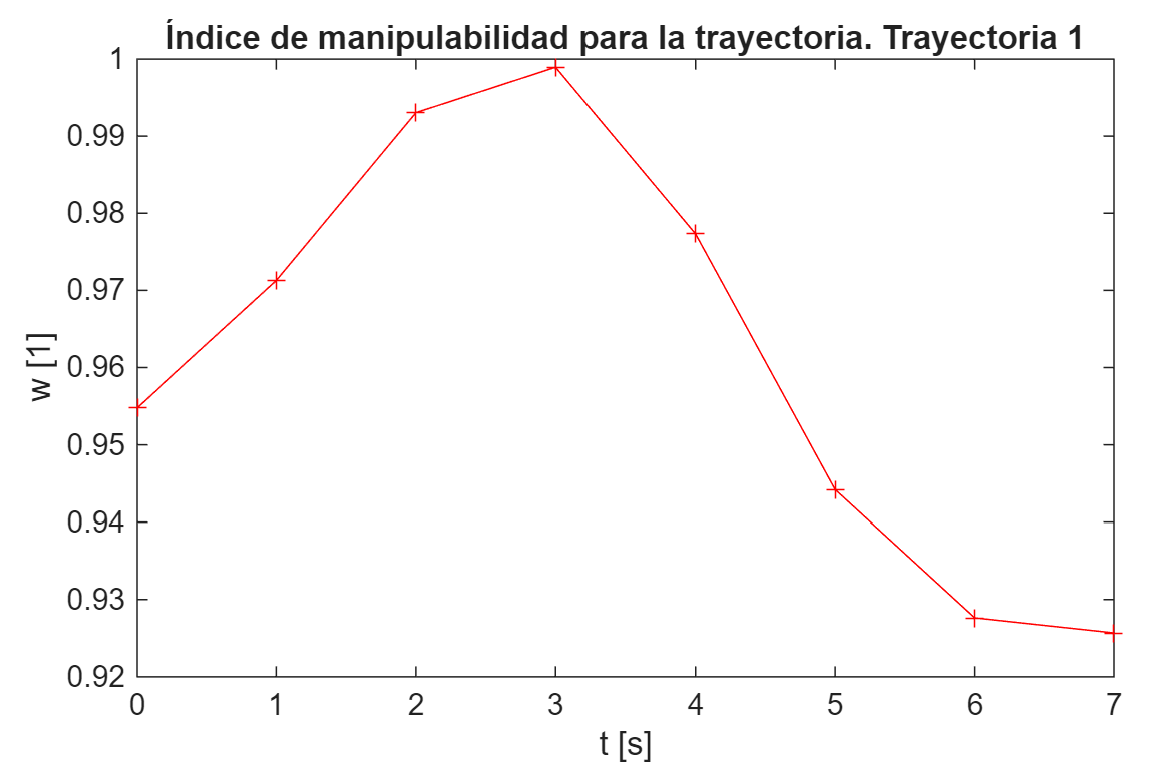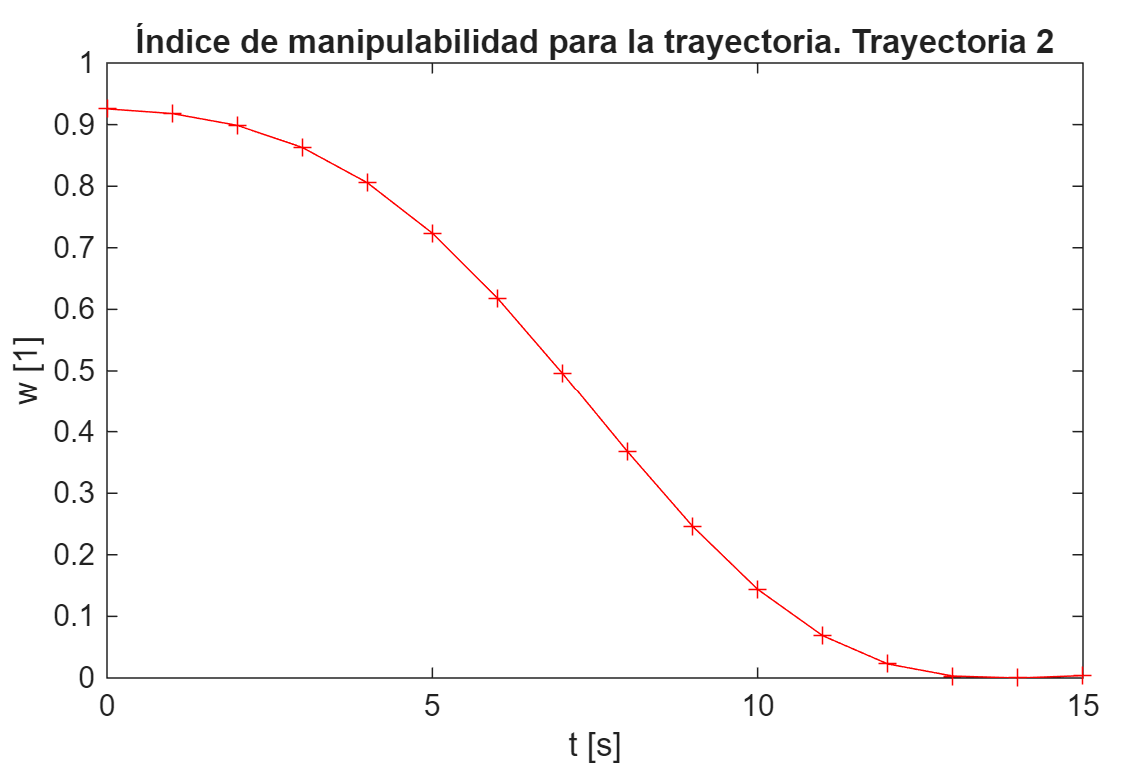
</p>


<p style="text-align:left">
   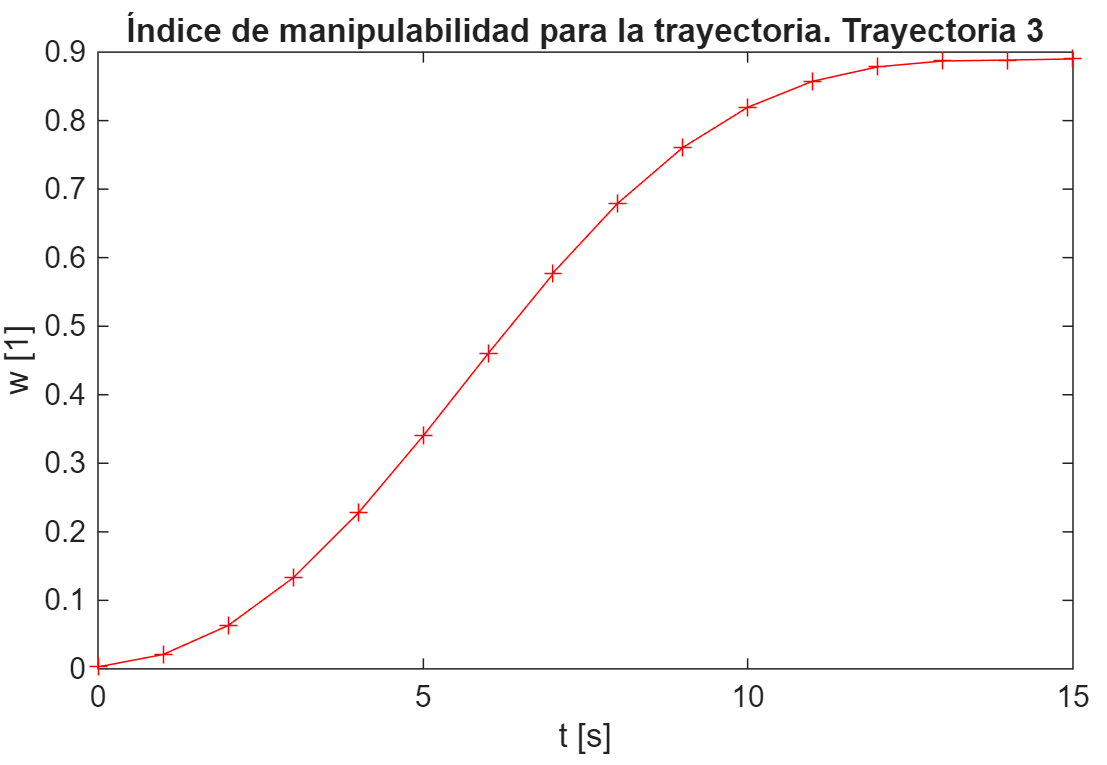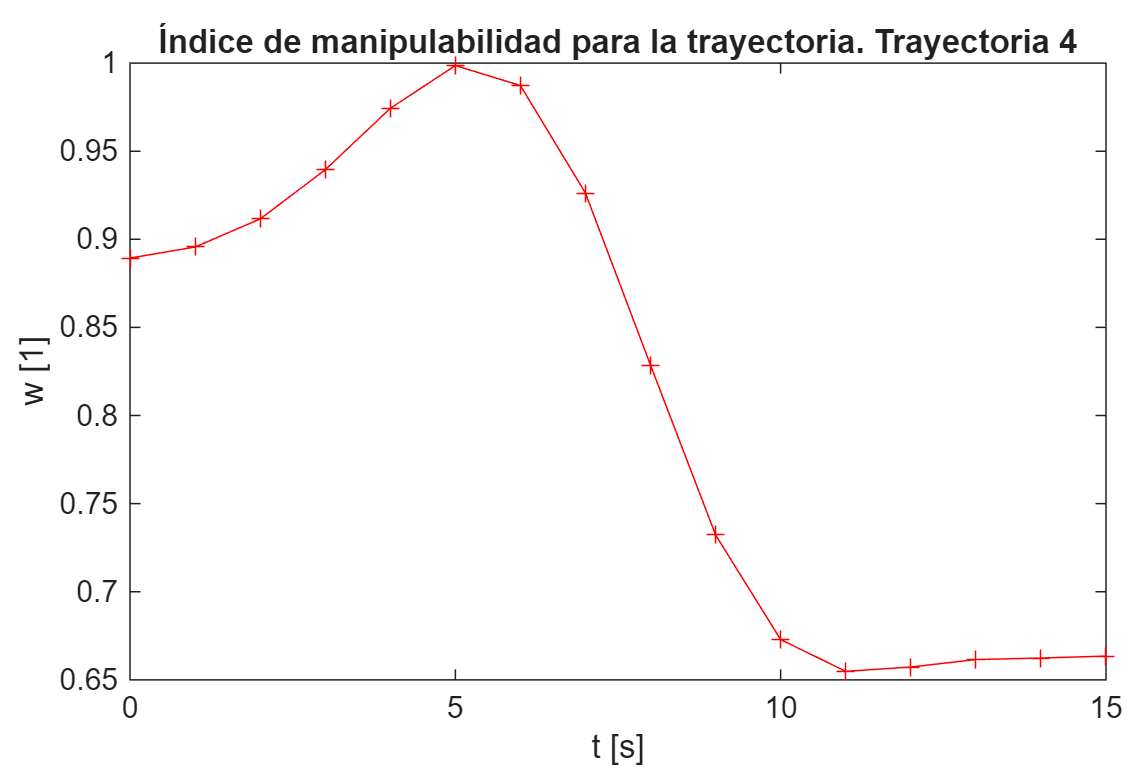
</p>


<p style="text-align:left">
   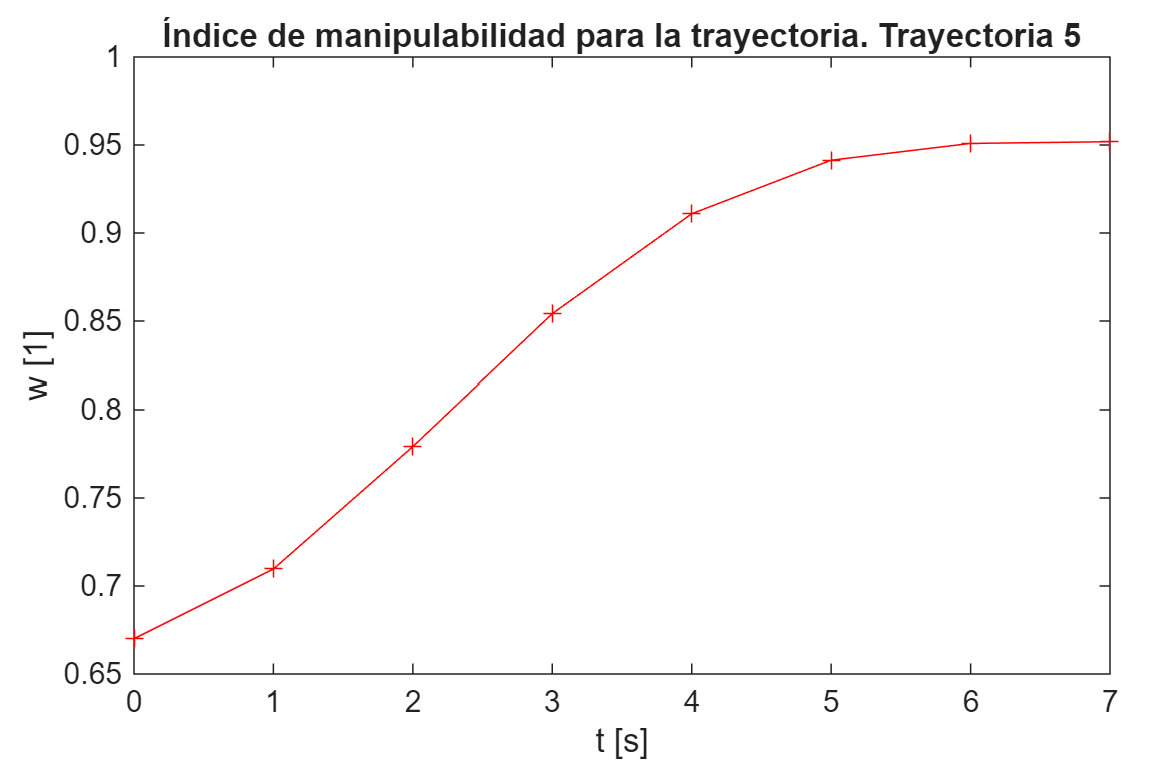
</p>

### Par de las articulaciones
<p style="text-align:left">
   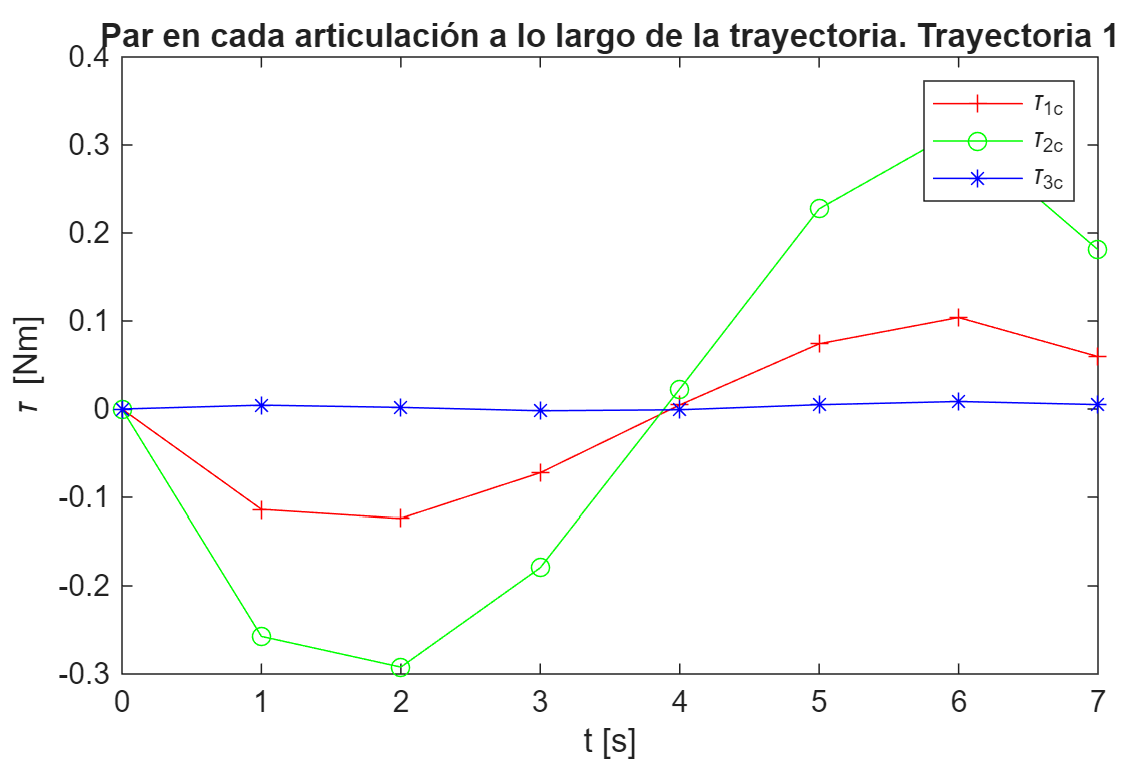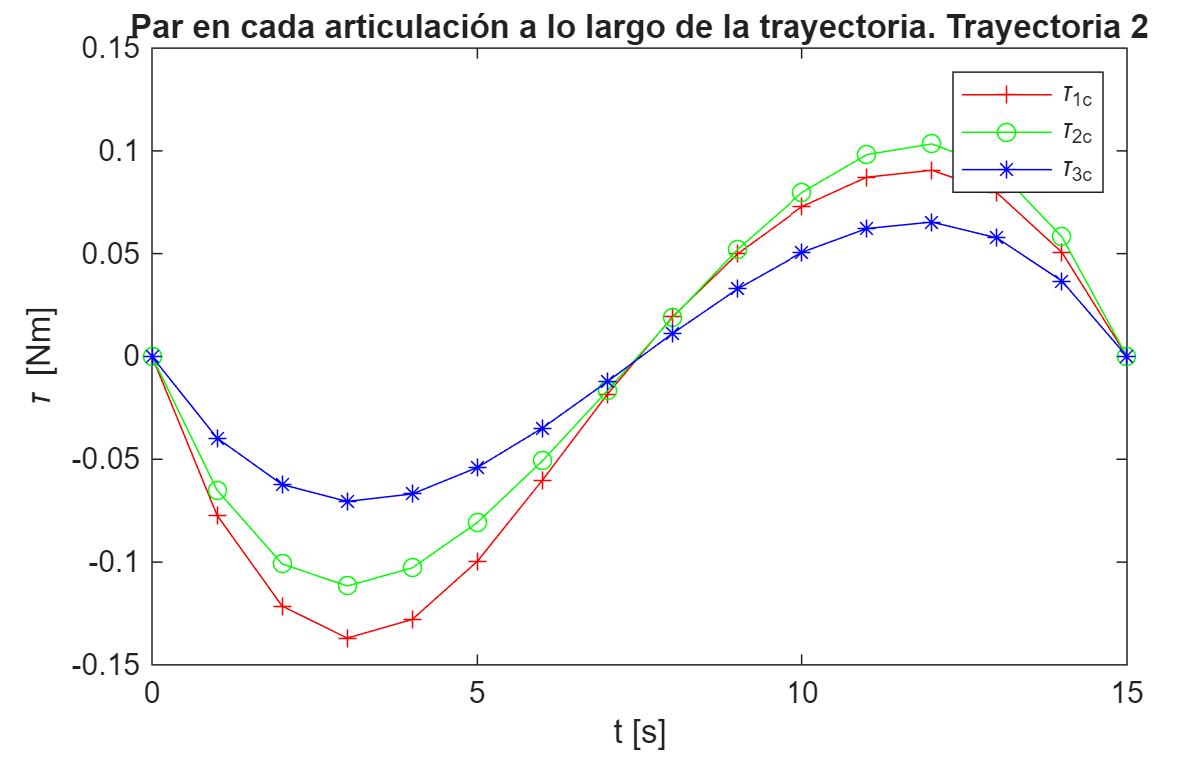
</p>


<p style="text-align:left">
   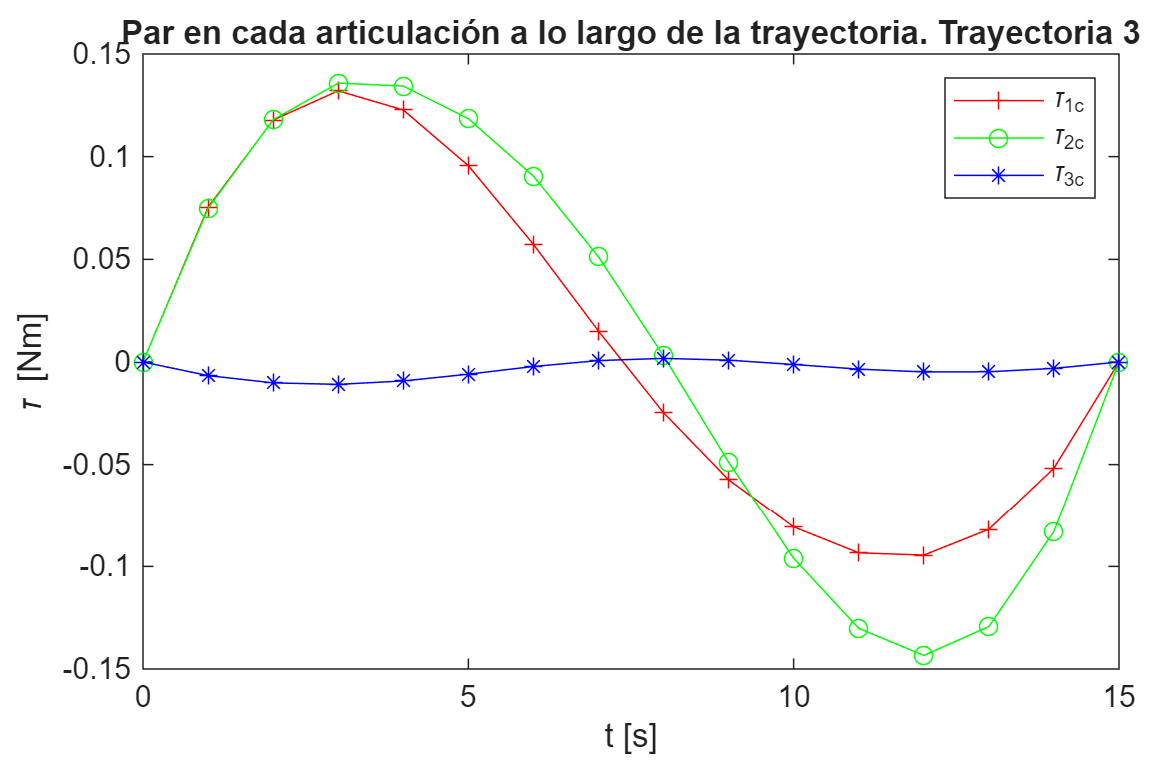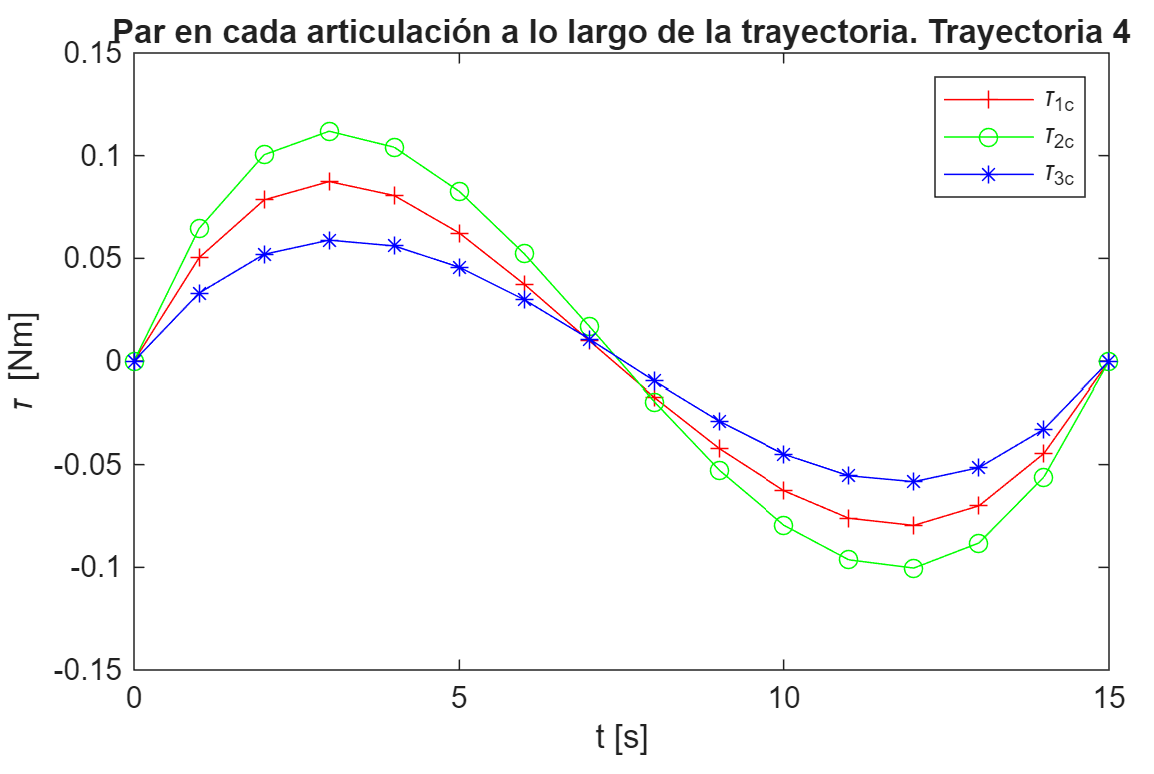
</p>


<p style="text-align:left">
   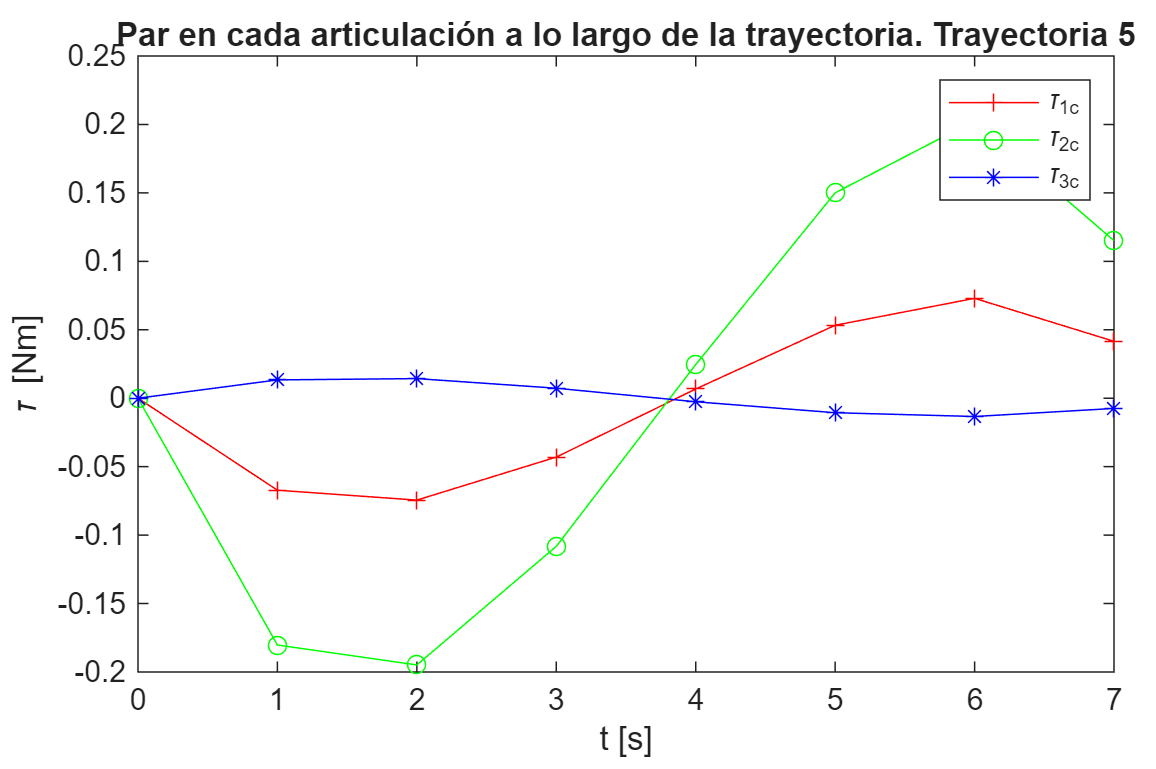
</p>

### Potencia en las articulaciones y potencia total
<p style="text-align:left">
   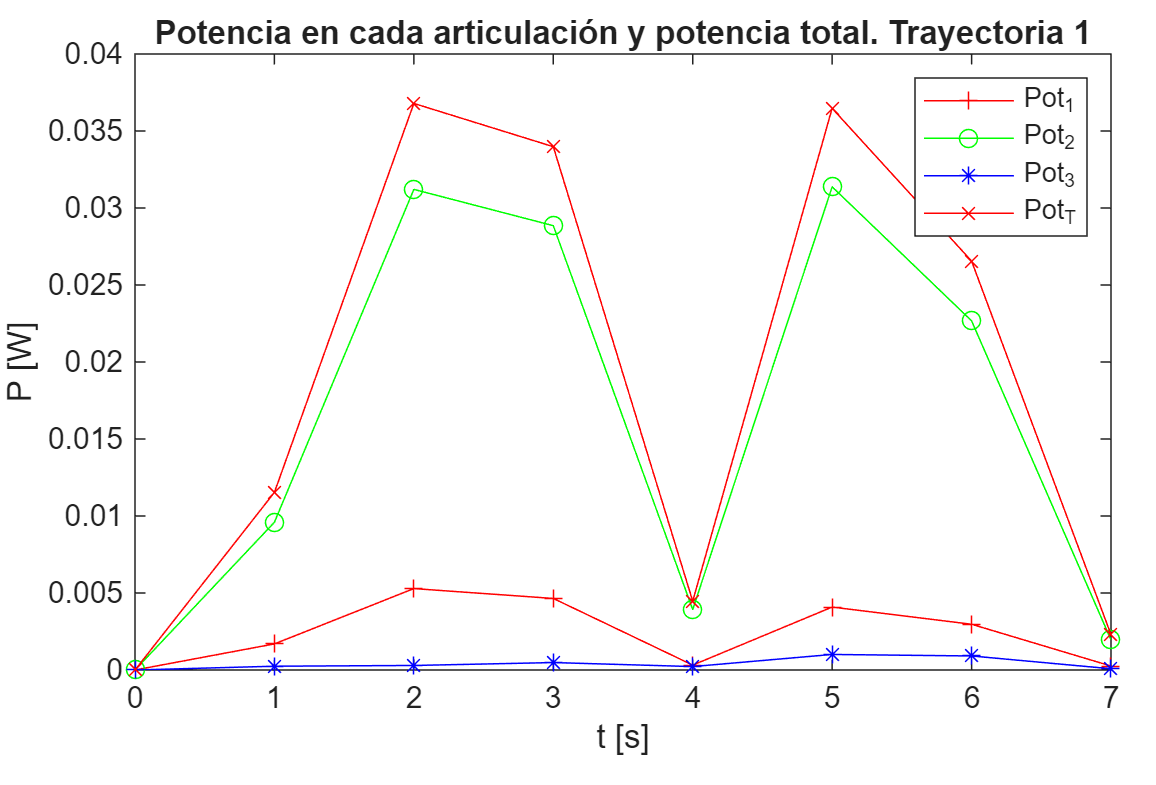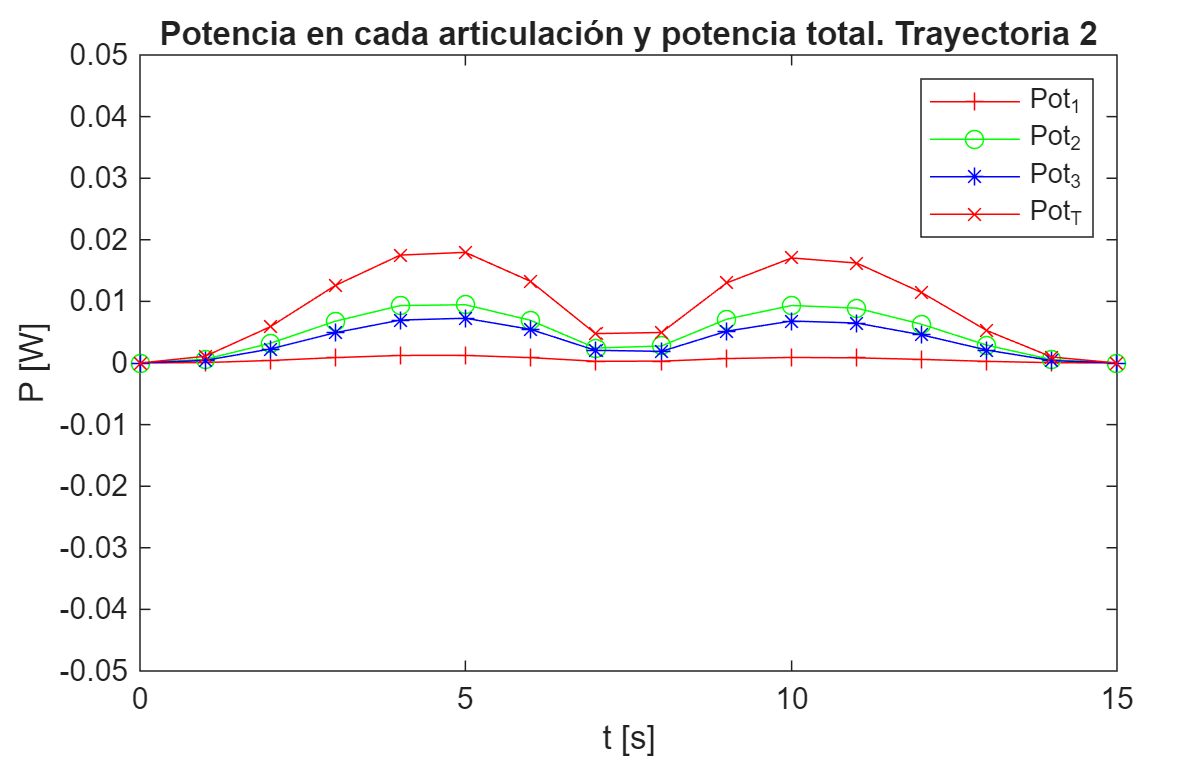
</p>


<p style="text-align:left">
   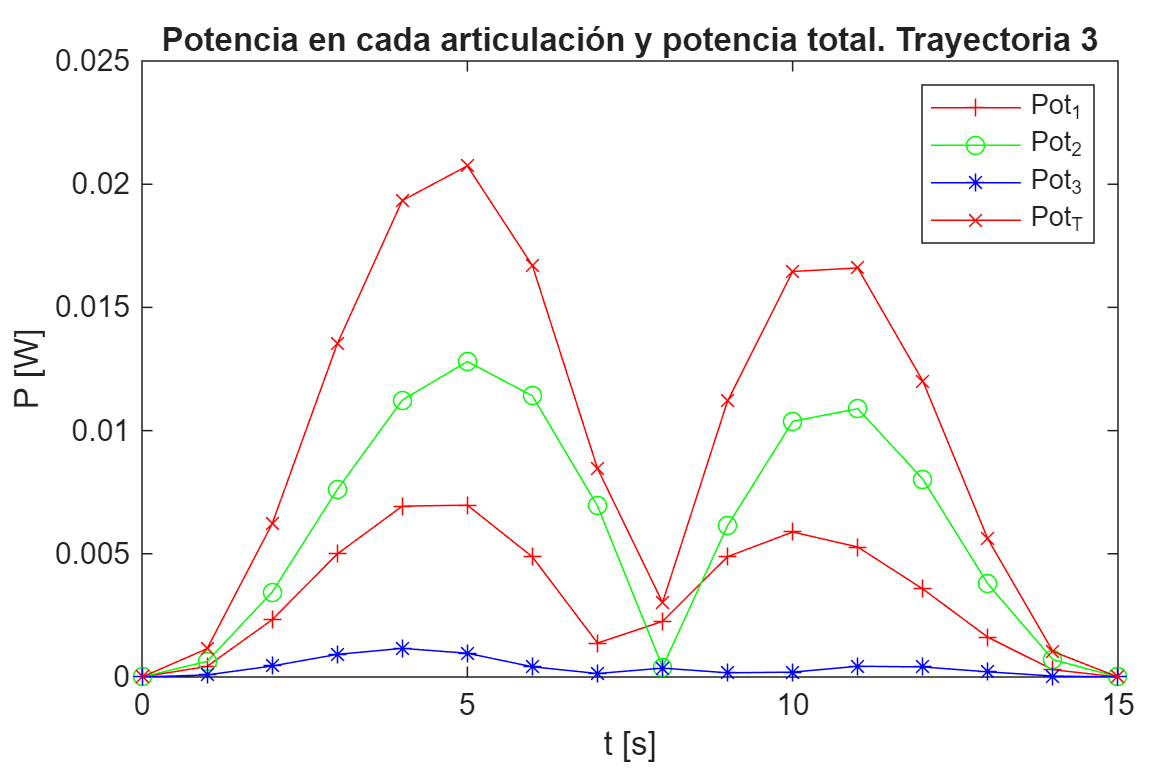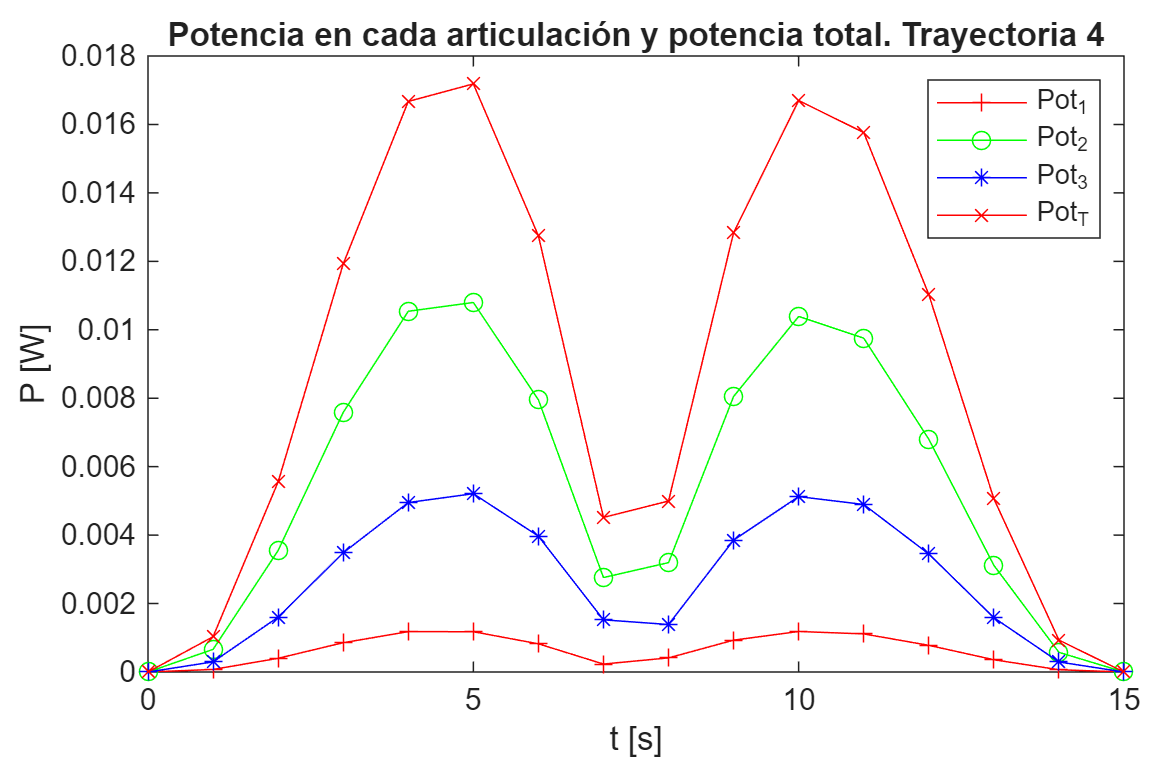
</p>


<p style="text-align:left">
   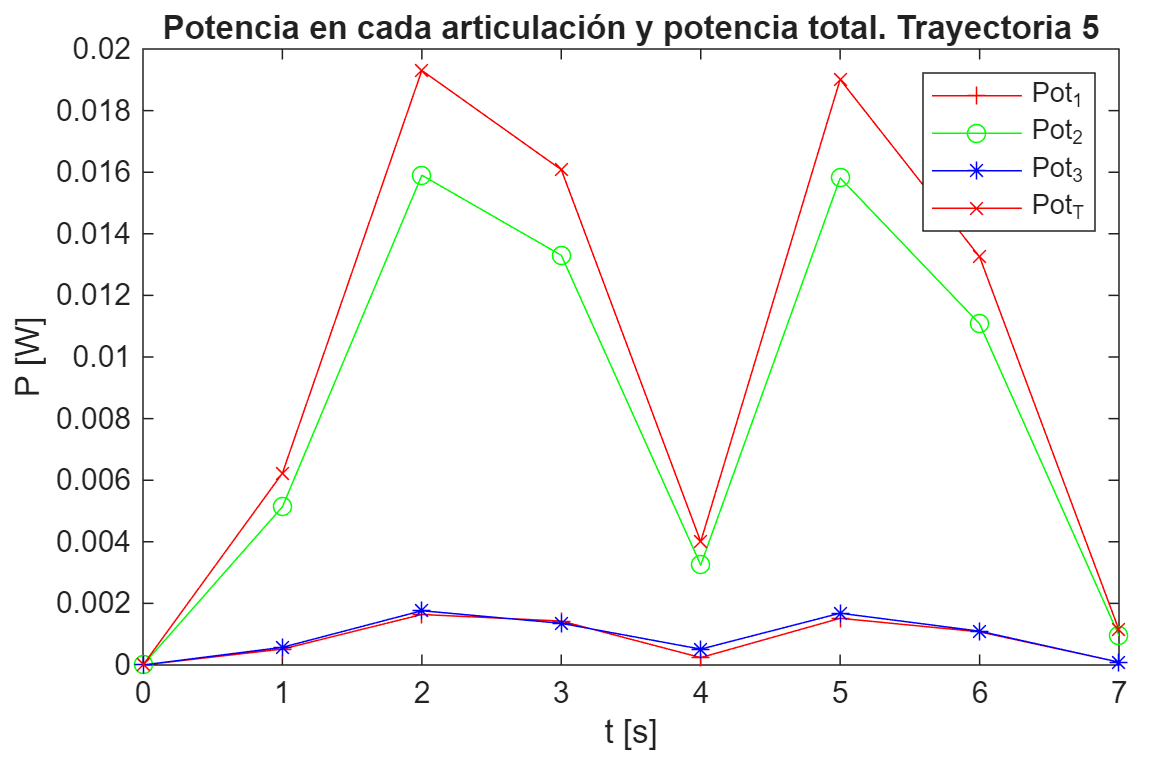
</p>


## Conclusiones
-  De manera general, si se observan las gráficas se puede ver que en la mayoría exceptuando las gráficas de velocidades en el espacio de trabajo, hay continuidad en los trazos entre una gráfica y otra, inclusive el índice de manipulabilidad tiene continuidad entre gráficas. Esto puede indicar que sí hay relación entre cada una de las trayectorias propuestas para recorrer todo el cuadrado.
-  Existe una mejor manipulabilidad en las trayectorias 1, 3 y 5 que son los lados del cuadrado paralelos al eje y\_0 según la imagen 1. Esto porque el robot tiene una mejor movilidad en estas zonas y su eslabón 2 (antebrazo) no tiene que estirarse demasiado o girar completamente contrario al eslabón 1 (hombro), lo que sí sucede para las trayectorias 2 y 4 que son la más alejada y la más cercana al robot.
-  Si se observan las gráficas de posición y velocidad para el eslabón 2 se puede ver cómo su movimiento prácticamente termina entre los 7 y 8 segundos mientras el eslabón 3 continúa su movimiento posicionandose en otra parte, esto en la manipulabilidad tiene un impacto porque en la gráfica para la trayectoria 2 se ve que a partir de ese momento va en picada disminuyendo hasta cero. Esto tiene sentido porque el eslabón ya no se mueve a partir de ahí, únicamente se mueve el eslabón 3. Y en la simulación ...
-  Otras observaciones sobre la manipulabilidad son que mejora cuando los trayectos son cortos y con tiempos más largos siempre y cuando el robot tenga las características para alcanzar las posiciones designadas.
-  La potencia máxima requerida por el robot en esta tarea es de 0.035 \[W\] por lo que se recomienda un motor con una potencia ligeramente mayor a esta. Además el motor que requiere más potencia durante esta tarea es el de la junta 2 (del antebrazo) que aplica el mayor par siempre.

## Código \- Programa en Python

## Trayectoria 1


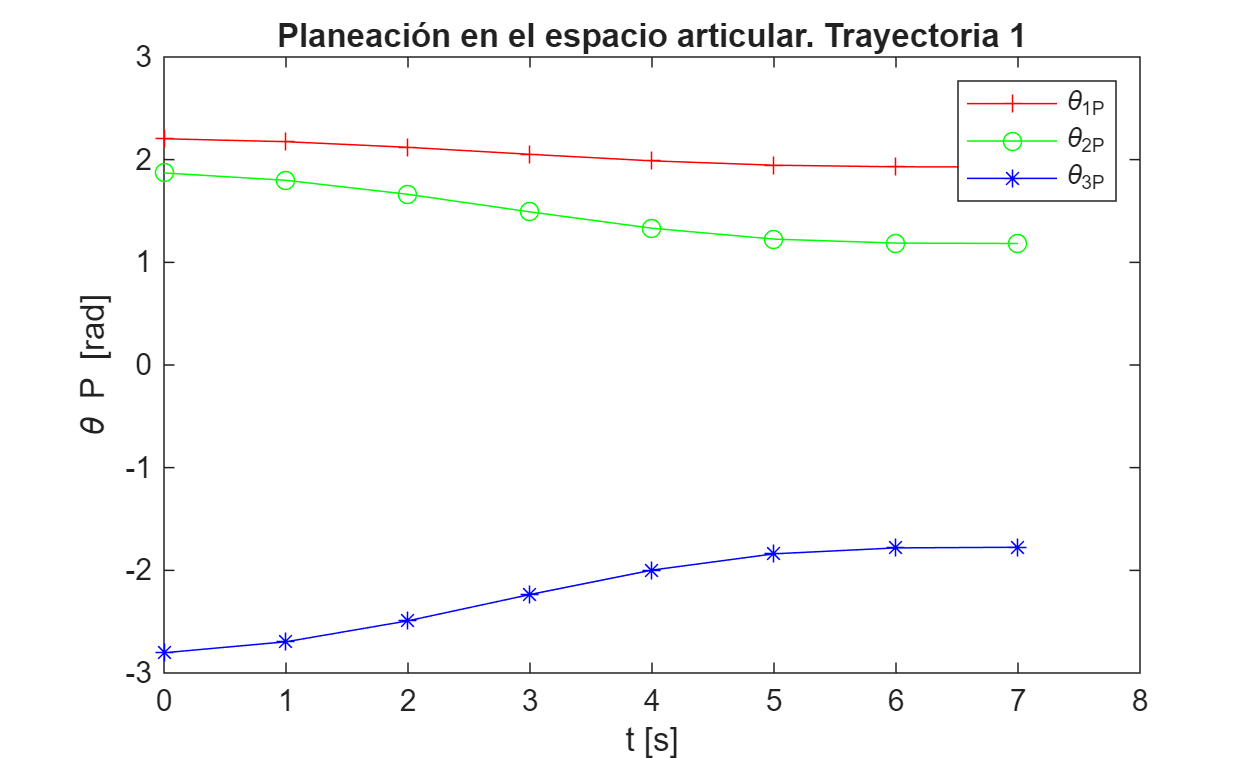

In [1]:
clear
clc

% 1) Definición de la postura inicial y final de la trayectoria

% Pose inicial
x_in = 0.25;
y_in = 0.8;
theta_in = 1.27; % 72.6°
% Pose final
x_fin = 0.25;
y_fin = 1.05;
theta_fin = 1.337; %76.60°

% 2) Posición de la primer postura

% Definición de los parámetros del robot
L1 = 0.5; % Longitud del primer eslabón
L2 = 0.5; % Longitud del segundo eslabón
L3 = 0.25; % Longitud del tercer eslabón

% POSTURA DEL ROBOT PARA EL PUNTO INICIAL

x_3 = x_in - L3*cos(theta_in);
y_3 = y_in - L3*sin(theta_in);

% Solucion por el método geométrico

arg01 = (x_3^2+y_3^2-L1^2-L2^2)/(2*L1*L2);
arg01 = max(min(arg01,1),-1);
theta_2_in = acos(arg01);

beta = atan2(y_3,x_3);

arg02 = (x_3^2+y_3^2+L1^2-L2^2)/(2*L1*sqrt(x_3^2+y_3^2));
arg02 = max(min(arg02,1),-1);
psi = acos(arg02);

theta_1_in = beta + psi;

theta_3_in = theta_in -theta_1_in - theta_2_in;

% POSTURA DEL ROBOT PARA EL PUNTO FINAL

x_3 = x_fin - L3*cos(theta_fin);
y_3 = y_fin - L3*sin(theta_fin);

% Solucion por el método geométrico

arg01 = (x_3^2+y_3^2-L1^2-L2^2)/(2*L1*L2);
arg01 = max(min(arg01,1),-1);
theta_2_fin = acos(arg01);

beta = atan2(y_3,x_3);

arg02 = (x_3^2+y_3^2+L1^2-L2^2)/(2*L1*sqrt(x_3^2+y_3^2));
arg02 = max(min(arg02,1),-1);
psi = acos(arg02);

theta_1_fin = beta + psi;

theta_3_fin = theta_fin - theta_1_fin - theta_2_fin;

% 3) Trayectoria en el espacio de las juntas

tf = 7.5; % Se define un tiempo para que el robot haga su movimiento [s]

for i=1:tf+1
    t = i; % Incremento de tiempo para la siguiente iteración
    theta_1_P(i) = theta_1_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_1_fin-theta_1_in);
    theta_2_P(i) = theta_2_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_2_fin-theta_2_in);
    theta_3_P(i) = theta_3_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_3_fin-theta_3_in);

end

% 4) Trayectoria en el espacio de trabajo

for i=1:tf+1
    t = i;
    x_P(i) = x_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(x_fin-x_in);
    y_P(i) = y_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(y_fin-y_in);
    theta_P(i) = theta_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_fin-theta_in);

    x_3_a(i) = x_P(i) - L3*cos(theta_P(i));
    y_3_a(i) = y_P(i) - L3*sin(theta_P(i));

    % Solucion por el método geométrico

    arg1 = ((x_3_a(i)^2+y_3_a(i)^2-L1^2-L2^2)/(2*L1*L2));
    arg1 = max(min(arg1,1),-1);  % limitar entre [-1,1]

    theta_2_tray(i) = acos(arg1);

    beta = atan2(y_3_a(i),x_3_a(i));

    arg2 = ((x_3_a(i)^2+y_3_a(i)^2+L1^2-L2^2)/(2*L1*sqrt(x_3_a(i)^2+y_3_a(i)^2)));
    arg2 = max(min(arg2,1),-1);  % limitar entre [-1,1]
    psi = acos(arg2);

    theta_1_tray(i) = beta + psi;

    theta_3_tray(i) = theta_P(i) - theta_1_tray(i) - theta_2_tray(i);

end

% 5) Velocidades y aceleraciones en el espacio de las juntas

for i=1:tf+1
    t = i-1;
    theta_1_P_v(i) =  ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_1_fin-theta_1_in);
    theta_2_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_2_fin-theta_2_in);
    theta_3_P_v(i) =  ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_3_fin-theta_3_in);

end

for i=1:tf+1
    t = i-1;
    theta_1_P_a(i) =  ((60/tf^3)*t - (180/tf^4)*t^2 + (120/tf^5)*t^3)*(theta_1_fin-theta_1_in);
    theta_2_P_a(i) = ((60/tf^3)*t - (180/tf^4)*t^2 + (120/tf^5)*t^3)*(theta_2_fin-theta_2_in);
    theta_3_P_a(i) =  ((60/tf^3)*t - (180/tf^4)*t^2 + (120/tf^5)*t^3)*(theta_3_fin-theta_3_in);

end

% 6) Velocidades en el espacio de trabajo

for i=1:tf+1
    t = i;
    x_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(x_fin-x_in);
    y_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(y_fin-y_in);
    theta_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_fin-theta_in);

    x_dot = x_P_v(i);
    y_dot = y_P_v(i);
    theta_dot_P = theta_P_v(i);

    theta_O_1 = theta_1_tray(i);
    theta_1_2 = theta_2_tray(i);
    theta_2_3 = theta_3_tray(i);

    theta_1_v(i) = (x_dot*cos(theta_1_2 + theta_O_1))/(L1*sin(theta_1_2)) + (y_dot*sin(theta_1_2 + theta_O_1))/(L1*sin(theta_1_2)) + (L3*theta_dot_P*sin(theta_2_3))/(L1*sin(theta_1_2));
    theta_2_v(i) = - (x_dot*(L2*cos(theta_1_2 + theta_O_1) + L1*cos(theta_O_1)))/(L1*L2*sin(theta_1_2)) - (y_dot*(L2*sin(theta_1_2 + theta_O_1) + L1*sin(theta_O_1)))/(L1*L2*sin(theta_1_2)) - (L3*theta_dot_P*(L1*sin(theta_1_2 + theta_2_3) + L2*sin(theta_2_3)))/(L1*L2*sin(theta_1_2));
    theta_3_v(i) = (theta_dot_P*(L3*sin(theta_1_2 + theta_2_3) + L2*sin(theta_1_2)))/(L2*sin(theta_1_2)) + (x_dot*cos(theta_O_1))/(L2*sin(theta_1_2)) + (y_dot*sin(theta_O_1))/(L2*sin(theta_1_2));


end

% 7) Índice de manipulabilidad

for i=1:tf+1

    w(i) = abs(sin(theta_2_tray(i)));

end

% 8) Cálculo de los pares en cada junta

for i=1:tf+1

    theta_1 = theta_1_P(i);
    theta_2 = theta_2_P(i);
    theta_3 = theta_3_P(i);

    theta_1_vc = theta_1_P_v(i);
    theta_2_vc = theta_2_P_v(i);
    theta_3_vc = theta_3_P_v(i);

    theta_1_a = theta_1_P_a(i);
    theta_2_a = theta_2_P_a(i);
    theta_3_a = theta_3_P_a(i);

    sigma_19 = sin(theta_2+theta_1)/2;
    sigma_18 = sin(theta_1+theta_2+theta_3);
    sigma_17 = cos(theta_2+theta_1)/2;
    sigma_16 = cos(theta_1+theta_2+theta_3);

    sigma_15 = theta_2_vc*(sigma_18/8 + sigma_19);
    sigma_14 = sigma_18/8 + sigma_19 + sin(theta_1)/2;
    sigma_13 = theta_2_vc *(sigma_16/8 +sigma_17);
    sigma_12 = sigma_16/8 +sigma_17 +cos(theta_1)/2;
    sigma_11 = theta_3_vc*sigma_18/8 + theta_1_vc*sigma_14 +sigma_15;
    sigma_10 = sigma_13 + theta_3_vc*sigma_16/8 +theta_1_vc*sigma_12;
    sigma_9 = ((sigma_16/8 + sigma_17)*sigma_11)/2;
    sigma_8 = ((sigma_18/8 + sigma_19)*sigma_10)/2;
    sigma_7 = (sigma_16*(sigma_16/8 + sigma_17))/16 + (sigma_18*(sigma_18/8 + sigma_19))/16 + 1;
    sigma_6 = sigma_16*sigma_12/16 + sigma_18*sigma_14 + 1;
    sigma_5 = theta_2_vc*sigma_16/8 + theta_3_vc*sigma_16/8 + theta_1_vc*sigma_16/8;
    sigma_4 = theta_2_vc*sigma_18/8 + theta_3_vc*sigma_18/8 + theta_1_vc*sigma_18/8;
    sigma_3 = cos(theta_2)/8 + ((sigma_16/8 + sigma_17)*sigma_12)/2 + ((sigma_18/8 + sigma_19)*sigma_14)/2 + 33/16;
    sigma_2 = sigma_13 +theta_1_vc*(sigma_16/8 + sigma_17) + theta_3_vc*sigma_16/8;
    sigma_1 = theta_3_vc*sigma_18/8 + sigma_15 +theta_1_vc*(sigma_18/8 + sigma_19);

    tao_1_c(i) = theta_1_a*(cos(theta_2)/4 + sigma_12^2/2 + sigma_14^2/2 + 27/8) - theta_3_vc* (sigma_18*sigma_10/16 - sigma_16*sigma_11/16 + sigma_12*sigma_4/2 - sigma_5*sigma_14/2) + theta_2_a*sigma_3 + theta_3_a*sigma_6 - theta_2_vc*(sigma_8 - sigma_14*sigma_2/2 + sigma_1*sigma_12/2 - sigma_9 + theta_2_vc*sin(theta_2)/8 + theta_1_vc*sin(theta_2)/4);
    tao_2_c(i) = theta_1_vc^2*sin(theta_2)/8 - theta_3_vc*(sigma_18*sigma_10 - ((sigma_18/8 + sigma_19)*sigma_5)/2 + ((sigma_16/8 + sigma_17)*sigma_4)/2 - sigma_16*sigma_11/16) + theta_2_a*sigma_7 + sigma_10*sigma_1/2 + theta_1_a*sigma_3 - sigma_11*sigma_2/2 + theta_2_a*(((sigma_16 + sigma_17)^2)/2 + ((sigma_18 + sigma_19)^2)/2 + 33/16) - theta_2_vc*((sigma_16/8 + sigma_17)*sigma_1/2 + (sigma_18/8 + sigma_19)*sigma_2/2 + sigma_8 - sigma_9 + theta_1_vc*sin(theta_2)/8) + theta_2_vc*theta_1_vc*sin(theta_2)/8;
    tao_3_c(i) = theta_3_a*(sigma_16^2/128 + sigma_18^2/128 + 1 ) - sigma_5*sigma_11/2 + theta_2_a*sigma_7 - theta_3_vc*(sigma_18*sigma_10/16 - sigma_18*sigma_5/16 - sigma_16*sigma_11/16 + sigma_16*sigma_4/16) + theta_2_vc*(sigma_18*sigma_2/16 - sigma_18*sigma_10/16 - sigma_16*sigma_1/16 + sigma_16*sigma_11/16) + theta_1_a*sigma_6 + sigma_10*sigma_4/2;

end

% 9) Cálculo de la potencia por junta y total

for i=1:tf+1
    theta_1_vc = theta_1_P_v(i);
    theta_2_vc = theta_2_P_v(i);
    theta_3_vc = theta_3_P_v(i);

    pot_1(i) = abs(tao_1_c(i)*theta_1_vc);
    pot_2(i) = abs(tao_2_c(i)*theta_2_vc);
    pot_3(i) = abs(tao_3_c(i)*theta_3_vc);
    pot_total(i) = pot_1(i) + pot_2(i) + pot_3(i);
end

% 10) Gráficas

tsim = 0:1:tf; % tiempo de simulación para las gráficas

% Gráfica de la trayectoria en el espacio de las juntas

figure;

plot(tsim, theta_1_P, 'r-+');
hold on;
plot(tsim, theta_2_P, 'g-o');
plot(tsim, theta_3_P, 'b-*');

hold off;

xlim([0.00 8.00])
ylim auto
legend('\theta_1_P','\theta_2_P','\theta_3_P')
title("Planeación en el espacio articular. Trayectoria 1")
xlabel("t [s]")
ylabel("\theta P [rad]")


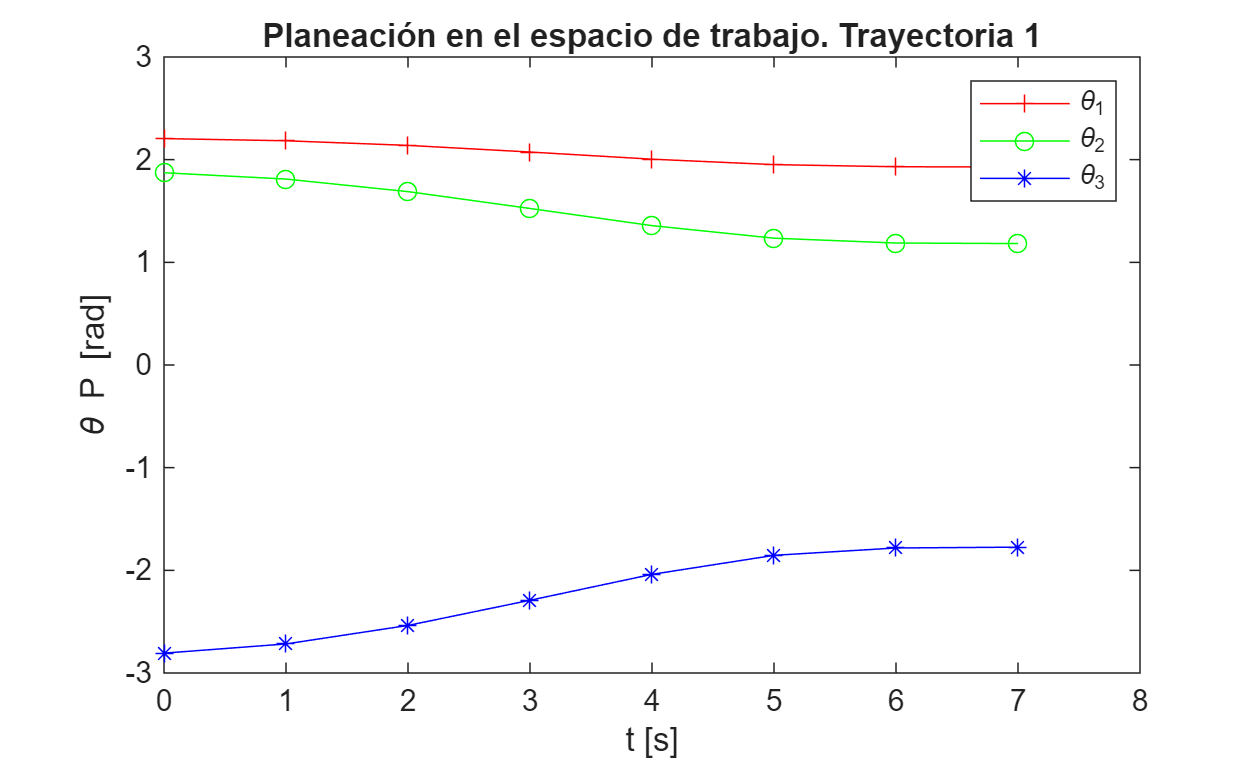

In [2]:

% Gráfica de la trayectoria en el espacio de trabajo

figure;

plot(tsim, theta_1_tray, 'r-+');
hold on;
plot(tsim, theta_2_tray, 'g-o');
plot(tsim, theta_3_tray, 'b-*');

hold off;

xlim([0.00 8.00])
ylim auto
legend('\theta_1','\theta_2','\theta_3')
title("Planeación en el espacio de trabajo. Trayectoria 1")
xlabel("t [s]")
ylabel("\theta P [rad]")


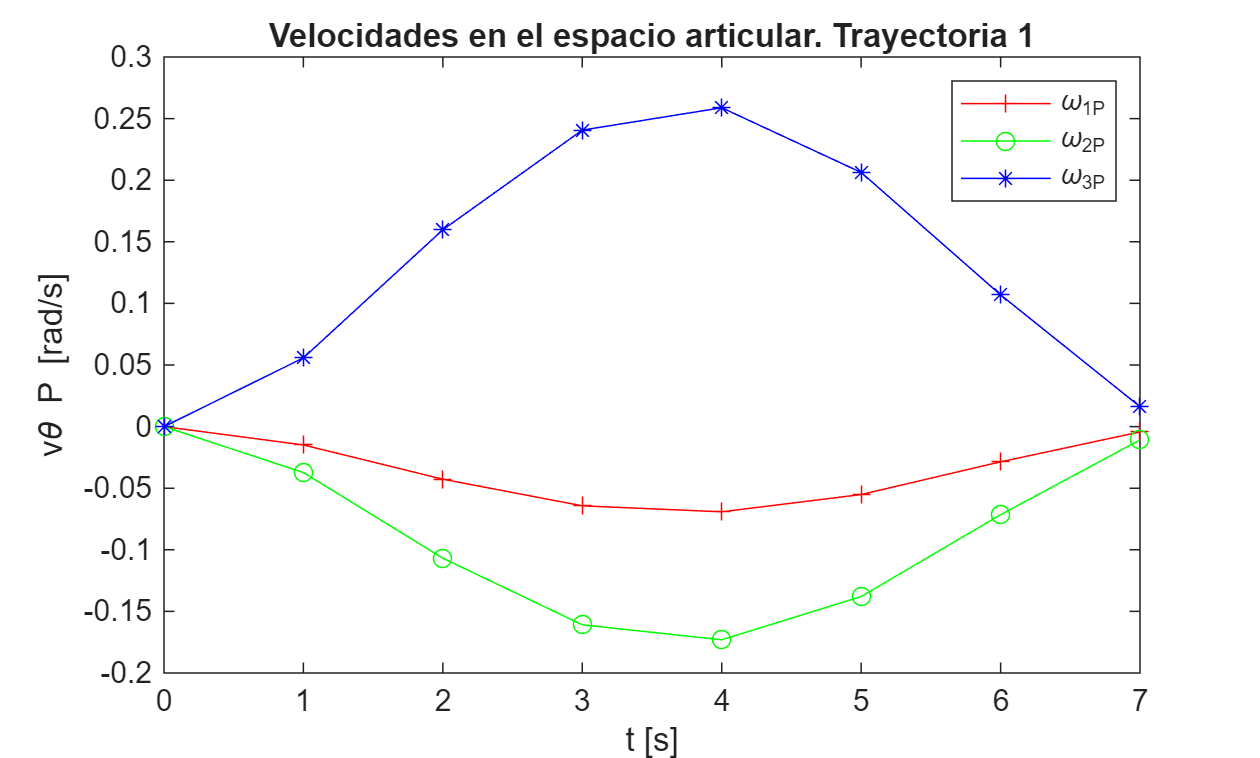

In [3]:

% Gráfica de las velocidades en el espacio articular

figure;

plot(tsim, theta_1_P_v, 'r-+');
hold on;
plot(tsim, theta_2_P_v, 'g-o');
plot(tsim, theta_3_P_v, 'b-*');

hold off;

legend('\omega_1_P','\omega_2_P','\omega_3_P')
title("Velocidades en el espacio articular. Trayectoria 1")
xlabel("t [s]")
ylabel("v\theta P [rad/s]")


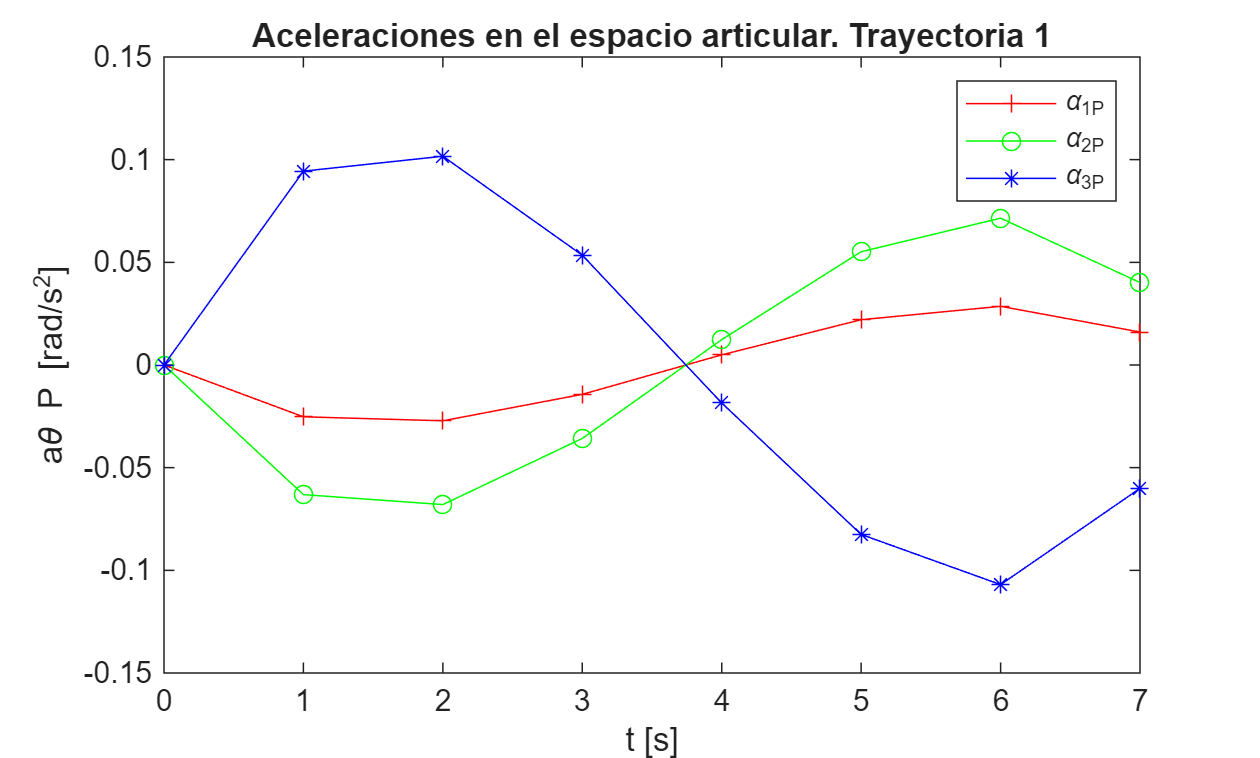

In [4]:

% Gráfica de las aceleraciones en el espacio articular

figure;

plot(tsim, theta_1_P_a, 'r-+');
hold on;
plot(tsim, theta_2_P_a, 'g-o');
plot(tsim, theta_3_P_a, 'b-*');

hold off;

legend('\alpha_1_P','\alpha_2_P','\alpha_3_P')
title("Aceleraciones en el espacio articular. Trayectoria 1")
xlabel("t [s]")
ylabel("a\theta P [rad/s^2]")


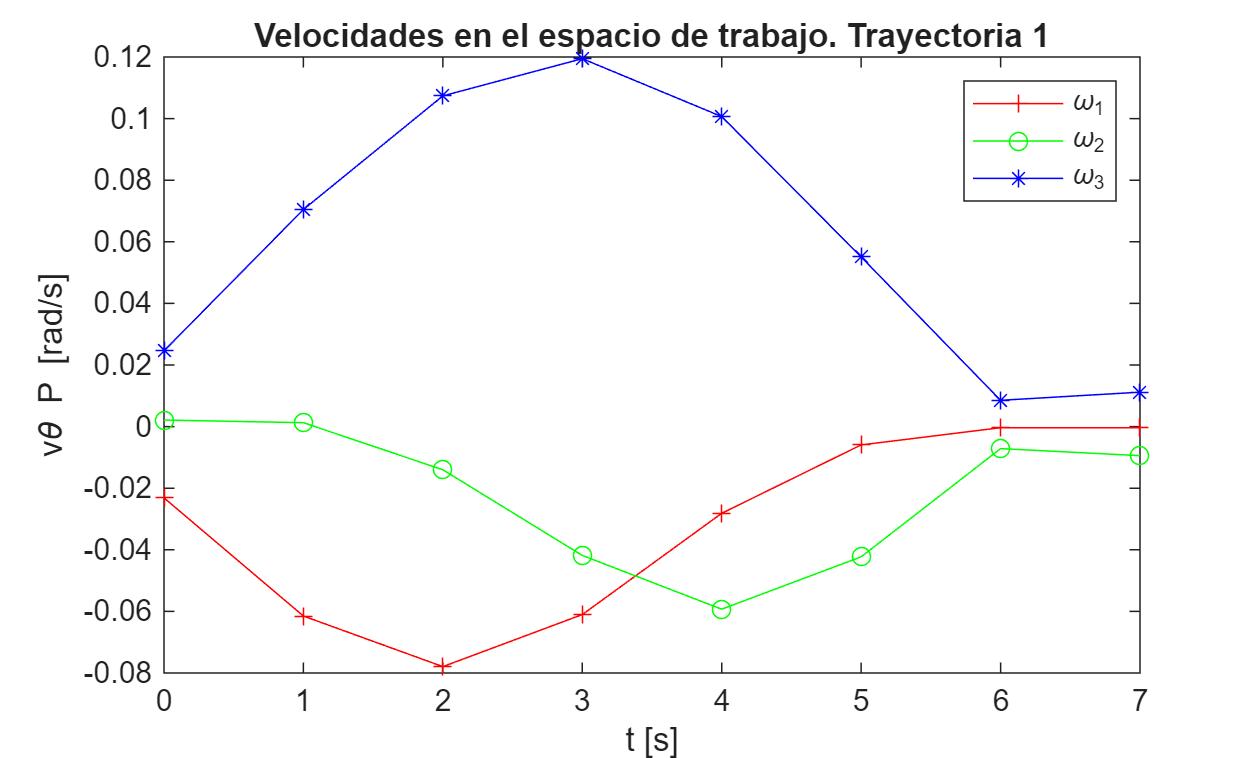

In [5]:

% Gráfica de las velocidades en el espacio de trabajo

figure;

plot(tsim, theta_1_v, 'r-+');
hold on;
plot(tsim, theta_2_v, 'g-o');
plot(tsim, theta_3_v, 'b-*');

hold off;

legend('\omega_1','\omega_2','\omega_3')
title("Velocidades en el espacio de trabajo. Trayectoria 1")
xlabel("t [s]")
ylabel("v\theta P [rad/s]")


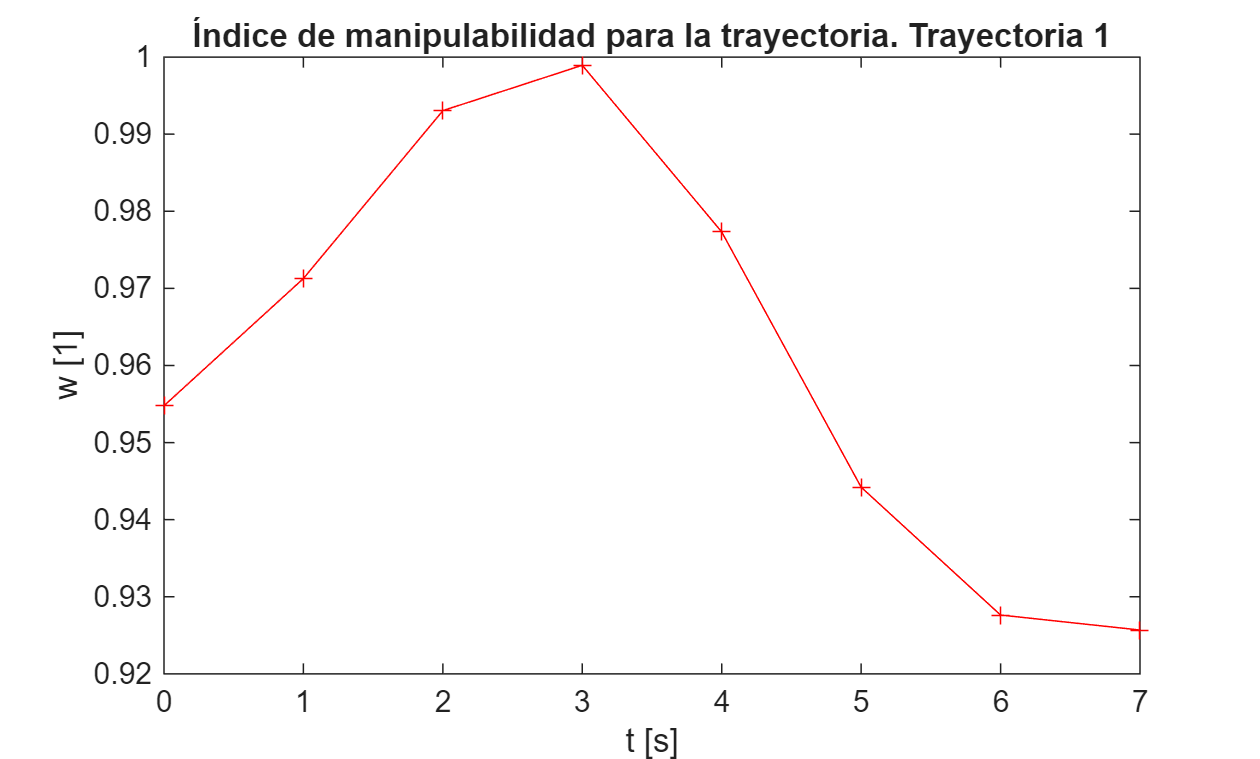

In [6]:

% Gráfica del índice de manipulabilidad

figure;

plot(tsim, w, 'r-+');

title("Índice de manipulabilidad para la trayectoria. Trayectoria 1")
xlabel("t [s]")
ylabel("w [1]")


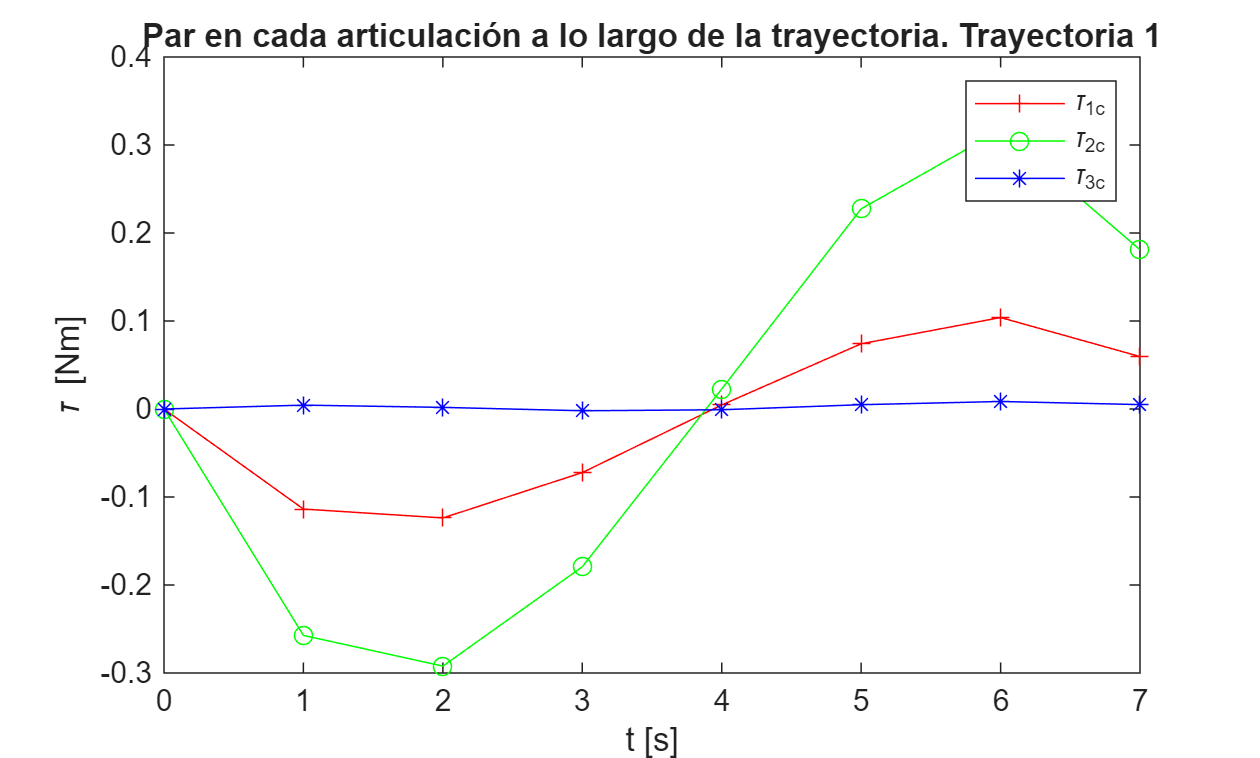

In [7]:

% Gráfica de los pares en las articulaciones

figure;

plot(tsim, tao_1_c, 'r-+');
hold on;
plot(tsim, tao_2_c, 'g-o');
plot(tsim, tao_3_c, 'b-*');

hold off;

legend('\tau_1_c','\tau_2_c','\tau_3_c')
title("Par en cada articulación a lo largo de la trayectoria. Trayectoria 1")
xlabel("t [s]")
ylabel("\tau [Nm]")


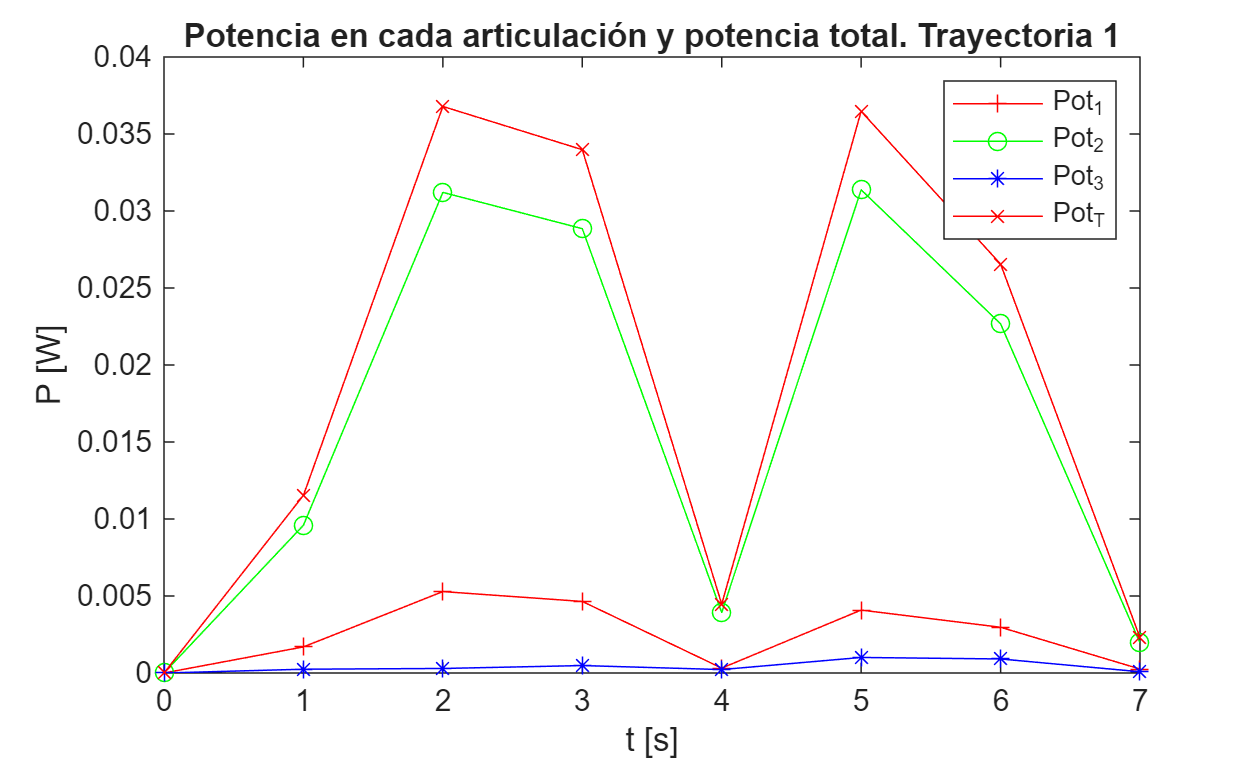

In [8]:

% Gráfica de la potencia en las articulaciones

figure;

plot(tsim, pot_1, 'r-+');
hold on;
plot(tsim, pot_2, 'g-o');
plot(tsim, pot_3, 'b-*');
plot(tsim, pot_total, 'r-x');

hold off;

legend('Pot_1','Pot_2','Pot_3','Pot_T')
title("Potencia en cada articulación y potencia total. Trayectoria 1")
xlabel("t [s]")
ylabel("P [W]")

## Trayectoria 2


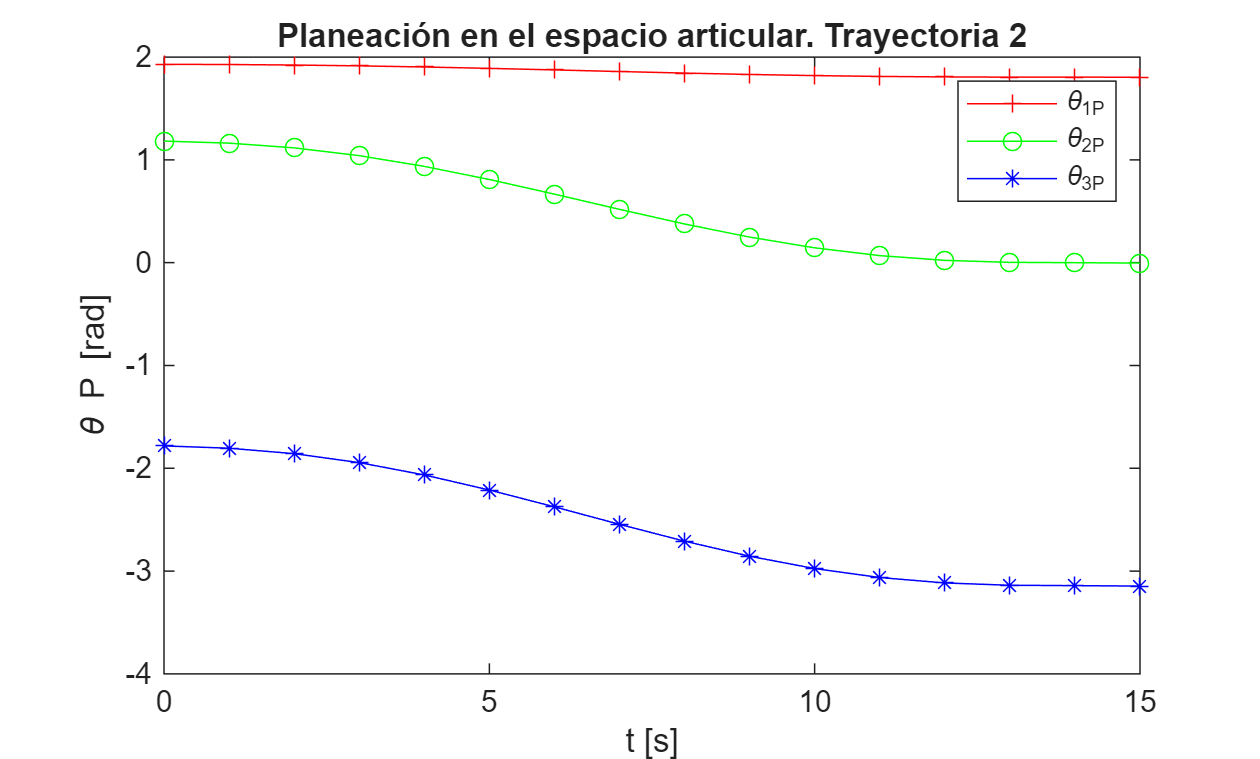

In [9]:
clear
clc

% 1) Definición de la postura inicial y final de la trayectoria

% Pose inicial
x_in = 0.25;
y_in = 1.05;
theta_in = 1.337; % 76.60°
% Pose final
x_fin = -0.25;
y_fin = 1.05;
theta_fin = -1.337; % -76.60°

% 2) Posición de la primer postura

% Definición de los parámetros del robot
L1 = 0.5; % Longitud del primer eslabón
L2 = 0.5; % Longitud del segundo eslabón
L3 = 0.25; % Longitud del tercer eslabón

% POSTURA DEL ROBOT PARA EL PUNTO INICIAL

x_3 = x_in - L3*cos(theta_in);
y_3 = y_in - L3*sin(theta_in);

% Solucion por el método geométrico

arg01 = (x_3^2+y_3^2-L1^2-L2^2)/(2*L1*L2);
arg01 = max(min(arg01,1),-1);
theta_2_in = acos(arg01);

beta = atan2(y_3,x_3);

arg02 = (x_3^2+y_3^2+L1^2-L2^2)/(2*L1*sqrt(x_3^2+y_3^2));
arg02 = max(min(arg02,1),-1);
psi = acos(arg02);

theta_1_in = beta + psi;

theta_3_in = theta_in -theta_1_in - theta_2_in;

% POSTURA DEL ROBOT PARA EL PUNTO FINAL

x_3 = x_fin - L3*cos(theta_fin);
y_3 = y_fin - L3*sin(theta_fin);

% Solucion por el método geométrico

arg01 = (x_3^2+y_3^2-L1^2-L2^2)/(2*L1*L2);
arg01 = max(min(arg01,1),-1);
theta_2_fin = acos(arg01);

beta = atan2(y_3,x_3);

arg02 = (x_3^2+y_3^2+L1^2-L2^2)/(2*L1*sqrt(x_3^2+y_3^2));
arg02 = max(min(arg02,1),-1);
psi = acos(arg02);

theta_1_fin = beta + psi;

theta_3_fin = theta_fin - theta_1_fin - theta_2_fin;

% 3) Trayectoria en el espacio de las juntas

tf = 15; % Se define un tiempo para que el robot haga su movimiento [s]

for i=1:tf+1
    t = i; % Incremento de tiempo para la siguiente iteración
    theta_1_P(i) = theta_1_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_1_fin-theta_1_in);
    theta_2_P(i) = theta_2_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_2_fin-theta_2_in);
    theta_3_P(i) = theta_3_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_3_fin-theta_3_in);

end

% 4) Trayectoria en el espacio de trabajo

for i=1:tf+1
    t = i;
    x_P(i) = x_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(x_fin-x_in);
    y_P(i) = y_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(y_fin-y_in);
    theta_P(i) = theta_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_fin-theta_in);

    x_3_a(i) = x_P(i) - L3*cos(theta_P(i));
    y_3_a(i) = y_P(i) - L3*sin(theta_P(i));

    % Solucion por el método geométrico

    arg1 = ((x_3_a(i)^2+y_3_a(i)^2-L1^2-L2^2)/(2*L1*L2));
    arg1 = max(min(arg1,1),-1);  % limitar entre [-1,1]

    theta_2_tray(i) = acos(arg1);

    beta = atan2(y_3_a(i),x_3_a(i));

    arg2 = ((x_3_a(i)^2+y_3_a(i)^2+L1^2-L2^2)/(2*L1*sqrt(x_3_a(i)^2+y_3_a(i)^2)));
    arg2 = max(min(arg2,1),-1);  % limitar entre [-1,1]
    psi = acos(arg2);

    theta_1_tray(i) = beta + psi;

    theta_3_tray(i) = theta_P(i) - theta_1_tray(i) - theta_2_tray(i);

end

% 5) Velocidades y aceleraciones en el espacio de las juntas

for i=1:tf+1
    t = i-1;
    theta_1_P_v(i) =  ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_1_fin-theta_1_in);
    theta_2_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_2_fin-theta_2_in);
    theta_3_P_v(i) =  ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_3_fin-theta_3_in);

end

for i=1:tf+1
    t = i-1;
    theta_1_P_a(i) =  ((60/tf^3)*t - (180/tf^4)*t^2 + (120/tf^5)*t^3)*(theta_1_fin-theta_1_in);
    theta_2_P_a(i) = ((60/tf^3)*t - (180/tf^4)*t^2 + (120/tf^5)*t^3)*(theta_2_fin-theta_2_in);
    theta_3_P_a(i) =  ((60/tf^3)*t - (180/tf^4)*t^2 + (120/tf^5)*t^3)*(theta_3_fin-theta_3_in);

end

% 6) Velocidades en el espacio de trabajo

for i=1:tf+1
    t = i;
    x_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(x_fin-x_in);
    y_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(y_fin-y_in);
    theta_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_fin-theta_in);

    x_dot = x_P_v(i);
    y_dot = y_P_v(i);
    theta_dot_P = theta_P_v(i);

    theta_O_1 = theta_1_tray(i);
    theta_1_2 = theta_2_tray(i);
    theta_2_3 = theta_3_tray(i);

    theta_1_v(i) = (x_dot*cos(theta_1_2 + theta_O_1))/(L1*sin(theta_1_2)) + (y_dot*sin(theta_1_2 + theta_O_1))/(L1*sin(theta_1_2)) + (L3*theta_dot_P*sin(theta_2_3))/(L1*sin(theta_1_2));
    theta_2_v(i) = - (x_dot*(L2*cos(theta_1_2 + theta_O_1) + L1*cos(theta_O_1)))/(L1*L2*sin(theta_1_2)) - (y_dot*(L2*sin(theta_1_2 + theta_O_1) + L1*sin(theta_O_1)))/(L1*L2*sin(theta_1_2)) - (L3*theta_dot_P*(L1*sin(theta_1_2 + theta_2_3) + L2*sin(theta_2_3)))/(L1*L2*sin(theta_1_2));
    theta_3_v(i) = (theta_dot_P*(L3*sin(theta_1_2 + theta_2_3) + L2*sin(theta_1_2)))/(L2*sin(theta_1_2)) + (x_dot*cos(theta_O_1))/(L2*sin(theta_1_2)) + (y_dot*sin(theta_O_1))/(L2*sin(theta_1_2));


end

% 7) Índice de manipulabilidad

for i=1:tf+1

    w(i) = abs(sin(theta_2_P(i)));

end

% 8) Cálculo de los pares en cada junta

for i=1:tf+1

    theta_1 = theta_1_P(i);
    theta_2 = theta_2_P(i);
    theta_3 = theta_3_P(i);

    theta_1_vc = theta_1_P_v(i);
    theta_2_vc = theta_2_P_v(i);
    theta_3_vc = theta_3_P_v(i);

    theta_1_a = theta_1_P_a(i);
    theta_2_a = theta_2_P_a(i);
    theta_3_a = theta_3_P_a(i);

    sigma_19 = sin(theta_2+theta_1)/2;
    sigma_18 = sin(theta_1+theta_2+theta_3);
    sigma_17 = cos(theta_2+theta_1)/2;
    sigma_16 = cos(theta_1+theta_2+theta_3);

    sigma_15 = theta_2_vc*(sigma_18/8 + sigma_19);
    sigma_14 = sigma_18/8 + sigma_19 + sin(theta_1)/2;
    sigma_13 = theta_2_vc *(sigma_16/8 +sigma_17);
    sigma_12 = sigma_16/8 +sigma_17 +cos(theta_1)/2;
    sigma_11 = theta_3_vc*sigma_18/8 + theta_1_vc*sigma_14 +sigma_15;
    sigma_10 = sigma_13 + theta_3_vc*sigma_16/8 +theta_1_vc*sigma_12;
    sigma_9 = ((sigma_16/8 + sigma_17)*sigma_11)/2;
    sigma_8 = ((sigma_18/8 + sigma_19)*sigma_10)/2;
    sigma_7 = (sigma_16*(sigma_16/8 + sigma_17))/16 + (sigma_18*(sigma_18/8 + sigma_19))/16 + 1;
    sigma_6 = sigma_16*sigma_12/16 + sigma_18*sigma_14 + 1;
    sigma_5 = theta_2_vc*sigma_16/8 + theta_3_vc*sigma_16/8 + theta_1_vc*sigma_16/8;
    sigma_4 = theta_2_vc*sigma_18/8 + theta_3_vc*sigma_18/8 + theta_1_vc*sigma_18/8;
    sigma_3 = cos(theta_2)/8 + ((sigma_16/8 + sigma_17)*sigma_12)/2 + ((sigma_18/8 + sigma_19)*sigma_14)/2 + 33/16;
    sigma_2 = sigma_13 +theta_1_vc*(sigma_16/8 + sigma_17) + theta_3_vc*sigma_16/8;
    sigma_1 = theta_3_vc*sigma_18/8 + sigma_15 +theta_1_vc*(sigma_18/8 + sigma_19);

    tao_1_c(i) = theta_1_a*(cos(theta_2)/4 + sigma_12^2/2 + sigma_14^2/2 + 27/8) - theta_3_vc* (sigma_18*sigma_10/16 - sigma_16*sigma_11/16 + sigma_12*sigma_4/2 - sigma_5*sigma_14/2) + theta_2_a*sigma_3 + theta_3_a*sigma_6 - theta_2_vc*(sigma_8 - sigma_14*sigma_2/2 + sigma_1*sigma_12/2 - sigma_9 + theta_2_vc*sin(theta_2)/8 + theta_1_vc*sin(theta_2)/4);
    tao_2_c(i) = theta_1_vc^2*sin(theta_2)/8 - theta_3_vc*(sigma_18*sigma_10 - ((sigma_18/8 + sigma_19)*sigma_5)/2 + ((sigma_16/8 + sigma_17)*sigma_4)/2 - sigma_16*sigma_11/16) + theta_2_a*sigma_7 + sigma_10*sigma_1/2 + theta_1_a*sigma_3 - sigma_11*sigma_2/2 + theta_2_a*(((sigma_16 + sigma_17)^2)/2 + ((sigma_18 + sigma_19)^2)/2 + 33/16) - theta_2_vc*((sigma_16/8 + sigma_17)*sigma_1/2 + (sigma_18/8 + sigma_19)*sigma_2/2 + sigma_8 - sigma_9 + theta_1_vc*sin(theta_2)/8) + theta_2_vc*theta_1_vc*sin(theta_2)/8;
    tao_3_c(i) = theta_3_a*(sigma_16^2/128 + sigma_18^2/128 + 1 ) - sigma_5*sigma_11/2 + theta_2_a*sigma_7 - theta_3_vc*(sigma_18*sigma_10/16 - sigma_18*sigma_5/16 - sigma_16*sigma_11/16 + sigma_16*sigma_4/16) + theta_2_vc*(sigma_18*sigma_2/16 - sigma_18*sigma_10/16 - sigma_16*sigma_1/16 + sigma_16*sigma_11/16) + theta_1_a*sigma_6 + sigma_10*sigma_4/2;

end

% 9) Cálculo de la potencia por junta y total

for i=1:tf+1
    theta_1_vc = theta_1_P_v(i);
    theta_2_vc = theta_2_P_v(i);
    theta_3_vc = theta_3_P_v(i);
    pot_1(i) = abs(tao_1_c(i)*theta_1_vc);
    pot_2(i) = abs(tao_2_c(i)*theta_2_vc);
    pot_3(i) = abs(tao_3_c(i)*theta_3_vc);
    pot_total(i) = pot_1(i) + pot_2(i) + pot_3(i);
end

% 10) Gráficas

tsim = 0:1:tf; % tiempo de simulación para las gráficas

% Gráfica de la trayectoria en el espacio de las juntas

figure;

plot(tsim, theta_1_P, 'r-+');
hold on;
plot(tsim, theta_2_P, 'g-o');
plot(tsim, theta_3_P, 'b-*');

hold off;

xlim auto
ylim auto
legend('\theta_1_P','\theta_2_P','\theta_3_P')
title("Planeación en el espacio articular. Trayectoria 2")
xlabel("t [s]")
ylabel("\theta P [rad]")


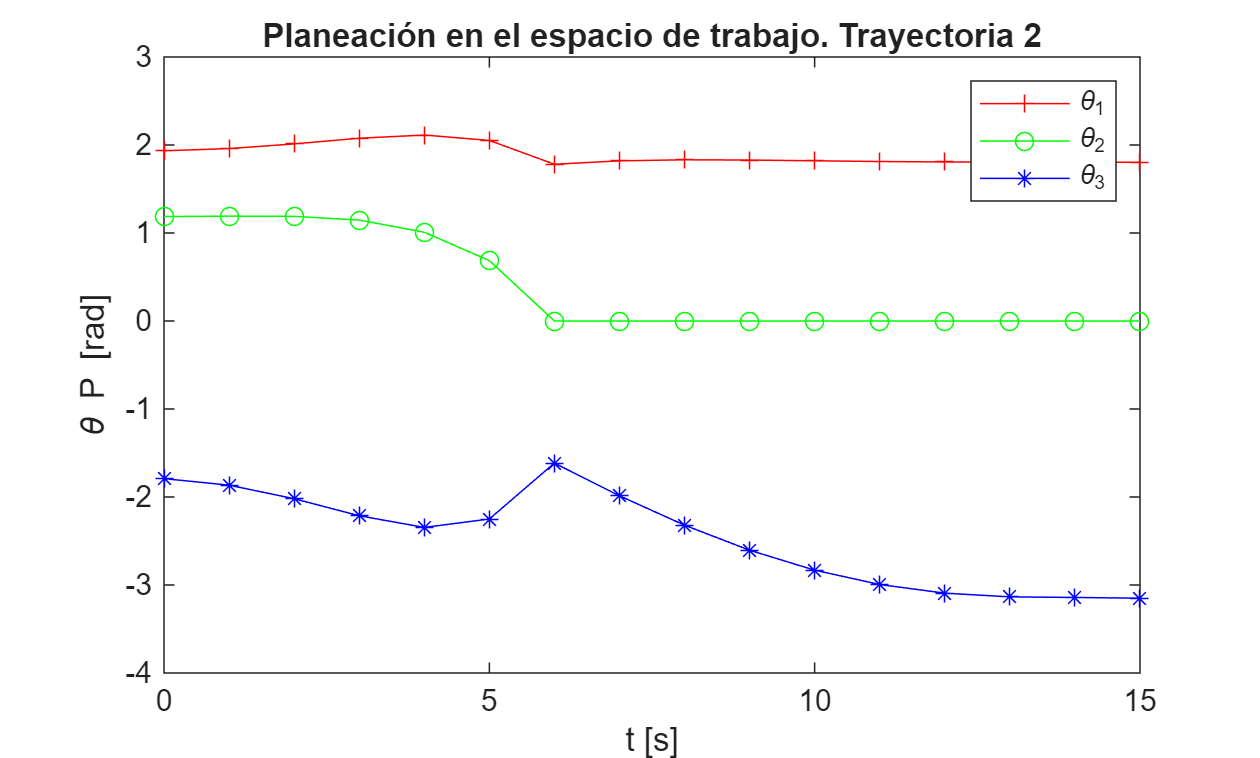

In [10]:

% Gráfica de la trayectoria en el espacio de trabajo

figure;

plot(tsim, theta_1_tray, 'r-+');
hold on;
plot(tsim, theta_2_tray, 'g-o');
plot(tsim, theta_3_tray, 'b-*');

hold off;

xlim auto
ylim auto
legend('\theta_1','\theta_2','\theta_3')
title("Planeación en el espacio de trabajo. Trayectoria 2")
xlabel("t [s]")
ylabel("\theta P [rad]")


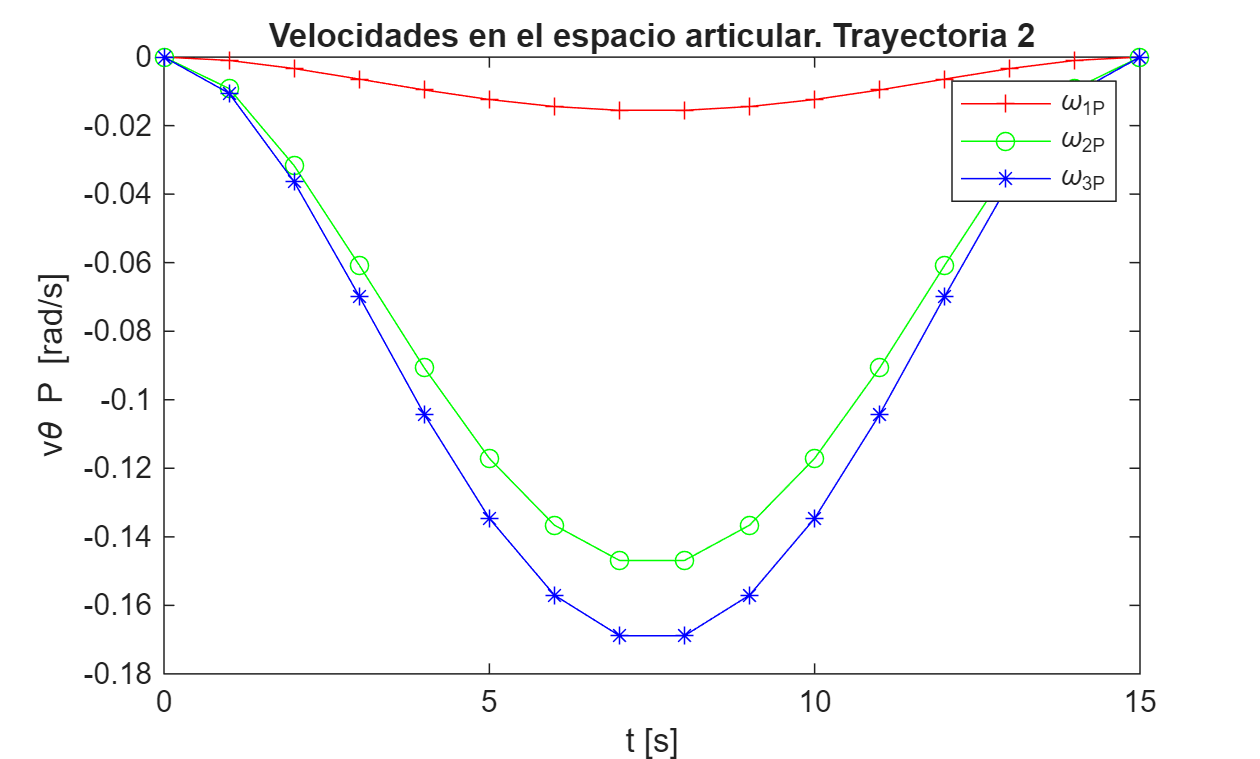

In [11]:

% Gráfica de las velocidades en el espacio articular

figure;

plot(tsim, theta_1_P_v, 'r-+');
hold on;
plot(tsim, theta_2_P_v, 'g-o');
plot(tsim, theta_3_P_v, 'b-*');

hold off;

legend('\omega_1_P','\omega_2_P','\omega_3_P')
title("Velocidades en el espacio articular. Trayectoria 2")
xlabel("t [s]")
ylabel("v\theta P [rad/s]")


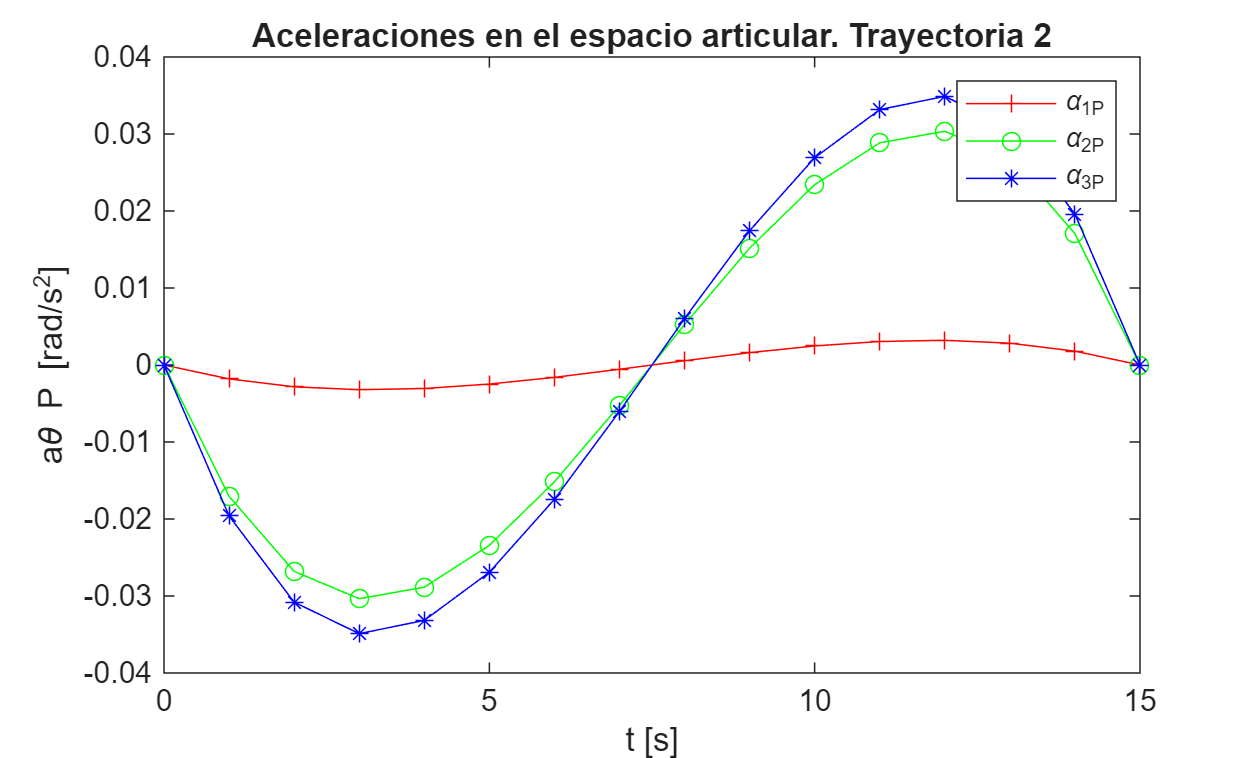

In [12]:

% Gráfica de las aceleraciones en el espacio articular

figure;

plot(tsim, theta_1_P_a, 'r-+');
hold on;
plot(tsim, theta_2_P_a, 'g-o');
plot(tsim, theta_3_P_a, 'b-*');

hold off;

legend('\alpha_1_P','\alpha_2_P','\alpha_3_P')
title("Aceleraciones en el espacio articular. Trayectoria 2")
xlabel("t [s]")
ylabel("a\theta P [rad/s^2]")


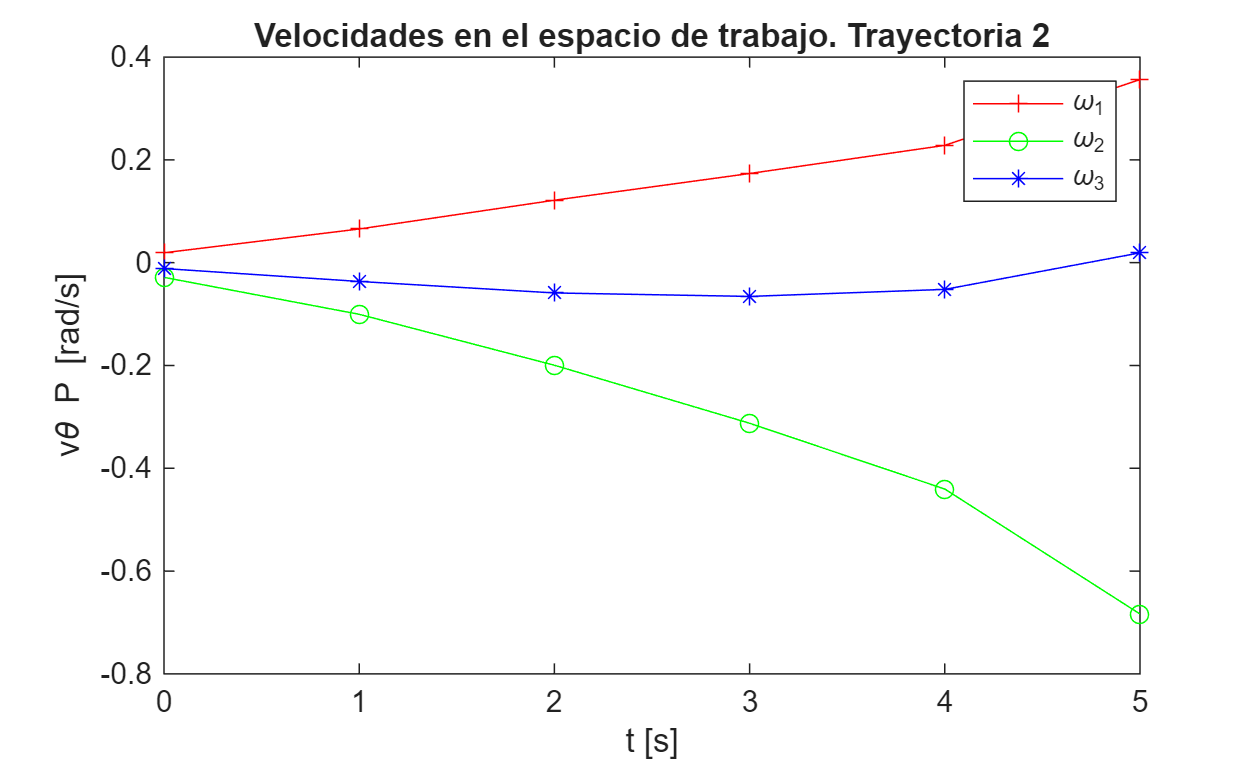

In [13]:

% Gráfica de las velocidades en el espacio de trabajo

figure;

plot(tsim, theta_1_v, 'r-+');
hold on;
plot(tsim, theta_2_v, 'g-o');
plot(tsim, theta_3_v, 'b-*');

hold off;

legend('\omega_1','\omega_2','\omega_3')
title("Velocidades en el espacio de trabajo. Trayectoria 2")
xlabel("t [s]")
ylabel("v\theta P [rad/s]")


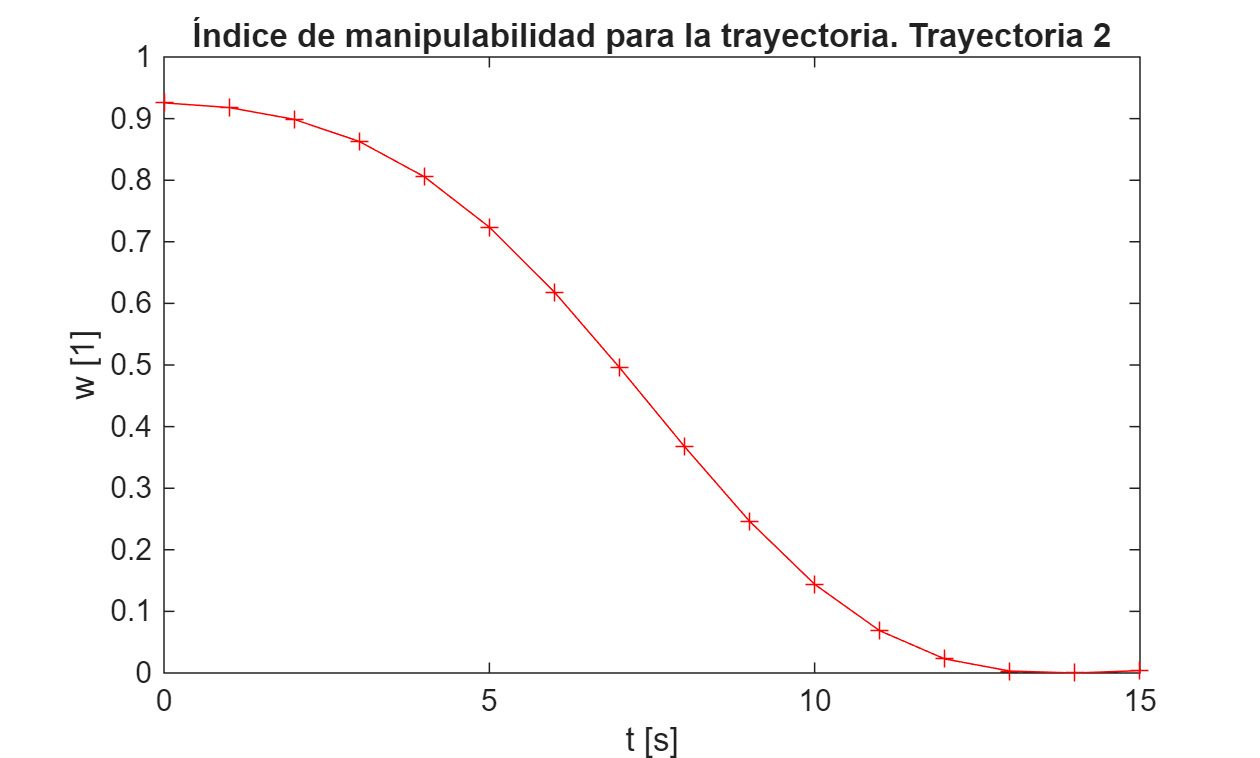

In [14]:

% Gráfica del índice de manipulabilidad

figure;

plot(tsim, w, 'r-+');

title("Índice de manipulabilidad para la trayectoria. Trayectoria 2")
xlabel("t [s]")
ylabel("w [1]")


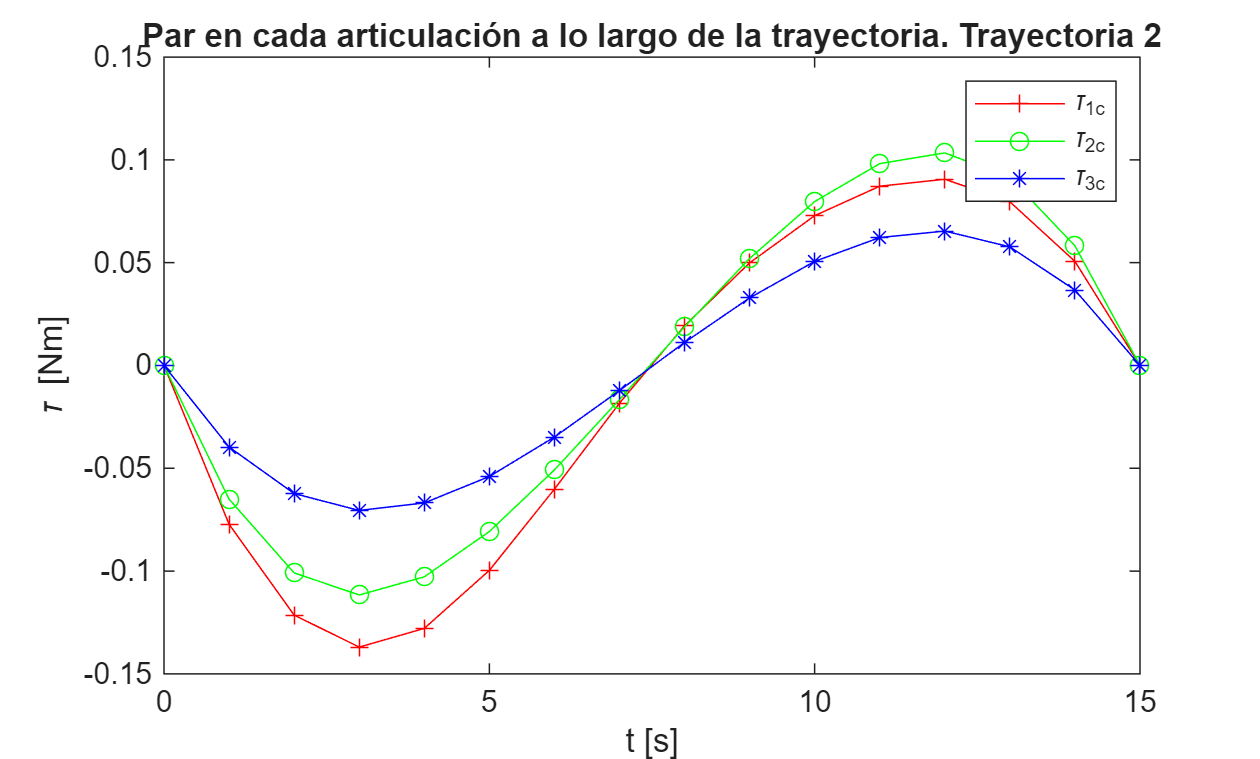

In [15]:

% Gráfica de los pares en las articulaciones

figure;

plot(tsim, tao_1_c, 'r-+');
hold on;
plot(tsim, tao_2_c, 'g-o');
plot(tsim, tao_3_c, 'b-*');

hold off;

legend('\tau_1_c','\tau_2_c','\tau_3_c')
title("Par en cada articulación a lo largo de la trayectoria. Trayectoria 2")
xlabel("t [s]")
ylabel("\tau [Nm]")


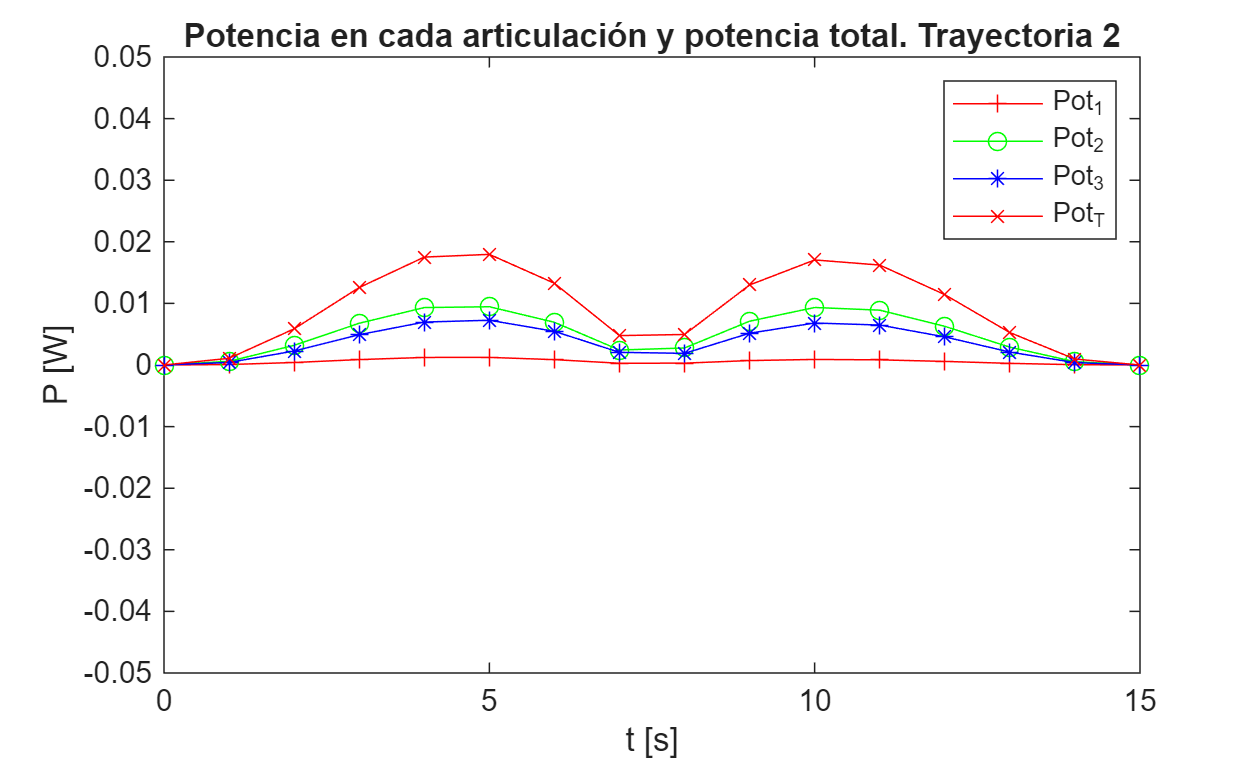

In [16]:

% Gráfica de la potencia en las articulaciones

figure;

plot(tsim, pot_1, 'r-+');
hold on;
plot(tsim, pot_2, 'g-o');
plot(tsim, pot_3, 'b-*');
plot(tsim, pot_total, 'r-x');

hold off;
xlim auto
ylim ([-0.05 0.05])
legend('Pot_1','Pot_2','Pot_3','Pot_T')
title("Potencia en cada articulación y potencia total. Trayectoria 2")
xlabel("t [s]")
ylabel("P [W]")

## Trayectoria 3


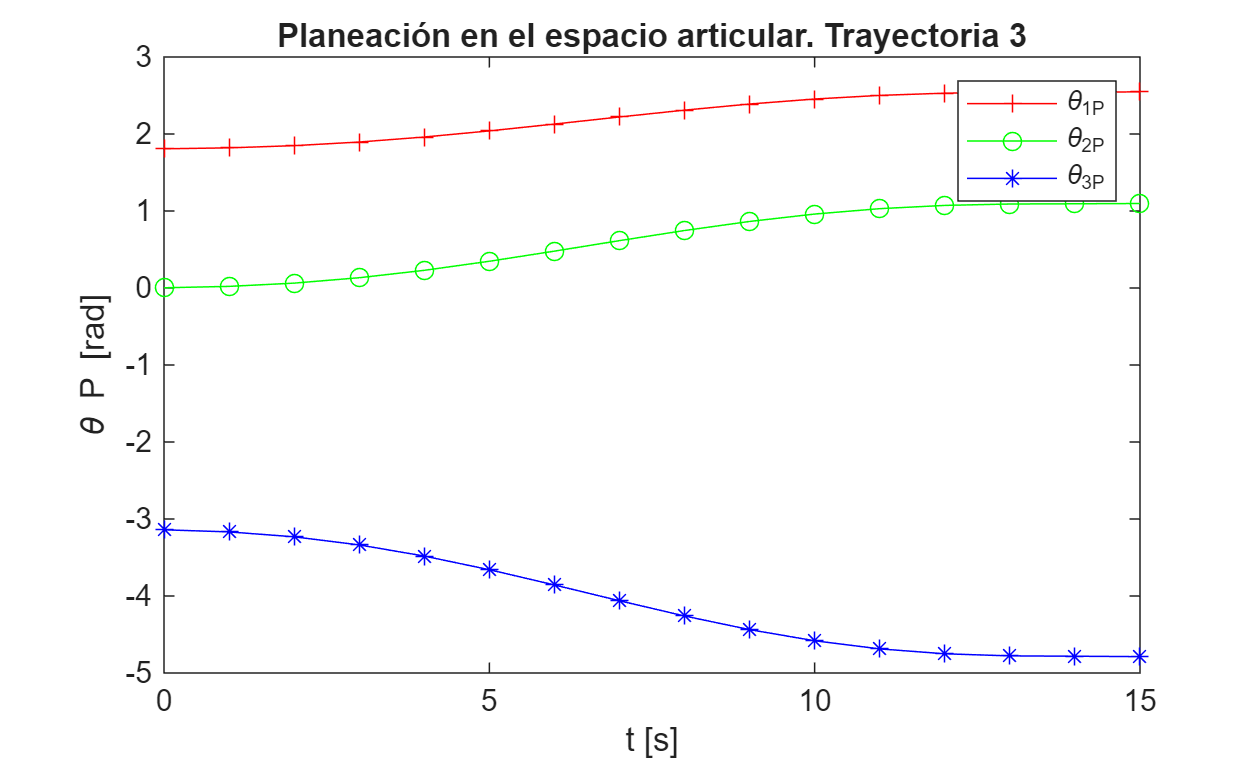

In [17]:
clear
clc

% 1) Definición de la postura inicial y final de la trayectoria

% Pose inicial
x_in = -0.25;
y_in = 1.05;
theta_in = -1.33; % 76.2°
% Pose final
x_fin = -0.25;
y_fin = 0.55;
theta_fin = -1.144; % -65.55°

% 2) Posición de la primer postura

% Definición de los parámetros del robot
L1 = 0.5; % Longitud del primer eslabón
L2 = 0.5; % Longitud del segundo eslabón
L3 = 0.25; % Longitud del tercer eslabón

% POSTURA DEL ROBOT PARA EL PUNTO INICIAL

x_3 = x_in - L3*cos(theta_in);
y_3 = y_in - L3*sin(theta_in);

% Solucion por el método geométrico

arg01 = (x_3^2+y_3^2-L1^2-L2^2)/(2*L1*L2);
arg01 = max(min(arg01,1),-1);
theta_2_in = acos(arg01);

beta = atan2(y_3,x_3);

arg02 = (x_3^2+y_3^2+L1^2-L2^2)/(2*L1*sqrt(x_3^2+y_3^2));
arg02 = max(min(arg02,1),-1);
psi = acos(arg02);

theta_1_in = beta + psi;

theta_3_in = theta_in -theta_1_in - theta_2_in;

% POSTURA DEL ROBOT PARA EL PUNTO FINAL

x_3 = x_fin - L3*cos(theta_fin);
y_3 = y_fin - L3*sin(theta_fin);

% Solucion por el método geométrico

arg01 = (x_3^2+y_3^2-L1^2-L2^2)/(2*L1*L2);
arg01 = max(min(arg01,1),-1);
theta_2_fin = acos(arg01);

beta = atan2(y_3,x_3);

arg02 = (x_3^2+y_3^2+L1^2-L2^2)/(2*L1*sqrt(x_3^2+y_3^2));
arg02 = max(min(arg02,1),-1);
psi = acos(arg02);

theta_1_fin = beta + psi;

theta_3_fin = theta_fin - theta_1_fin - theta_2_fin;

% 3) Trayectoria en el espacio de las juntas

tf = 15; % Se define un tiempo para que el robot haga su movimiento [s]

for i=1:tf+1
    t = i; % Incremento de tiempo para la siguiente iteración
    theta_1_P(i) = theta_1_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_1_fin-theta_1_in);
    theta_2_P(i) = theta_2_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_2_fin-theta_2_in);
    theta_3_P(i) = theta_3_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_3_fin-theta_3_in);

end

% 4) Trayectoria en el espacio de trabajo

for i=1:tf+1
    t = i;
    x_P(i) = x_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(x_fin-x_in);
    y_P(i) = y_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(y_fin-y_in);
    theta_P(i) = theta_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_fin-theta_in);

    x_3_a(i) = x_P(i) - L3*cos(theta_P(i));
    y_3_a(i) = y_P(i) - L3*sin(theta_P(i));

    % Solucion por el método geométrico

    arg1 = ((x_3_a(i)^2+y_3_a(i)^2-L1^2-L2^2)/(2*L1*L2));
    arg1 = max(min(arg1,1),-1);  % limitar entre [-1,1]

    theta_2_tray(i) = acos(arg1);

    beta = atan2(y_3_a(i),x_3_a(i));

    arg2 = ((x_3_a(i)^2+y_3_a(i)^2+L1^2-L2^2)/(2*L1*sqrt(x_3_a(i)^2+y_3_a(i)^2)));
    arg2 = max(min(arg2,1),-1);  % limitar entre [-1,1]
    psi = acos(arg2);

    theta_1_tray(i) = beta + psi;

    theta_3_tray(i) = theta_P(i) - theta_1_tray(i) - theta_2_tray(i);

end

% 5) Velocidades y aceleraciones en el espacio de las juntas

for i=1:tf+1
    t = i-1;
    theta_1_P_v(i) =  ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_1_fin-theta_1_in);
    theta_2_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_2_fin-theta_2_in);
    theta_3_P_v(i) =  ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_3_fin-theta_3_in);

end

for i=1:tf+1
    t = i-1;
    theta_1_P_a(i) =  ((60/tf^3)*t - (180/tf^4)*t^2 + (120/tf^5)*t^3)*(theta_1_fin-theta_1_in);
    theta_2_P_a(i) = ((60/tf^3)*t - (180/tf^4)*t^2 + (120/tf^5)*t^3)*(theta_2_fin-theta_2_in);
    theta_3_P_a(i) =  ((60/tf^3)*t - (180/tf^4)*t^2 + (120/tf^5)*t^3)*(theta_3_fin-theta_3_in);

end

% 6) Velocidades en el espacio de trabajo

for i=1:tf+1
    t = i;
    x_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(x_fin-x_in);
    y_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(y_fin-y_in);
    theta_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_fin-theta_in);

    x_dot = x_P_v(i);
    y_dot = y_P_v(i);
    theta_dot_P = theta_P_v(i);

    theta_O_1 = theta_1_tray(i);
    theta_1_2 = theta_2_tray(i);
    theta_2_3 = theta_3_tray(i);

    theta_1_v(i) = (x_dot*cos(theta_1_2 + theta_O_1))/(L1*sin(theta_1_2)) + (y_dot*sin(theta_1_2 + theta_O_1))/(L1*sin(theta_1_2)) + (L3*theta_dot_P*sin(theta_2_3))/(L1*sin(theta_1_2));
    theta_2_v(i) = - (x_dot*(L2*cos(theta_1_2 + theta_O_1) + L1*cos(theta_O_1)))/(L1*L2*sin(theta_1_2)) - (y_dot*(L2*sin(theta_1_2 + theta_O_1) + L1*sin(theta_O_1)))/(L1*L2*sin(theta_1_2)) - (L3*theta_dot_P*(L1*sin(theta_1_2 + theta_2_3) + L2*sin(theta_2_3)))/(L1*L2*sin(theta_1_2));
    theta_3_v(i) = (theta_dot_P*(L3*sin(theta_1_2 + theta_2_3) + L2*sin(theta_1_2)))/(L2*sin(theta_1_2)) + (x_dot*cos(theta_O_1))/(L2*sin(theta_1_2)) + (y_dot*sin(theta_O_1))/(L2*sin(theta_1_2));


end

% 7) Índice de manipulabilidad

for i=1:tf+1

    w(i) = abs(sin(theta_2_P(i)));

end

% 8) Cálculo de los pares en cada junta

for i=1:tf+1

    theta_1 = theta_1_P(i);
    theta_2 = theta_2_P(i);
    theta_3 = theta_3_P(i);

    theta_1_vc = theta_1_P_v(i);
    theta_2_vc = theta_2_P_v(i);
    theta_3_vc = theta_3_P_v(i);

    theta_1_a = theta_1_P_a(i);
    theta_2_a = theta_2_P_a(i);
    theta_3_a = theta_3_P_a(i);

    sigma_19 = sin(theta_2+theta_1)/2;
    sigma_18 = sin(theta_1+theta_2+theta_3);
    sigma_17 = cos(theta_2+theta_1)/2;
    sigma_16 = cos(theta_1+theta_2+theta_3);

    sigma_15 = theta_2_vc*(sigma_18/8 + sigma_19);
    sigma_14 = sigma_18/8 + sigma_19 + sin(theta_1)/2;
    sigma_13 = theta_2_vc *(sigma_16/8 +sigma_17);
    sigma_12 = sigma_16/8 +sigma_17 +cos(theta_1)/2;
    sigma_11 = theta_3_vc*sigma_18/8 + theta_1_vc*sigma_14 +sigma_15;
    sigma_10 = sigma_13 + theta_3_vc*sigma_16/8 +theta_1_vc*sigma_12;
    sigma_9 = ((sigma_16/8 + sigma_17)*sigma_11)/2;
    sigma_8 = ((sigma_18/8 + sigma_19)*sigma_10)/2;
    sigma_7 = (sigma_16*(sigma_16/8 + sigma_17))/16 + (sigma_18*(sigma_18/8 + sigma_19))/16 + 1;
    sigma_6 = sigma_16*sigma_12/16 + sigma_18*sigma_14 + 1;
    sigma_5 = theta_2_vc*sigma_16/8 + theta_3_vc*sigma_16/8 + theta_1_vc*sigma_16/8;
    sigma_4 = theta_2_vc*sigma_18/8 + theta_3_vc*sigma_18/8 + theta_1_vc*sigma_18/8;
    sigma_3 = cos(theta_2)/8 + ((sigma_16/8 + sigma_17)*sigma_12)/2 + ((sigma_18/8 + sigma_19)*sigma_14)/2 + 33/16;
    sigma_2 = sigma_13 +theta_1_vc*(sigma_16/8 + sigma_17) + theta_3_vc*sigma_16/8;
    sigma_1 = theta_3_vc*sigma_18/8 + sigma_15 +theta_1_vc*(sigma_18/8 + sigma_19);

    tao_1_c(i) = theta_1_a*(cos(theta_2)/4 + sigma_12^2/2 + sigma_14^2/2 + 27/8) - theta_3_vc* (sigma_18*sigma_10/16 - sigma_16*sigma_11/16 + sigma_12*sigma_4/2 - sigma_5*sigma_14/2) + theta_2_a*sigma_3 + theta_3_a*sigma_6 - theta_2_vc*(sigma_8 - sigma_14*sigma_2/2 + sigma_1*sigma_12/2 - sigma_9 + theta_2_vc*sin(theta_2)/8 + theta_1_vc*sin(theta_2)/4);
    tao_2_c(i) = theta_1_vc^2*sin(theta_2)/8 - theta_3_vc*(sigma_18*sigma_10 - ((sigma_18/8 + sigma_19)*sigma_5)/2 + ((sigma_16/8 + sigma_17)*sigma_4)/2 - sigma_16*sigma_11/16) + theta_2_a*sigma_7 + sigma_10*sigma_1/2 + theta_1_a*sigma_3 - sigma_11*sigma_2/2 + theta_2_a*(((sigma_16 + sigma_17)^2)/2 + ((sigma_18 + sigma_19)^2)/2 + 33/16) - theta_2_vc*((sigma_16/8 + sigma_17)*sigma_1/2 + (sigma_18/8 + sigma_19)*sigma_2/2 + sigma_8 - sigma_9 + theta_1_vc*sin(theta_2)/8) + theta_2_vc*theta_1_vc*sin(theta_2)/8;
    tao_3_c(i) = theta_3_a*(sigma_16^2/128 + sigma_18^2/128 + 1 ) - sigma_5*sigma_11/2 + theta_2_a*sigma_7 - theta_3_vc*(sigma_18*sigma_10/16 - sigma_18*sigma_5/16 - sigma_16*sigma_11/16 + sigma_16*sigma_4/16) + theta_2_vc*(sigma_18*sigma_2/16 - sigma_18*sigma_10/16 - sigma_16*sigma_1/16 + sigma_16*sigma_11/16) + theta_1_a*sigma_6 + sigma_10*sigma_4/2;

end

% 9) Cálculo de la potencia por junta y total

for i=1:tf+1
    theta_1_vc = theta_1_P_v(i);
    theta_2_vc = theta_2_P_v(i);
    theta_3_vc = theta_3_P_v(i);

    pot_1(i) = abs(tao_1_c(i)*theta_1_vc);
    pot_2(i) = abs(tao_2_c(i)*theta_2_vc);
    pot_3(i) = abs(tao_3_c(i)*theta_3_vc);
    pot_total(i) = pot_1(i) + pot_2(i) + pot_3(i);
end

% 10) Gráficas

tsim = 0:1:tf; % tiempo de simulación para las gráficas

% Gráfica de la trayectoria en el espacio de las juntas

figure;

plot(tsim, theta_1_P, 'r-+');
hold on;
plot(tsim, theta_2_P, 'g-o');
plot(tsim, theta_3_P, 'b-*');

hold off;

xlim auto
ylim auto
legend('\theta_1_P','\theta_2_P','\theta_3_P')
title("Planeación en el espacio articular. Trayectoria 3")
xlabel("t [s]")
ylabel("\theta P [rad]")


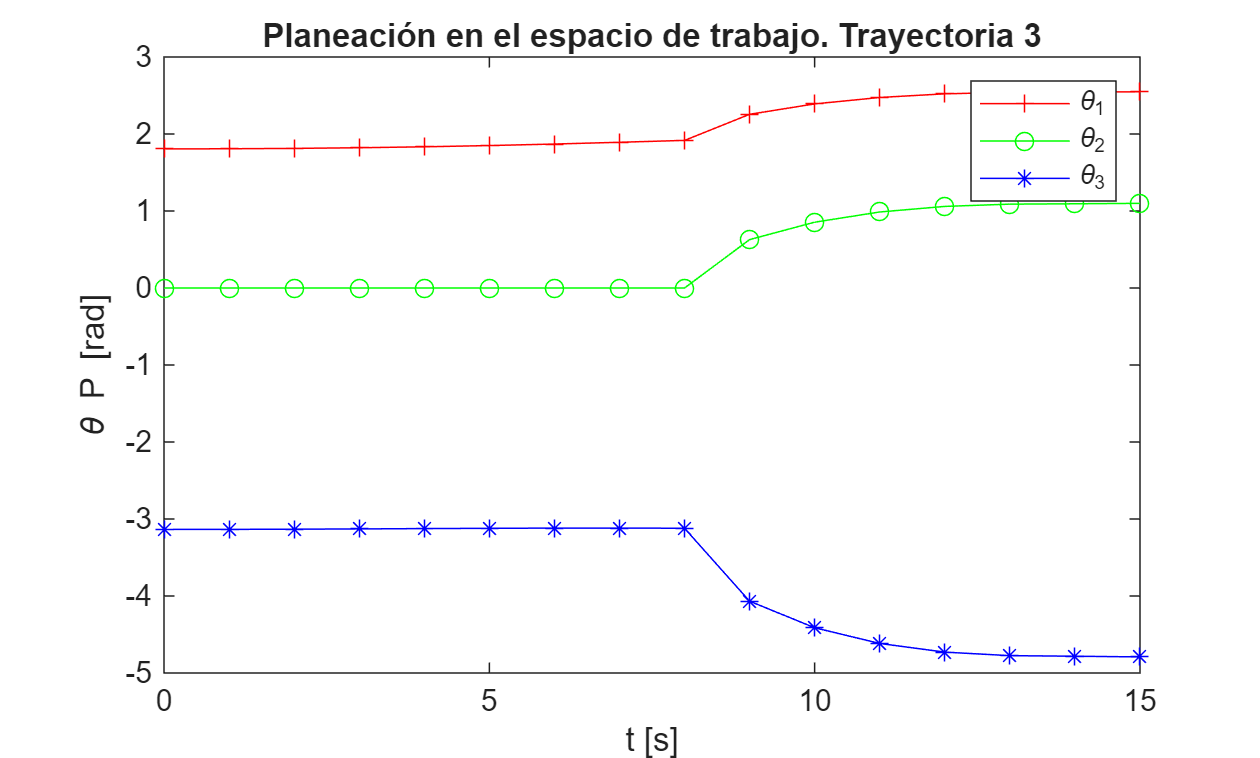

In [18]:

% Gráfica de la trayectoria en el espacio de trabajo

figure;

plot(tsim, theta_1_tray, 'r-+');
hold on;
plot(tsim, theta_2_tray, 'g-o');
plot(tsim, theta_3_tray, 'b-*');

hold off;

xlim auto
ylim auto
legend('\theta_1','\theta_2','\theta_3')
title("Planeación en el espacio de trabajo. Trayectoria 3")
xlabel("t [s]")
ylabel("\theta P [rad]")


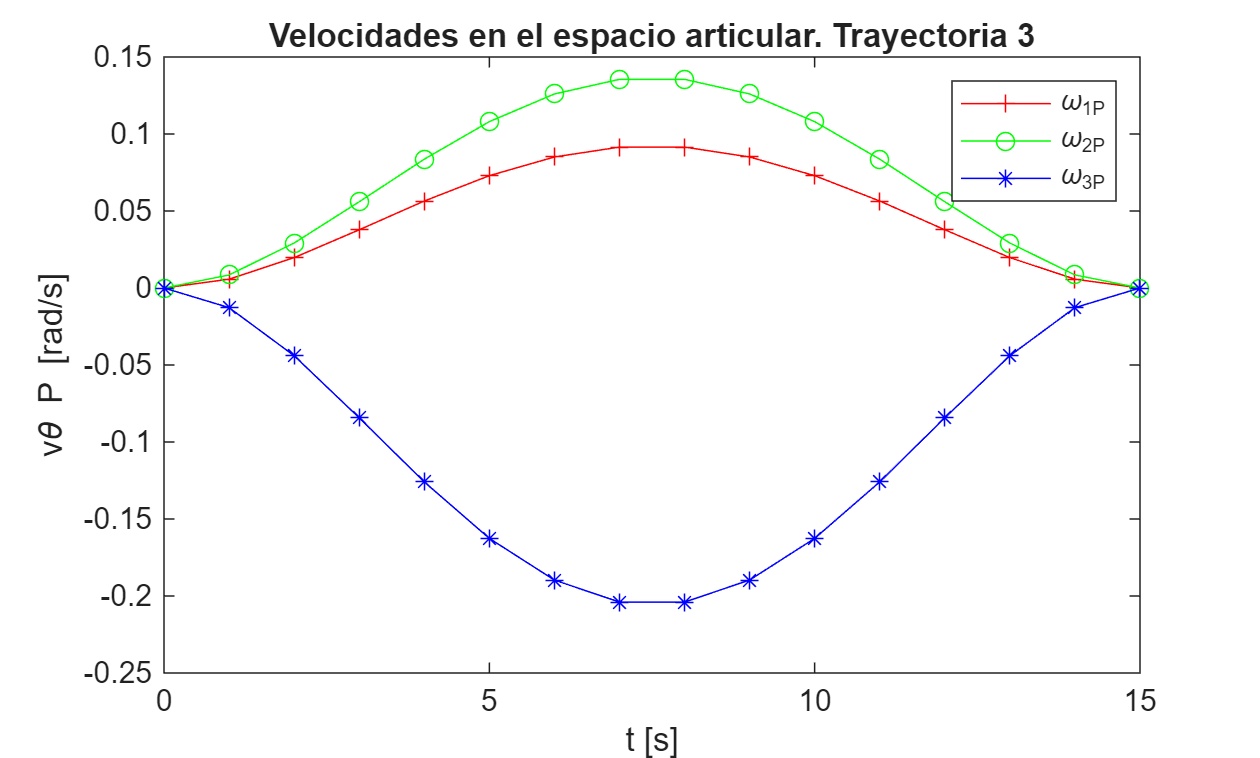

In [19]:

% Gráfica de las velocidades en el espacio articular

figure;

plot(tsim, theta_1_P_v, 'r-+');
hold on;
plot(tsim, theta_2_P_v, 'g-o');
plot(tsim, theta_3_P_v, 'b-*');

hold off;

legend('\omega_1_P','\omega_2_P','\omega_3_P')
title("Velocidades en el espacio articular. Trayectoria 3")
xlabel("t [s]")
ylabel("v\theta P [rad/s]")


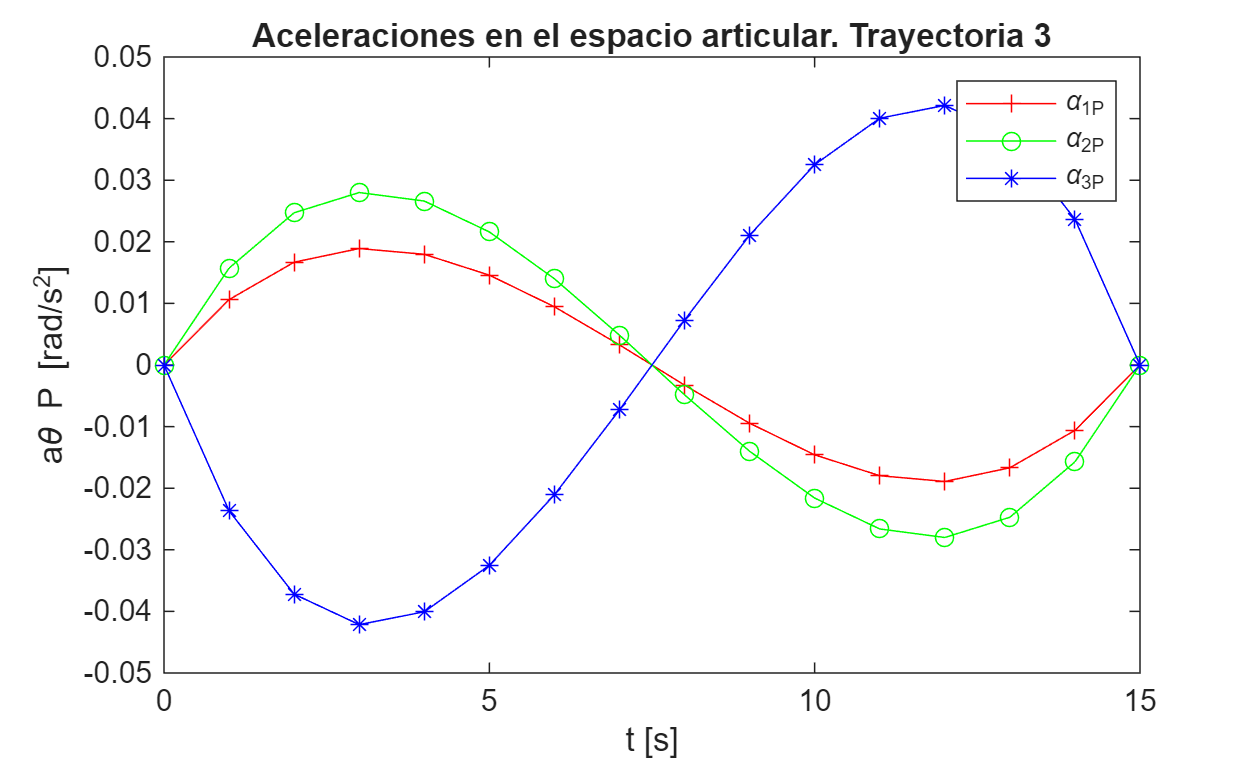

In [20]:

% Gráfica de las aceleraciones en el espacio articular

figure;

plot(tsim, theta_1_P_a, 'r-+');
hold on;
plot(tsim, theta_2_P_a, 'g-o');
plot(tsim, theta_3_P_a, 'b-*');

hold off;

legend('\alpha_1_P','\alpha_2_P','\alpha_3_P')
title("Aceleraciones en el espacio articular. Trayectoria 3")
xlabel("t [s]")
ylabel("a\theta P [rad/s^2]")


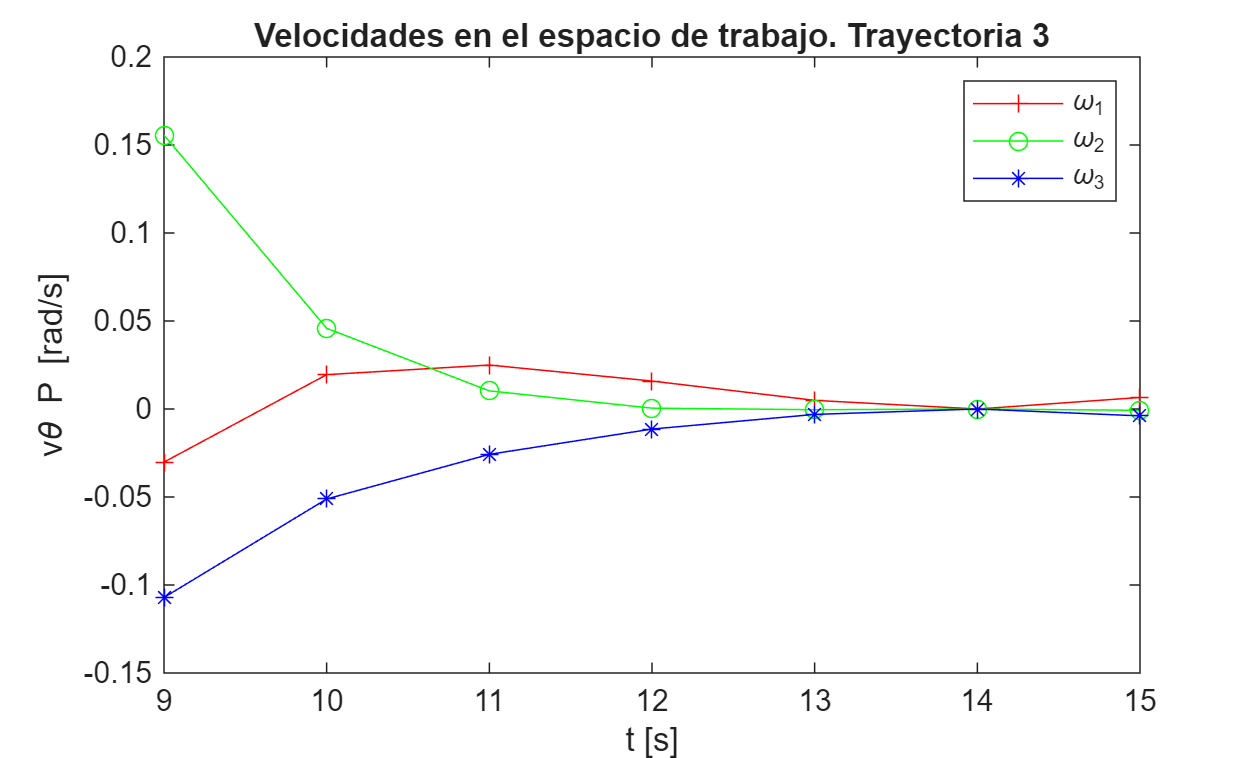

In [21]:

% Gráfica de las velocidades en el espacio de trabajo

figure;

plot(tsim, theta_1_v, 'r-+');
hold on;
plot(tsim, theta_2_v, 'g-o');
plot(tsim, theta_3_v, 'b-*');

hold off;

legend('\omega_1','\omega_2','\omega_3')
title("Velocidades en el espacio de trabajo. Trayectoria 3")
xlabel("t [s]")
ylabel("v\theta P [rad/s]")


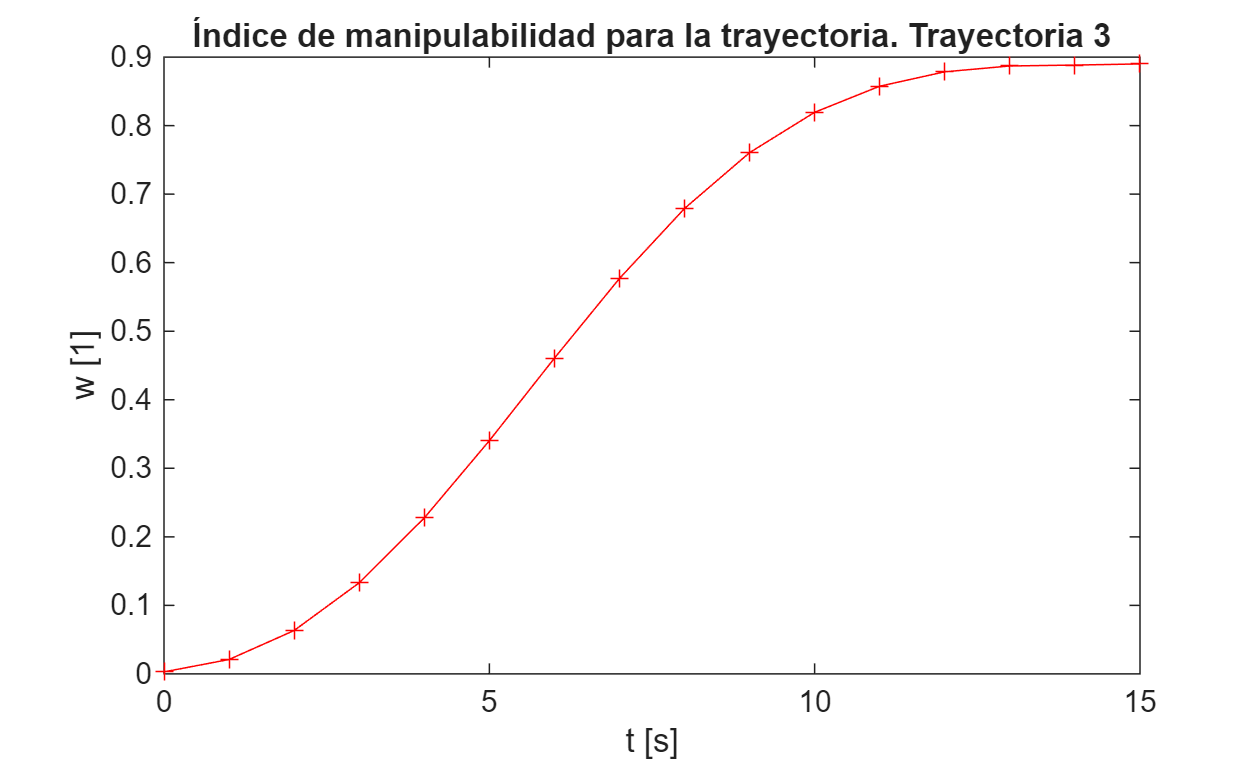

In [22]:

% Gráfica del índice de manipulabilidad

figure;

plot(tsim, w, 'r-+');

title("Índice de manipulabilidad para la trayectoria. Trayectoria 3")
xlabel("t [s]")
ylabel("w [1]")


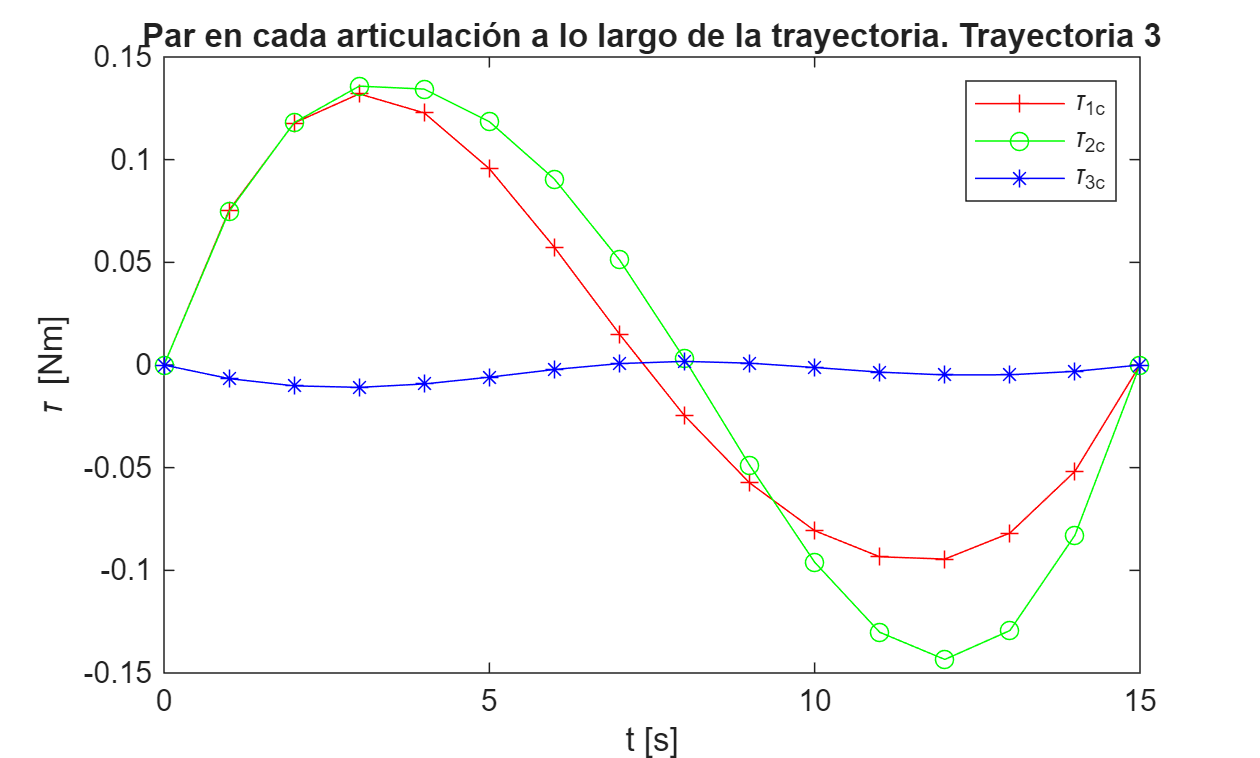

In [23]:

% Gráfica de los pares en las articulaciones

figure;

plot(tsim, tao_1_c, 'r-+');
hold on;
plot(tsim, tao_2_c, 'g-o');
plot(tsim, tao_3_c, 'b-*');

hold off;

legend('\tau_1_c','\tau_2_c','\tau_3_c')
title("Par en cada articulación a lo largo de la trayectoria. Trayectoria 3")
xlabel("t [s]")
ylabel("\tau [Nm]")


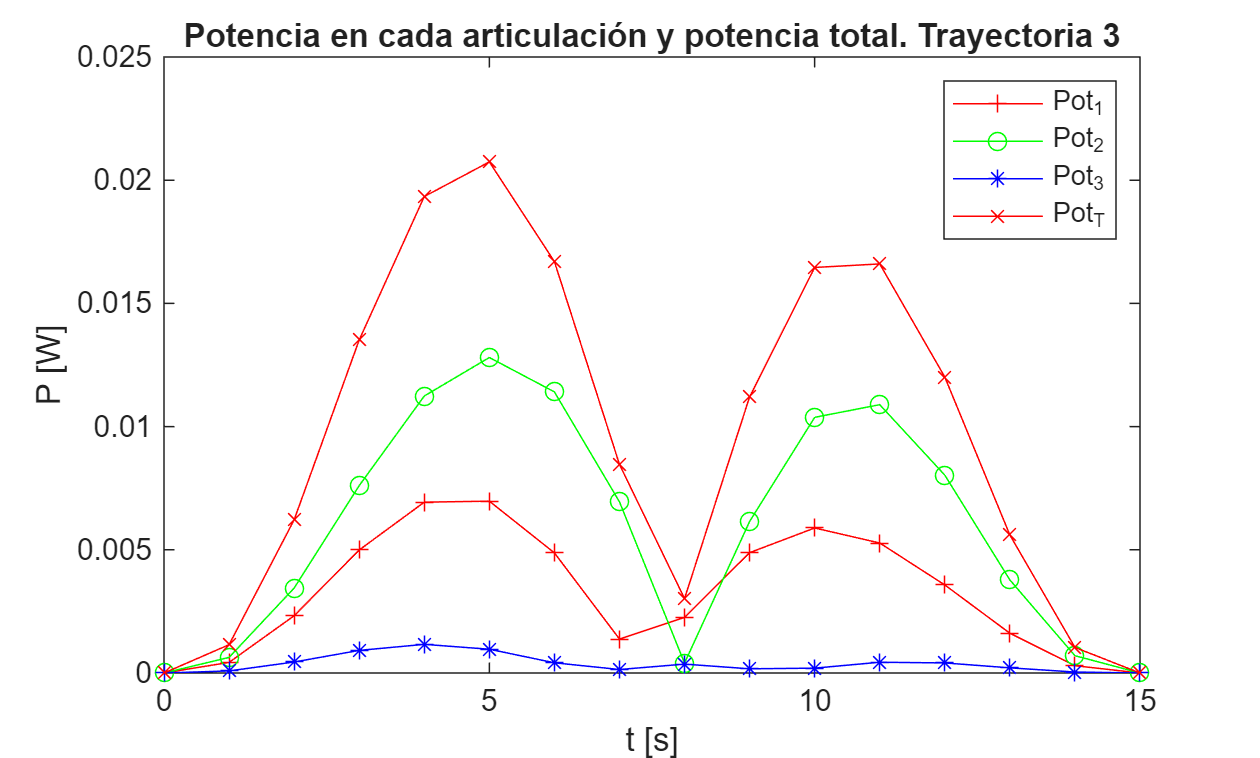

In [24]:

% Gráfica de la potencia en las articulaciones

figure;

plot(tsim, pot_1, 'r-+');
hold on;
plot(tsim, pot_2, 'g-o');
plot(tsim, pot_3, 'b-*');
plot(tsim, pot_total, 'r-x');

hold off;

legend('Pot_1','Pot_2','Pot_3','Pot_T')
title("Potencia en cada articulación y potencia total. Trayectoria 3")
xlabel("t [s]")
ylabel("P [W]")


## Trayectoria 4


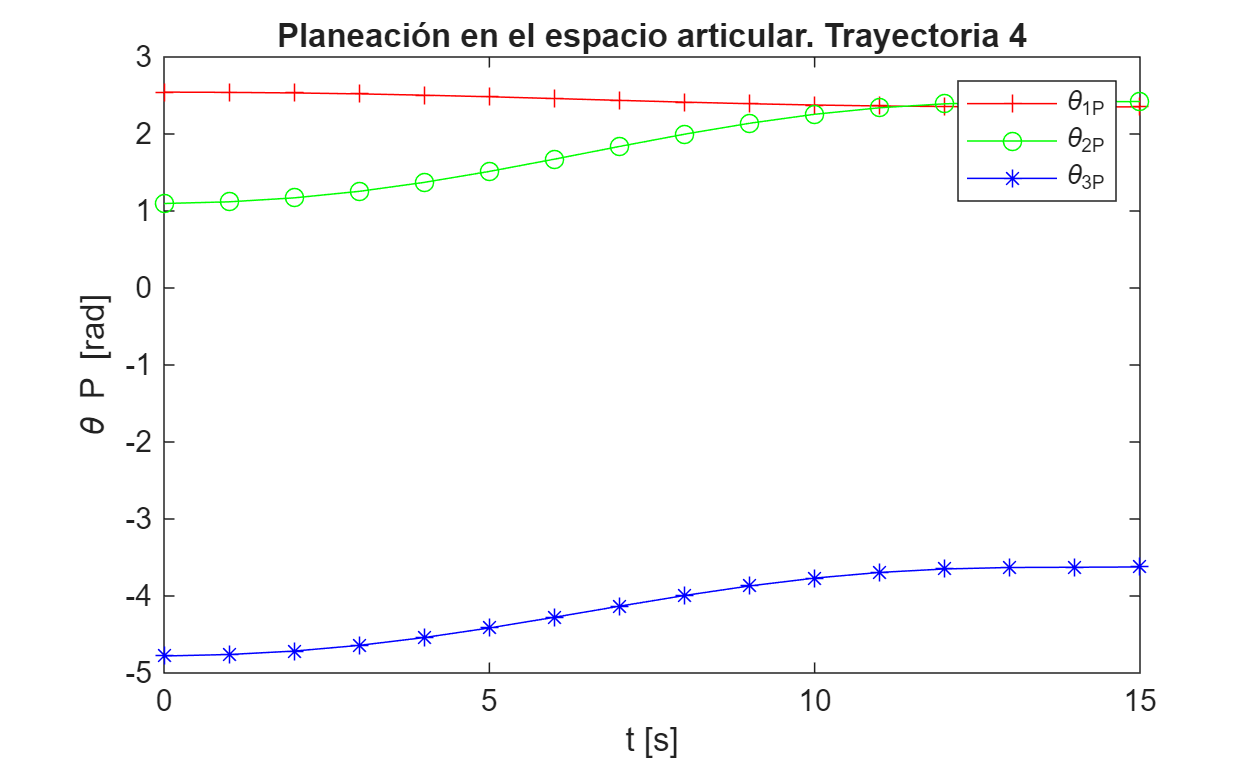

In [25]:
clear
clc

% 1) Definición de la postura inicial y final de la trayectoria

% Pose inicial
x_in = -0.25;
y_in = 0.55;
theta_in = -1.144; % -65.55°
% Pose final
x_fin = 0.25;
y_fin = 0.55;
theta_fin = 1.144; % 65.55°

% 2) Posición de la primer postura

% Definición de los parámetros del robot
L1 = 0.5; % Longitud del primer eslabón
L2 = 0.5; % Longitud del segundo eslabón
L3 = 0.25; % Longitud del tercer eslabón

% POSTURA DEL ROBOT PARA EL PUNTO INICIAL

x_3 = x_in - L3*cos(theta_in);
y_3 = y_in - L3*sin(theta_in);

% Solucion por el método geométrico

arg01 = (x_3^2+y_3^2-L1^2-L2^2)/(2*L1*L2);
arg01 = max(min(arg01,1),-1);
theta_2_in = acos(arg01);

beta = atan2(y_3,x_3);

arg02 = (x_3^2+y_3^2+L1^2-L2^2)/(2*L1*sqrt(x_3^2+y_3^2));
arg02 = max(min(arg02,1),-1);
psi = acos(arg02);

theta_1_in = beta + psi;

theta_3_in = theta_in -theta_1_in - theta_2_in;

% POSTURA DEL ROBOT PARA EL PUNTO FINAL

x_3 = x_fin - L3*cos(theta_fin);
y_3 = y_fin - L3*sin(theta_fin);

% Solucion por el método geométrico

arg01 = (x_3^2+y_3^2-L1^2-L2^2)/(2*L1*L2);
arg01 = max(min(arg01,1),-1);
theta_2_fin = acos(arg01);

beta = atan2(y_3,x_3);

arg02 = (x_3^2+y_3^2+L1^2-L2^2)/(2*L1*sqrt(x_3^2+y_3^2));
arg02 = max(min(arg02,1),-1);
psi = acos(arg02);

theta_1_fin = beta + psi;

theta_3_fin = theta_fin - theta_1_fin - theta_2_fin;

% 3) Trayectoria en el espacio de las juntas

tf = 15; % Se define un tiempo para que el robot haga su movimiento

for i=1:tf+1
    t = i; % Incremento de tiempo para la siguiente iteración
    theta_1_P(i) = theta_1_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_1_fin-theta_1_in);
    theta_2_P(i) = theta_2_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_2_fin-theta_2_in);
    theta_3_P(i) = theta_3_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_3_fin-theta_3_in);

end

% 4) Trayectoria en el espacio de trabajo

for i=1:tf+1
    t = i;
    x_P(i) = x_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(x_fin-x_in);
    y_P(i) = y_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(y_fin-y_in);
    theta_P(i) = theta_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_fin-theta_in);

    x_3_a(i) = x_P(i) - L3*cos(theta_P(i));
    y_3_a(i) = y_P(i) - L3*sin(theta_P(i));

    % Solucion por el método geométrico

    arg1 = ((x_3_a(i)^2+y_3_a(i)^2-L1^2-L2^2)/(2*L1*L2));
    arg1 = max(min(arg1,1),-1);  % limitar entre [-1,1]

    theta_2_tray(i) = acos(arg1);

    beta = atan2(y_3_a(i),x_3_a(i));

    arg2 = ((x_3_a(i)^2+y_3_a(i)^2+L1^2-L2^2)/(2*L1*sqrt(x_3_a(i)^2+y_3_a(i)^2)));
    arg2 = max(min(arg2,1),-1);  % limitar entre [-1,1]
    psi = acos(arg2);

    theta_1_tray(i) = beta + psi;

    theta_3_tray(i) = theta_P(i) - theta_1_tray(i) - theta_2_tray(i);

end

% 5) Velocidades y aceleraciones en el espacio de las juntas

for i=1:tf+1
    t = i-1;
    theta_1_P_v(i) =  ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_1_fin-theta_1_in);
    theta_2_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_2_fin-theta_2_in);
    theta_3_P_v(i) =  ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_3_fin-theta_3_in);

end

for i=1:tf+1
    t = i-1;
    theta_1_P_a(i) =  ((60/tf^3)*t - (180/tf^4)*t^2 + (120/tf^5)*t^3)*(theta_1_fin-theta_1_in);
    theta_2_P_a(i) = ((60/tf^3)*t - (180/tf^4)*t^2 + (120/tf^5)*t^3)*(theta_2_fin-theta_2_in);
    theta_3_P_a(i) =  ((60/tf^3)*t - (180/tf^4)*t^2 + (120/tf^5)*t^3)*(theta_3_fin-theta_3_in);

end

% 6) Velocidades en el espacio de trabajo

for i=1:tf+1
    t = i;
    x_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(x_fin-x_in);
    y_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(y_fin-y_in);
    theta_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_fin-theta_in);

    x_dot = x_P_v(i);
    y_dot = y_P_v(i);
    theta_dot_P = theta_P_v(i);

    theta_O_1 = theta_1_tray(i);
    theta_1_2 = theta_2_tray(i);
    theta_2_3 = theta_3_tray(i);

    theta_1_v(i) = (x_dot*cos(theta_1_2 + theta_O_1))/(L1*sin(theta_1_2)) + (y_dot*sin(theta_1_2 + theta_O_1))/(L1*sin(theta_1_2)) + (L3*theta_dot_P*sin(theta_2_3))/(L1*sin(theta_1_2));
    theta_2_v(i) = - (x_dot*(L2*cos(theta_1_2 + theta_O_1) + L1*cos(theta_O_1)))/(L1*L2*sin(theta_1_2)) - (y_dot*(L2*sin(theta_1_2 + theta_O_1) + L1*sin(theta_O_1)))/(L1*L2*sin(theta_1_2)) - (L3*theta_dot_P*(L1*sin(theta_1_2 + theta_2_3) + L2*sin(theta_2_3)))/(L1*L2*sin(theta_1_2));
    theta_3_v(i) = (theta_dot_P*(L3*sin(theta_1_2 + theta_2_3) + L2*sin(theta_1_2)))/(L2*sin(theta_1_2)) + (x_dot*cos(theta_O_1))/(L2*sin(theta_1_2)) + (y_dot*sin(theta_O_1))/(L2*sin(theta_1_2));


end

% 7) Índice de manipulabilidad

for i=1:tf+1

    w(i) = abs(sin(theta_2_tray(i)));

end

% 8) Cálculo de los pares en cada junta

for i=1:tf+1

    theta_1 = theta_1_P(i);
    theta_2 = theta_2_P(i);
    theta_3 = theta_3_P(i);

    theta_1_vc = theta_1_P_v(i);
    theta_2_vc = theta_2_P_v(i);
    theta_3_vc = theta_3_P_v(i);

    theta_1_a = theta_1_P_a(i);
    theta_2_a = theta_2_P_a(i);
    theta_3_a = theta_3_P_a(i);

    sigma_19 = sin(theta_2+theta_1)/2;
    sigma_18 = sin(theta_1+theta_2+theta_3);
    sigma_17 = cos(theta_2+theta_1)/2;
    sigma_16 = cos(theta_1+theta_2+theta_3);

    sigma_15 = theta_2_vc*(sigma_18/8 + sigma_19);
    sigma_14 = sigma_18/8 + sigma_19 + sin(theta_1)/2;
    sigma_13 = theta_2_vc *(sigma_16/8 +sigma_17);
    sigma_12 = sigma_16/8 +sigma_17 +cos(theta_1)/2;
    sigma_11 = theta_3_vc*sigma_18/8 + theta_1_vc*sigma_14 +sigma_15;
    sigma_10 = sigma_13 + theta_3_vc*sigma_16/8 +theta_1_vc*sigma_12;
    sigma_9 = ((sigma_16/8 + sigma_17)*sigma_11)/2;
    sigma_8 = ((sigma_18/8 + sigma_19)*sigma_10)/2;
    sigma_7 = (sigma_16*(sigma_16/8 + sigma_17))/16 + (sigma_18*(sigma_18/8 + sigma_19))/16 + 1;
    sigma_6 = sigma_16*sigma_12/16 + sigma_18*sigma_14 + 1;
    sigma_5 = theta_2_vc*sigma_16/8 + theta_3_vc*sigma_16/8 + theta_1_vc*sigma_16/8;
    sigma_4 = theta_2_vc*sigma_18/8 + theta_3_vc*sigma_18/8 + theta_1_vc*sigma_18/8;
    sigma_3 = cos(theta_2)/8 + ((sigma_16/8 + sigma_17)*sigma_12)/2 + ((sigma_18/8 + sigma_19)*sigma_14)/2 + 33/16;
    sigma_2 = sigma_13 +theta_1_vc*(sigma_16/8 + sigma_17) + theta_3_vc*sigma_16/8;
    sigma_1 = theta_3_vc*sigma_18/8 + sigma_15 +theta_1_vc*(sigma_18/8 + sigma_19);

    tao_1_c(i) = theta_1_a*(cos(theta_2)/4 + sigma_12^2/2 + sigma_14^2/2 + 27/8) - theta_3_vc* (sigma_18*sigma_10/16 - sigma_16*sigma_11/16 + sigma_12*sigma_4/2 - sigma_5*sigma_14/2) + theta_2_a*sigma_3 + theta_3_a*sigma_6 - theta_2_vc*(sigma_8 - sigma_14*sigma_2/2 + sigma_1*sigma_12/2 - sigma_9 + theta_2_vc*sin(theta_2)/8 + theta_1_vc*sin(theta_2)/4);
    tao_2_c(i) = theta_1_vc^2*sin(theta_2)/8 - theta_3_vc*(sigma_18*sigma_10 - ((sigma_18/8 + sigma_19)*sigma_5)/2 + ((sigma_16/8 + sigma_17)*sigma_4)/2 - sigma_16*sigma_11/16) + theta_2_a*sigma_7 + sigma_10*sigma_1/2 + theta_1_a*sigma_3 - sigma_11*sigma_2/2 + theta_2_a*(((sigma_16 + sigma_17)^2)/2 + ((sigma_18 + sigma_19)^2)/2 + 33/16) - theta_2_vc*((sigma_16/8 + sigma_17)*sigma_1/2 + (sigma_18/8 + sigma_19)*sigma_2/2 + sigma_8 - sigma_9 + theta_1_vc*sin(theta_2)/8) + theta_2_vc*theta_1_vc*sin(theta_2)/8;
    tao_3_c(i) = theta_3_a*(sigma_16^2/128 + sigma_18^2/128 + 1 ) - sigma_5*sigma_11/2 + theta_2_a*sigma_7 - theta_3_vc*(sigma_18*sigma_10/16 - sigma_18*sigma_5/16 - sigma_16*sigma_11/16 + sigma_16*sigma_4/16) + theta_2_vc*(sigma_18*sigma_2/16 - sigma_18*sigma_10/16 - sigma_16*sigma_1/16 + sigma_16*sigma_11/16) + theta_1_a*sigma_6 + sigma_10*sigma_4/2;

end

% 9) Cálculo de la potencia por junta y total

for i=1:tf+1
    theta_1_vc = theta_1_P_v(i);
    theta_2_vc = theta_2_P_v(i);
    theta_3_vc = theta_3_P_v(i);

    pot_1(i) = abs(tao_1_c(i)*theta_1_vc);
    pot_2(i) = abs(tao_2_c(i)*theta_2_vc);
    pot_3(i) = abs(tao_3_c(i)*theta_3_vc);
    pot_total(i) = pot_1(i) + pot_2(i) + pot_3(i);
end

% 10) Gráficas

tsim = 0:1:tf; % tiempo de simulación para las gráficas

% Gráfica de la trayectoria en el espacio de las juntas

figure;

plot(tsim, theta_1_P, 'r-+');
hold on;
plot(tsim, theta_2_P, 'g-o');
plot(tsim, theta_3_P, 'b-*');

hold off;

xlim auto
ylim auto
legend('\theta_1_P','\theta_2_P','\theta_3_P')
title("Planeación en el espacio articular. Trayectoria 4")
xlabel("t [s]")
ylabel("\theta P [rad]")


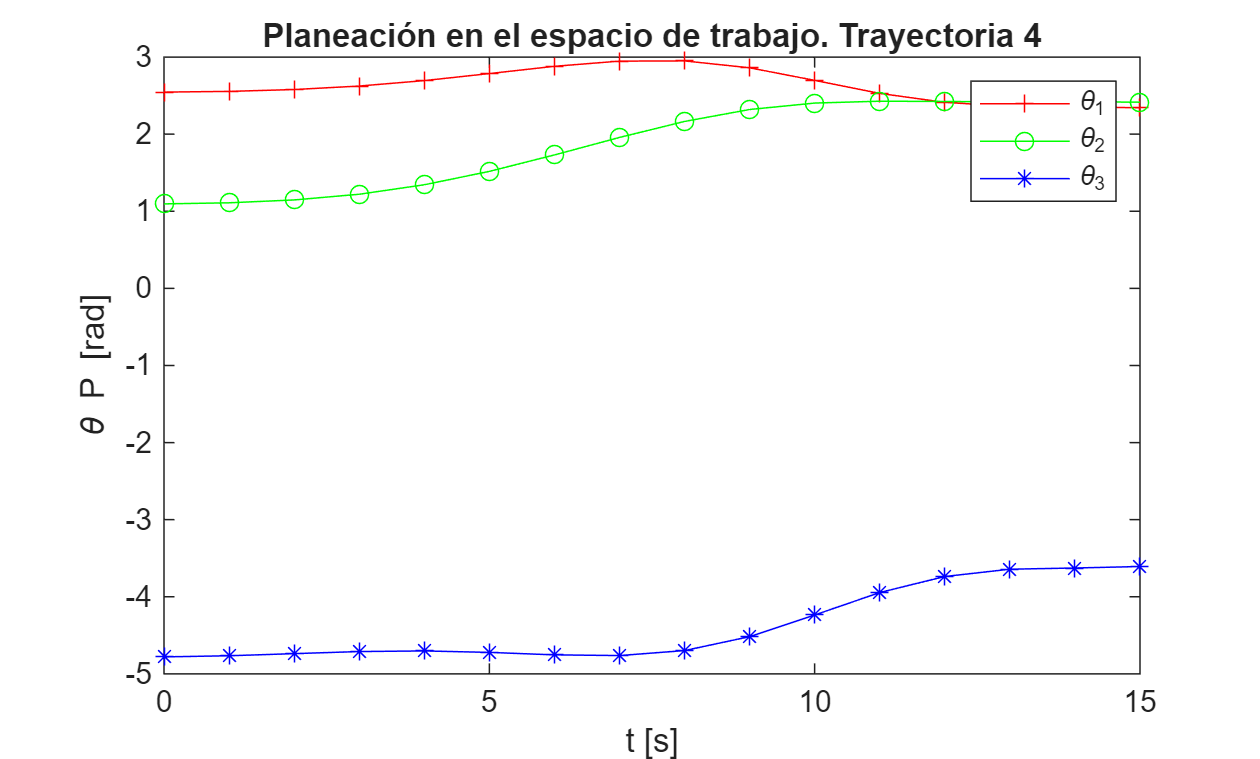

In [26]:

% Gráfica de la trayectoria en el espacio de trabajo

figure;

plot(tsim, theta_1_tray, 'r-+');
hold on;
plot(tsim, theta_2_tray, 'g-o');
plot(tsim, theta_3_tray, 'b-*');

hold off;

xlim auto
ylim auto
legend('\theta_1','\theta_2','\theta_3')
title("Planeación en el espacio de trabajo. Trayectoria 4")
xlabel("t [s]")
ylabel("\theta P [rad]")


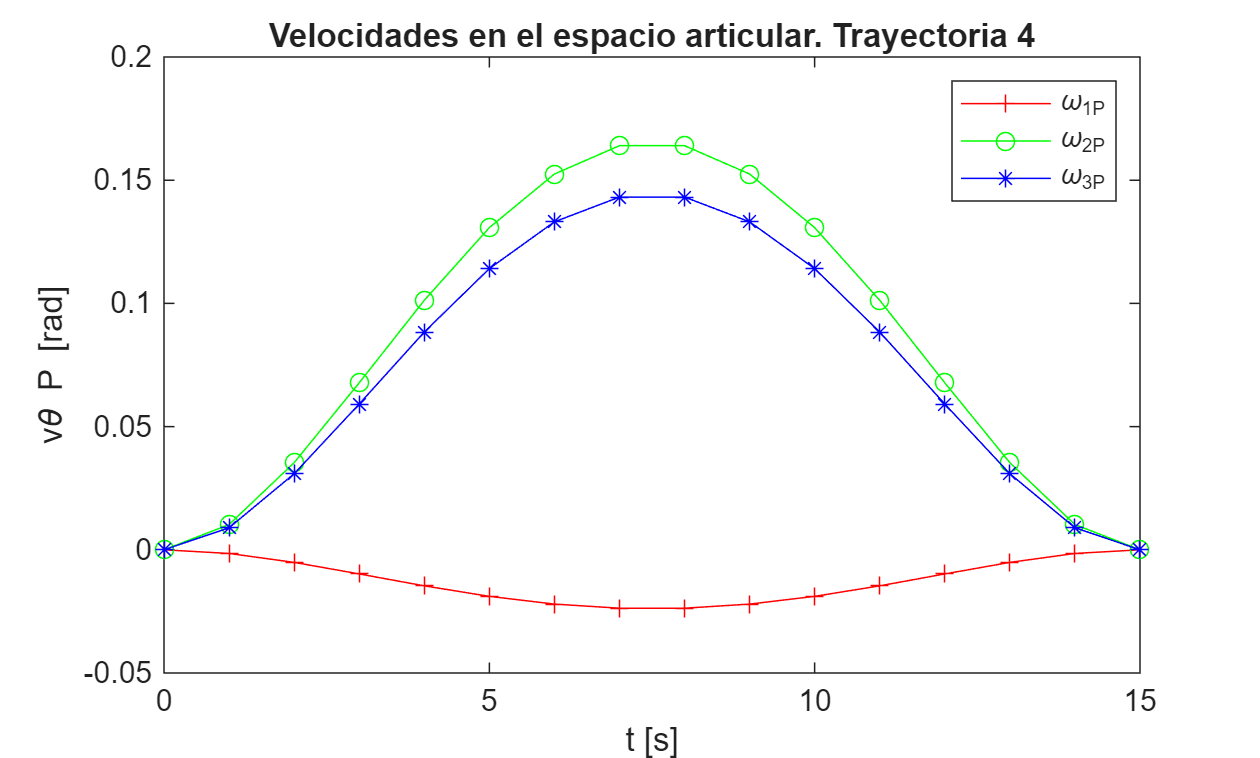

In [27]:

% Gráfica de las velocidades en el espacio articular

figure;

plot(tsim, theta_1_P_v, 'r-+');
hold on;
plot(tsim, theta_2_P_v, 'g-o');
plot(tsim, theta_3_P_v, 'b-*');

hold off;

legend('\omega_1_P','\omega_2_P','\omega_3_P')
title("Velocidades en el espacio articular. Trayectoria 4")
xlabel("t [s]")
ylabel("v\theta P [rad]")


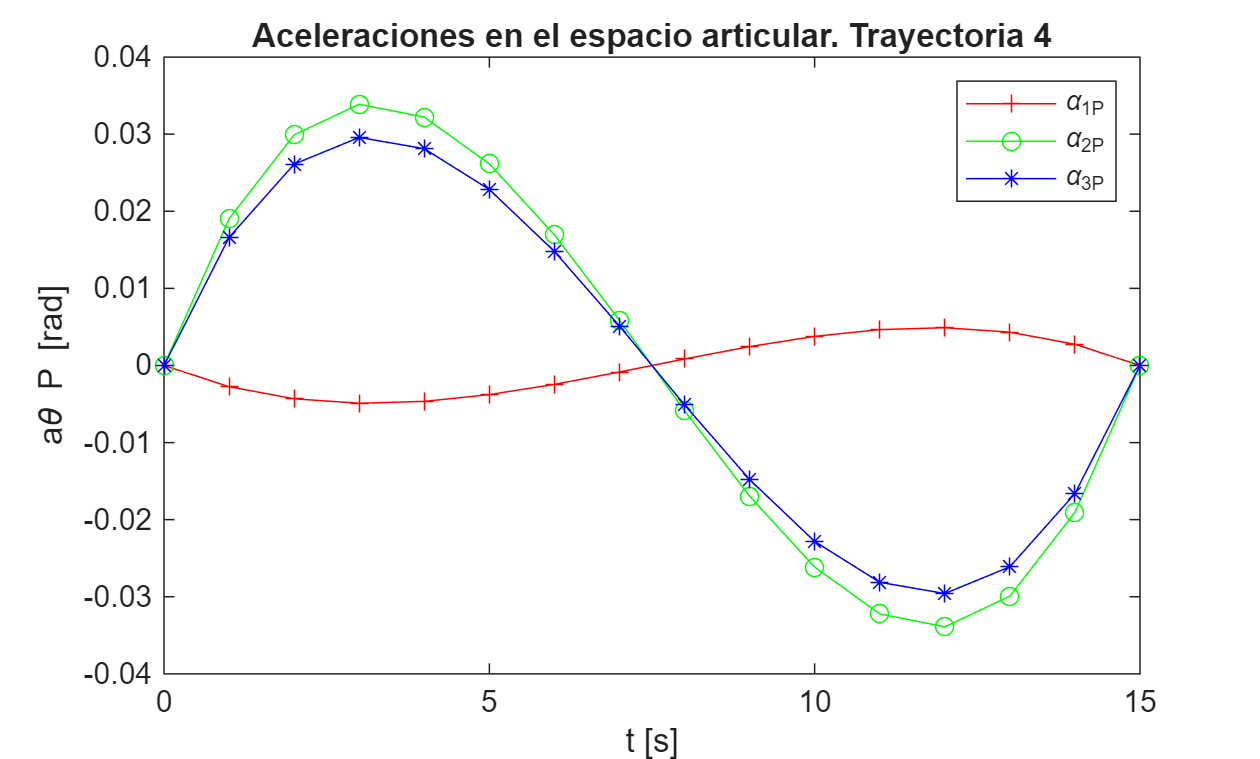

In [28]:

% Gráfica de las aceleraciones en el espacio articular

figure;

plot(tsim, theta_1_P_a, 'r-+');
hold on;
plot(tsim, theta_2_P_a, 'g-o');
plot(tsim, theta_3_P_a, 'b-*');

hold off;

legend('\alpha_1_P','\alpha_2_P','\alpha_3_P')
title("Aceleraciones en el espacio articular. Trayectoria 4")
xlabel("t [s]")
ylabel("a\theta P [rad]")


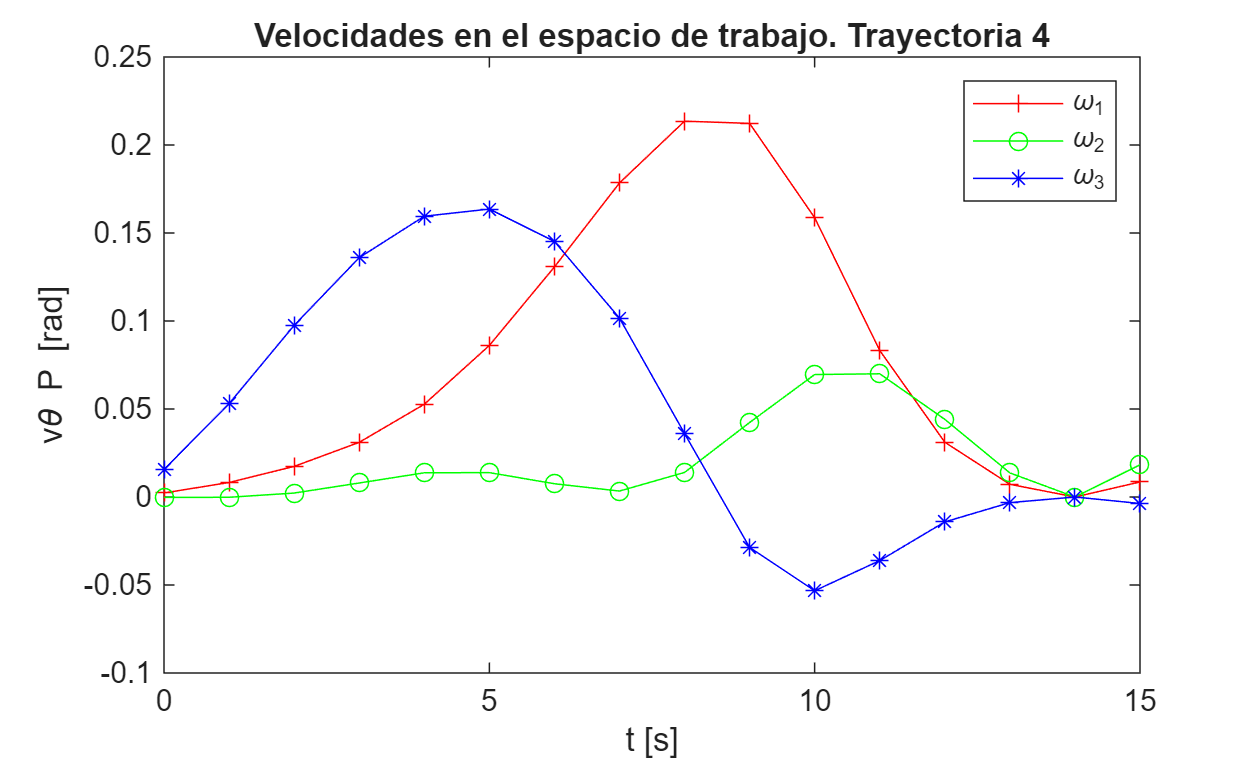

In [29]:

% Gráfica de las velocidades en el espacio de trabajo

figure;

plot(tsim, theta_1_v, 'r-+');
hold on;
plot(tsim, theta_2_v, 'g-o');
plot(tsim, theta_3_v, 'b-*');

hold off;

legend('\omega_1','\omega_2','\omega_3')
title("Velocidades en el espacio de trabajo. Trayectoria 4")
xlabel("t [s]")
ylabel("v\theta P [rad]")


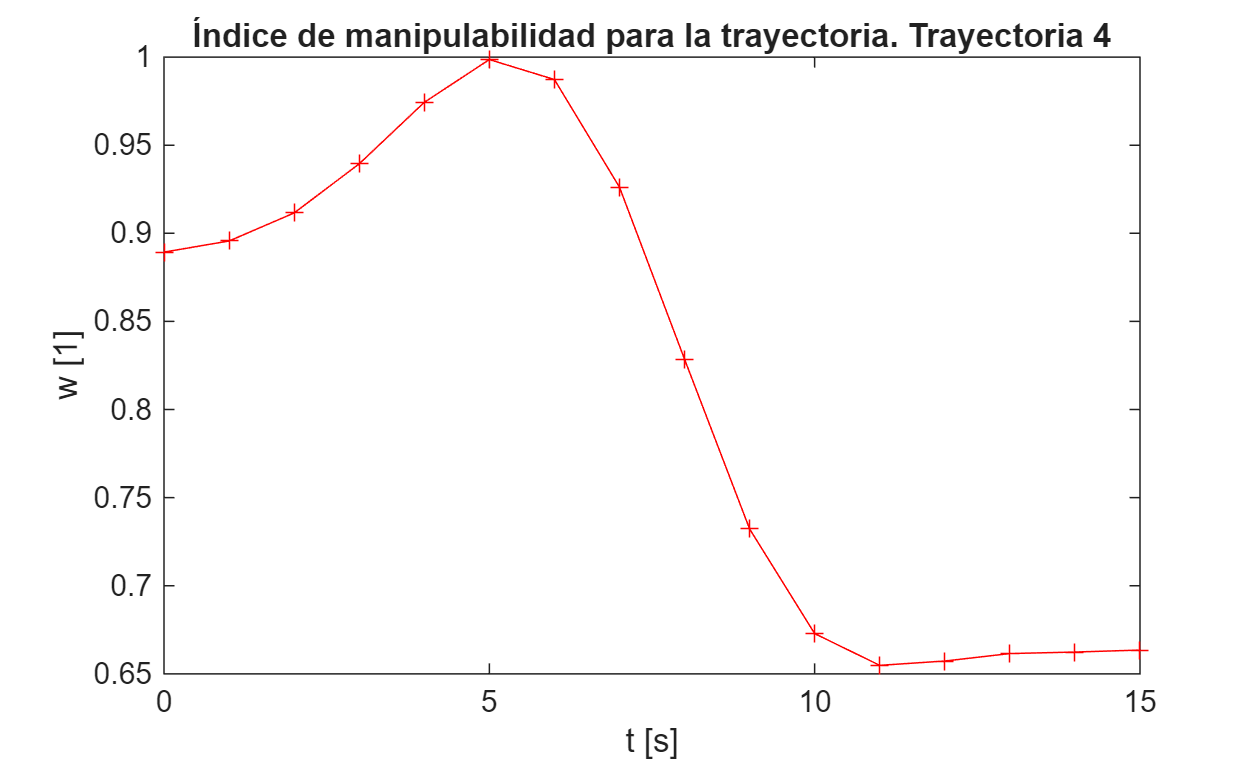

In [30]:

% Gráfica del índice de manipulabilidad

figure;

plot(tsim, w, 'r-+');

title("Índice de manipulabilidad para la trayectoria. Trayectoria 4")
xlabel("t [s]")
ylabel("w [1]")


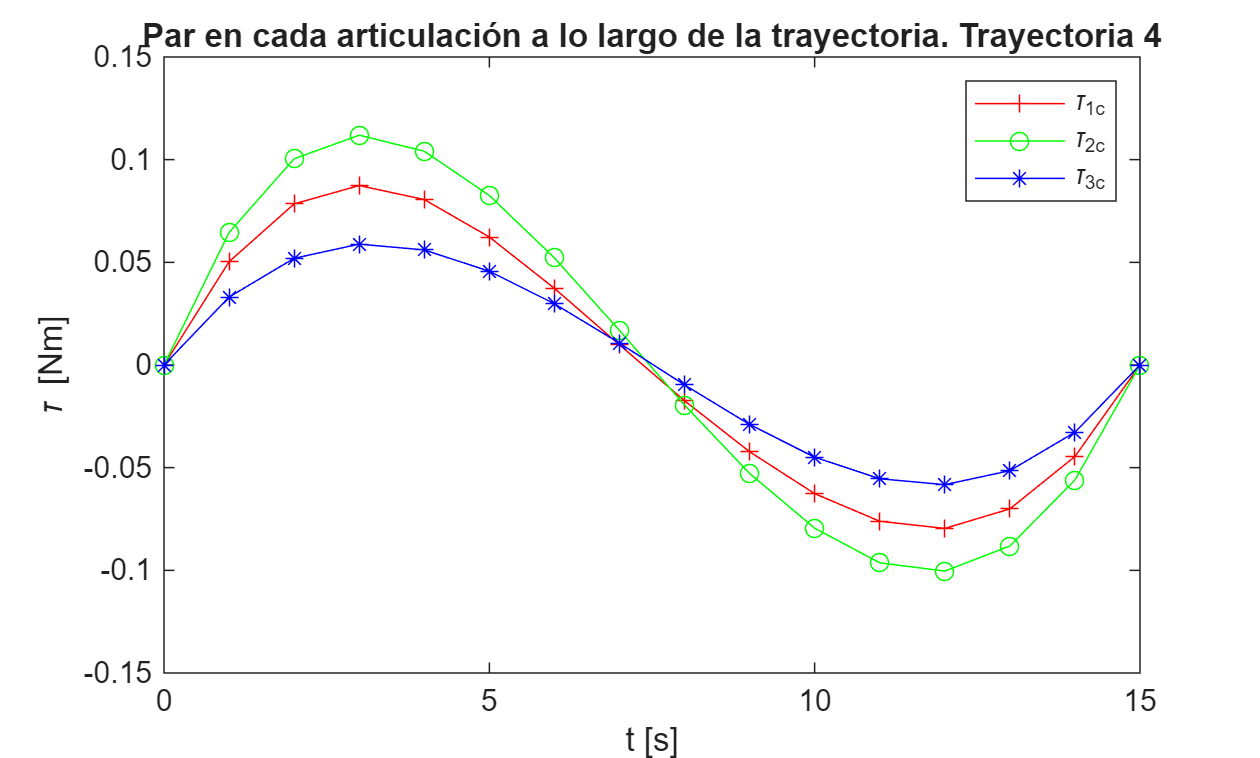

In [31]:

% Gráfica de los pares en las articulaciones

figure;

plot(tsim, tao_1_c, 'r-+');
hold on;
plot(tsim, tao_2_c, 'g-o');
plot(tsim, tao_3_c, 'b-*');

hold off;

legend('\tau_1_c','\tau_2_c','\tau_3_c')
title("Par en cada articulación a lo largo de la trayectoria. Trayectoria 4")
xlabel("t [s]")
ylabel("\tau [Nm]")


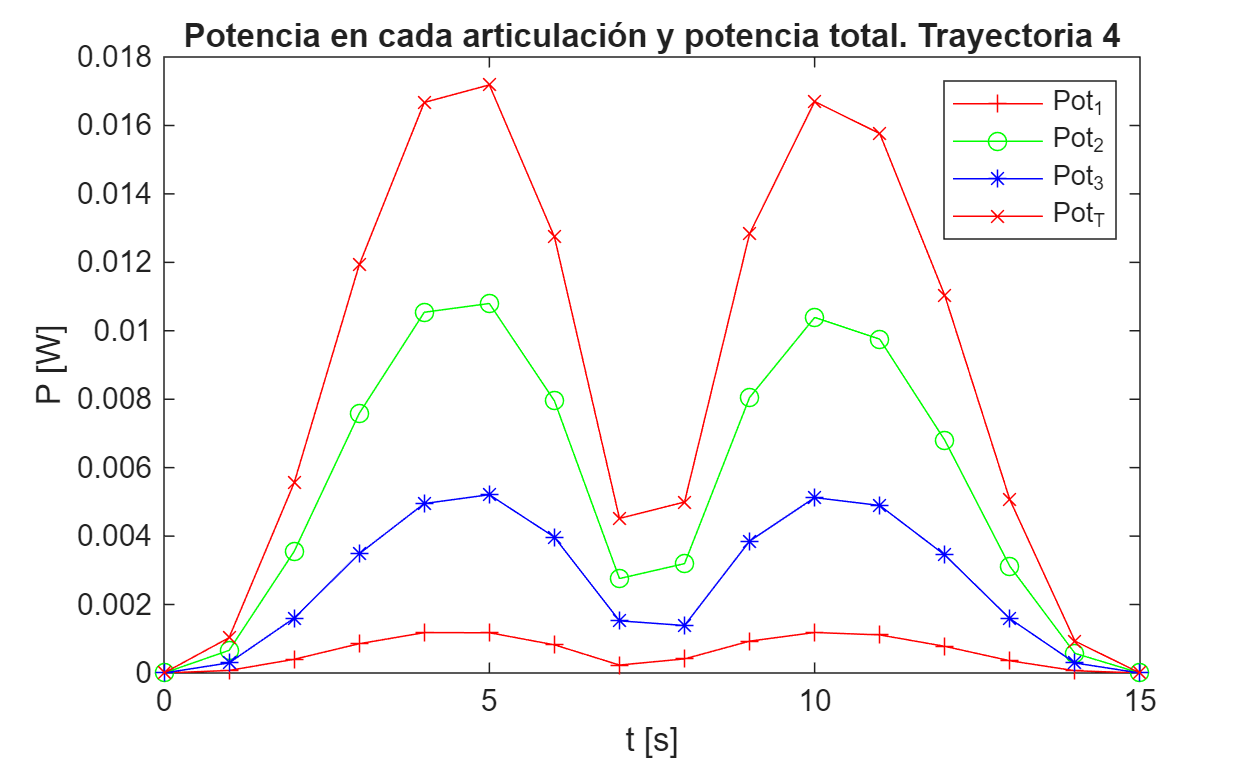

In [32]:

% Gráfica de la potencia en las articulaciones

figure;

plot(tsim, pot_1, 'r-+');
hold on;
plot(tsim, pot_2, 'g-o');
plot(tsim, pot_3, 'b-*');
plot(tsim, pot_total, 'r-x');

hold off;

legend('Pot_1','Pot_2','Pot_3','Pot_T')
title("Potencia en cada articulación y potencia total. Trayectoria 4")
xlabel("t [s]")
ylabel("P [W]")


## Trayectoria 5


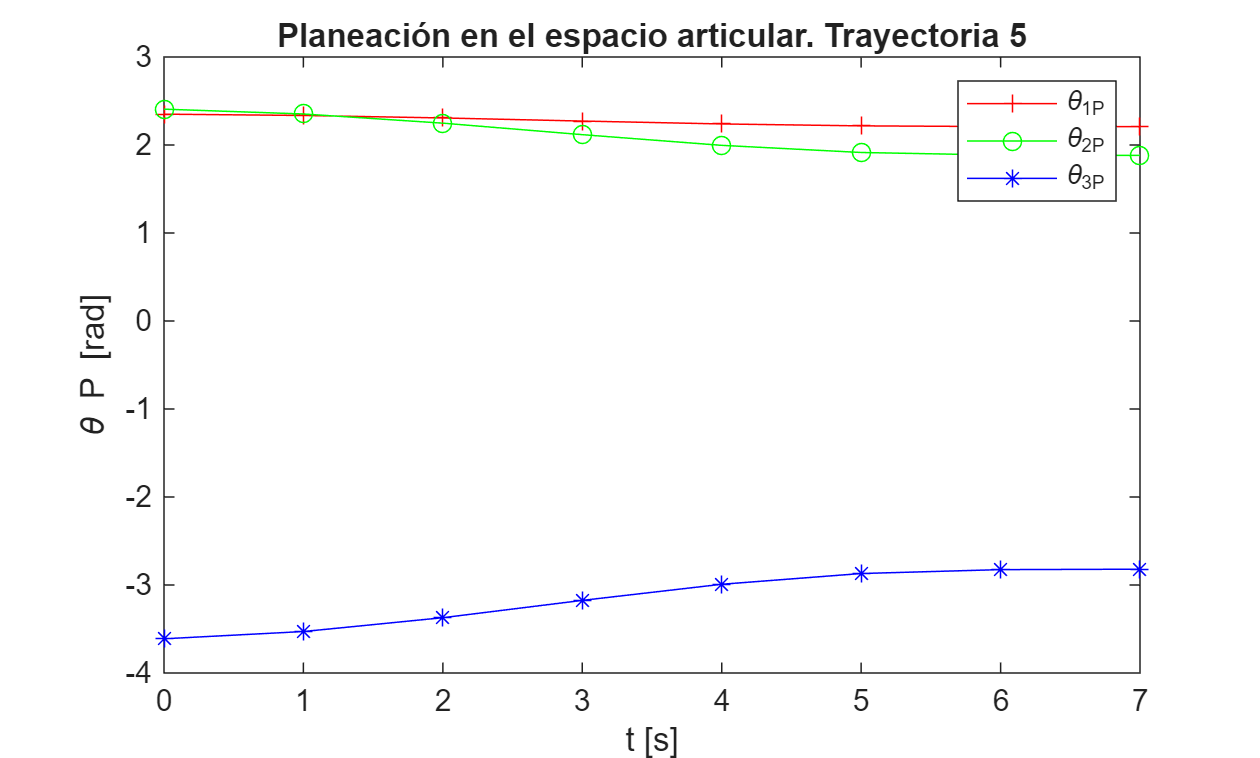

In [33]:
clear
clc

% 1) Definición de la postura inicial y final de la trayectoria

% Pose inicial
x_in = 0.25;
y_in = 0.55;
theta_in = 1.144; % 65.55°
% Pose final
x_fin = 0.25;
y_fin = 0.8;
theta_fin = 1.27; % 72.76°

% 2) Posición de la primer postura

% Definición de los parámetros del robot
L1 = 0.5; % Longitud del primer eslabón
L2 = 0.5; % Longitud del segundo eslabón
L3 = 0.25; % Longitud del tercer eslabón

% POSTURA DEL ROBOT PARA EL PUNTO INICIAL

x_3 = x_in - L3*cos(theta_in);
y_3 = y_in - L3*sin(theta_in);

% Solucion por el método geométrico

arg01 = (x_3^2+y_3^2-L1^2-L2^2)/(2*L1*L2);
arg01 = max(min(arg01,1),-1);
theta_2_in = acos(arg01);

beta = atan2(y_3,x_3);

arg02 = (x_3^2+y_3^2+L1^2-L2^2)/(2*L1*sqrt(x_3^2+y_3^2));
arg02 = max(min(arg02,1),-1);
psi = acos(arg02);

theta_1_in = beta + psi;

theta_3_in = theta_in -theta_1_in - theta_2_in;

% POSTURA DEL ROBOT PARA EL PUNTO FINAL

x_3 = x_fin - L3*cos(theta_fin);
y_3 = y_fin - L3*sin(theta_fin);

% Solucion por el método geométrico

arg01 = (x_3^2+y_3^2-L1^2-L2^2)/(2*L1*L2);
arg01 = max(min(arg01,1),-1);
theta_2_fin = acos(arg01);

beta = atan2(y_3,x_3);

arg02 = (x_3^2+y_3^2+L1^2-L2^2)/(2*L1*sqrt(x_3^2+y_3^2));
arg02 = max(min(arg02,1),-1);
psi = acos(arg02);

theta_1_fin = beta + psi;

theta_3_fin = theta_fin - theta_1_fin - theta_2_fin;

% 3) Trayectoria en el espacio de las juntas

tf = 7.5; % Se define un tiempo para que el robot haga su movimiento

for i=1:tf+1
    t = i; % Incremento de tiempo para la siguiente iteración
    theta_1_P(i) = theta_1_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_1_fin-theta_1_in);
    theta_2_P(i) = theta_2_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_2_fin-theta_2_in);
    theta_3_P(i) = theta_3_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_3_fin-theta_3_in);

end

% 4) Trayectoria en el espacio de trabajo

for i=1:tf+1
    t = i;
    x_P(i) = x_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(x_fin-x_in);
    y_P(i) = y_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(y_fin-y_in);
    theta_P(i) = theta_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_fin-theta_in);

    x_3_a(i) = x_P(i) - L3*cos(theta_P(i));
    y_3_a(i) = y_P(i) - L3*sin(theta_P(i));

    % Solucion por el método geométrico

    arg1 = ((x_3_a(i)^2+y_3_a(i)^2-L1^2-L2^2)/(2*L1*L2));
    arg1 = max(min(arg1,1),-1);  % limitar entre [-1,1]

    theta_2_tray(i) = acos(arg1);

    beta = atan2(y_3_a(i),x_3_a(i));

    arg2 = ((x_3_a(i)^2+y_3_a(i)^2+L1^2-L2^2)/(2*L1*sqrt(x_3_a(i)^2+y_3_a(i)^2)));
    arg2 = max(min(arg2,1),-1);  % limitar entre [-1,1]
    psi = acos(arg2);

    theta_1_tray(i) = beta + psi;

    theta_3_tray(i) = theta_P(i) - theta_1_tray(i) - theta_2_tray(i);

end

% 5) Velocidades y aceleraciones en el espacio de las juntas

for i=1:tf+1
    t = i-1;
    theta_1_P_v(i) =  ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_1_fin-theta_1_in);
    theta_2_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_2_fin-theta_2_in);
    theta_3_P_v(i) =  ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_3_fin-theta_3_in);

end

for i=1:tf+1
    t = i-1;
    theta_1_P_a(i) =  ((60/tf^3)*t - (180/tf^4)*t^2 + (120/tf^5)*t^3)*(theta_1_fin-theta_1_in);
    theta_2_P_a(i) = ((60/tf^3)*t - (180/tf^4)*t^2 + (120/tf^5)*t^3)*(theta_2_fin-theta_2_in);
    theta_3_P_a(i) =  ((60/tf^3)*t - (180/tf^4)*t^2 + (120/tf^5)*t^3)*(theta_3_fin-theta_3_in);

end

% 6) Velocidades en el espacio de trabajo

for i=1:tf+1
    t = i;
    x_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(x_fin-x_in);
    y_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(y_fin-y_in);
    theta_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_fin-theta_in);

    x_dot = x_P_v(i);
    y_dot = y_P_v(i);
    theta_dot_P = theta_P_v(i);

    theta_O_1 = theta_1_tray(i);
    theta_1_2 = theta_2_tray(i);
    theta_2_3 = theta_3_tray(i);

    theta_1_v(i) = (x_dot*cos(theta_1_2 + theta_O_1))/(L1*sin(theta_1_2)) + (y_dot*sin(theta_1_2 + theta_O_1))/(L1*sin(theta_1_2)) + (L3*theta_dot_P*sin(theta_2_3))/(L1*sin(theta_1_2));
    theta_2_v(i) = - (x_dot*(L2*cos(theta_1_2 + theta_O_1) + L1*cos(theta_O_1)))/(L1*L2*sin(theta_1_2)) - (y_dot*(L2*sin(theta_1_2 + theta_O_1) + L1*sin(theta_O_1)))/(L1*L2*sin(theta_1_2)) - (L3*theta_dot_P*(L1*sin(theta_1_2 + theta_2_3) + L2*sin(theta_2_3)))/(L1*L2*sin(theta_1_2));
    theta_3_v(i) = (theta_dot_P*(L3*sin(theta_1_2 + theta_2_3) + L2*sin(theta_1_2)))/(L2*sin(theta_1_2)) + (x_dot*cos(theta_O_1))/(L2*sin(theta_1_2)) + (y_dot*sin(theta_O_1))/(L2*sin(theta_1_2));


end

% 7) Índice de manipulabilidad

for i=1:tf+1

    w(i) = abs(sin(theta_2_P(i)));

end

% 8) Cálculo de los pares en cada junta

for i=1:tf+1

    theta_1 = theta_1_P(i);
    theta_2 = theta_2_P(i);
    theta_3 = theta_3_P(i);

    theta_1_vc = theta_1_P_v(i);
    theta_2_vc = theta_2_P_v(i);
    theta_3_vc = theta_3_P_v(i);

    theta_1_a = theta_1_P_a(i);
    theta_2_a = theta_2_P_a(i);
    theta_3_a = theta_3_P_a(i);

    sigma_19 = sin(theta_2+theta_1)/2;
    sigma_18 = sin(theta_1+theta_2+theta_3);
    sigma_17 = cos(theta_2+theta_1)/2;
    sigma_16 = cos(theta_1+theta_2+theta_3);

    sigma_15 = theta_2_vc*(sigma_18/8 + sigma_19);
    sigma_14 = sigma_18/8 + sigma_19 + sin(theta_1)/2;
    sigma_13 = theta_2_vc *(sigma_16/8 +sigma_17);
    sigma_12 = sigma_16/8 +sigma_17 +cos(theta_1)/2;
    sigma_11 = theta_3_vc*sigma_18/8 + theta_1_vc*sigma_14 +sigma_15;
    sigma_10 = sigma_13 + theta_3_vc*sigma_16/8 +theta_1_vc*sigma_12;
    sigma_9 = ((sigma_16/8 + sigma_17)*sigma_11)/2;
    sigma_8 = ((sigma_18/8 + sigma_19)*sigma_10)/2;
    sigma_7 = (sigma_16*(sigma_16/8 + sigma_17))/16 + (sigma_18*(sigma_18/8 + sigma_19))/16 + 1;
    sigma_6 = sigma_16*sigma_12/16 + sigma_18*sigma_14 + 1;
    sigma_5 = theta_2_vc*sigma_16/8 + theta_3_vc*sigma_16/8 + theta_1_vc*sigma_16/8;
    sigma_4 = theta_2_vc*sigma_18/8 + theta_3_vc*sigma_18/8 + theta_1_vc*sigma_18/8;
    sigma_3 = cos(theta_2)/8 + ((sigma_16/8 + sigma_17)*sigma_12)/2 + ((sigma_18/8 + sigma_19)*sigma_14)/2 + 33/16;
    sigma_2 = sigma_13 +theta_1_vc*(sigma_16/8 + sigma_17) + theta_3_vc*sigma_16/8;
    sigma_1 = theta_3_vc*sigma_18/8 + sigma_15 +theta_1_vc*(sigma_18/8 + sigma_19);

    tao_1_c(i) = theta_1_a*(cos(theta_2)/4 + sigma_12^2/2 + sigma_14^2/2 + 27/8) - theta_3_vc* (sigma_18*sigma_10/16 - sigma_16*sigma_11/16 + sigma_12*sigma_4/2 - sigma_5*sigma_14/2) + theta_2_a*sigma_3 + theta_3_a*sigma_6 - theta_2_vc*(sigma_8 - sigma_14*sigma_2/2 + sigma_1*sigma_12/2 - sigma_9 + theta_2_vc*sin(theta_2)/8 + theta_1_vc*sin(theta_2)/4);
    tao_2_c(i) = theta_1_vc^2*sin(theta_2)/8 - theta_3_vc*(sigma_18*sigma_10 - ((sigma_18/8 + sigma_19)*sigma_5)/2 + ((sigma_16/8 + sigma_17)*sigma_4)/2 - sigma_16*sigma_11/16) + theta_2_a*sigma_7 + sigma_10*sigma_1/2 + theta_1_a*sigma_3 - sigma_11*sigma_2/2 + theta_2_a*(((sigma_16 + sigma_17)^2)/2 + ((sigma_18 + sigma_19)^2)/2 + 33/16) - theta_2_vc*((sigma_16/8 + sigma_17)*sigma_1/2 + (sigma_18/8 + sigma_19)*sigma_2/2 + sigma_8 - sigma_9 + theta_1_vc*sin(theta_2)/8) + theta_2_vc*theta_1_vc*sin(theta_2)/8;
    tao_3_c(i) = theta_3_a*(sigma_16^2/128 + sigma_18^2/128 + 1 ) - sigma_5*sigma_11/2 + theta_2_a*sigma_7 - theta_3_vc*(sigma_18*sigma_10/16 - sigma_18*sigma_5/16 - sigma_16*sigma_11/16 + sigma_16*sigma_4/16) + theta_2_vc*(sigma_18*sigma_2/16 - sigma_18*sigma_10/16 - sigma_16*sigma_1/16 + sigma_16*sigma_11/16) + theta_1_a*sigma_6 + sigma_10*sigma_4/2;

end

% 9) Cálculo de la potencia por junta y total

for i=1:tf+1
    theta_1_vc = theta_1_P_v(i);
    theta_2_vc = theta_2_P_v(i);
    theta_3_vc = theta_3_P_v(i);

    pot_1(i) = abs(tao_1_c(i)*theta_1_vc);
    pot_2(i) = abs(tao_2_c(i)*theta_2_vc);
    pot_3(i) = abs(tao_3_c(i)*theta_3_vc);
    pot_total(i) = pot_1(i) + pot_2(i) + pot_3(i);
end

% 10) Gráficas

tsim = 0:1:tf; % tiempo de simulación para las gráficas

% Gráfica de la trayectoria en el espacio de las juntas

figure;

plot(tsim, theta_1_P, 'r-+');
hold on;
plot(tsim, theta_2_P, 'g-o');
plot(tsim, theta_3_P, 'b-*');

hold off;

xlim auto
ylim auto
legend('\theta_1_P','\theta_2_P','\theta_3_P')
title("Planeación en el espacio articular. Trayectoria 5")
xlabel("t [s]")
ylabel("\theta P [rad]")


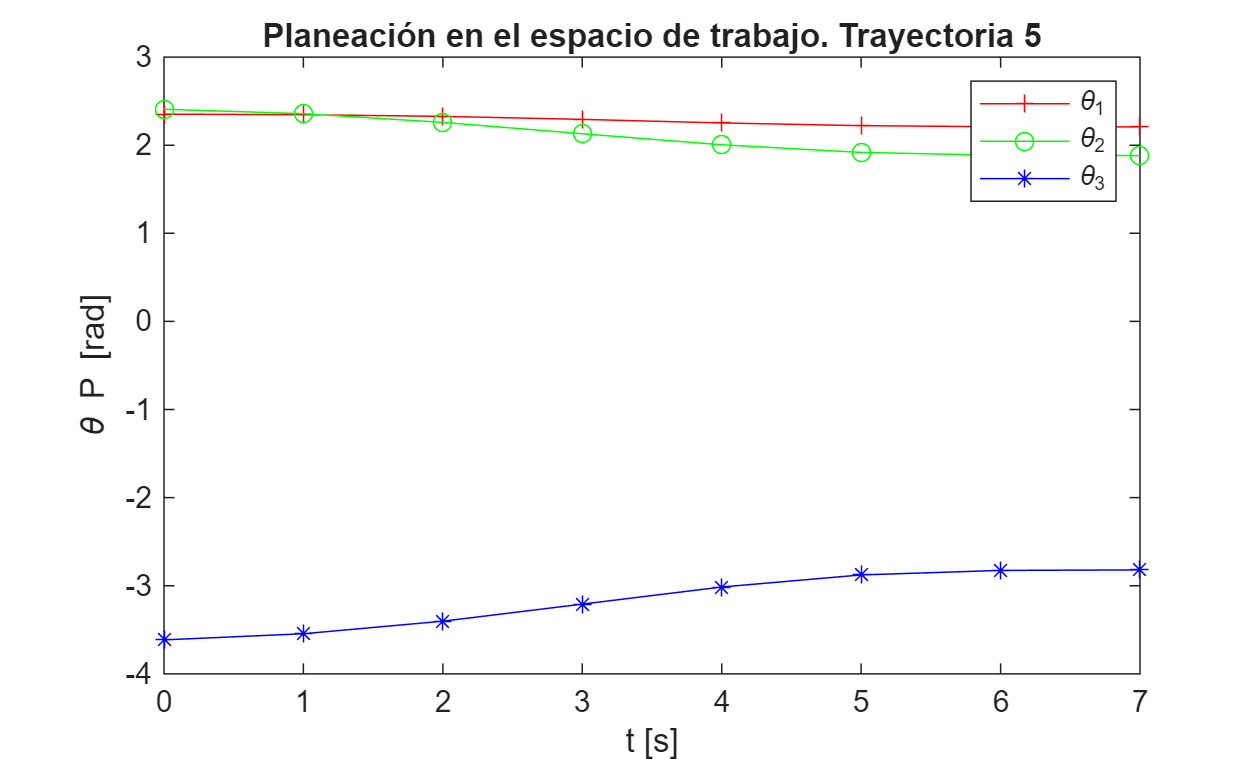

In [34]:

% Gráfica de la trayectoria en el espacio de trabajo

figure;

plot(tsim, theta_1_tray, 'r-+');
hold on;
plot(tsim, theta_2_tray, 'g-o');
plot(tsim, theta_3_tray, 'b-*');

hold off;

xlim auto
ylim auto
legend('\theta_1','\theta_2','\theta_3')
title("Planeación en el espacio de trabajo. Trayectoria 5")
xlabel("t [s]")
ylabel("\theta P [rad]")


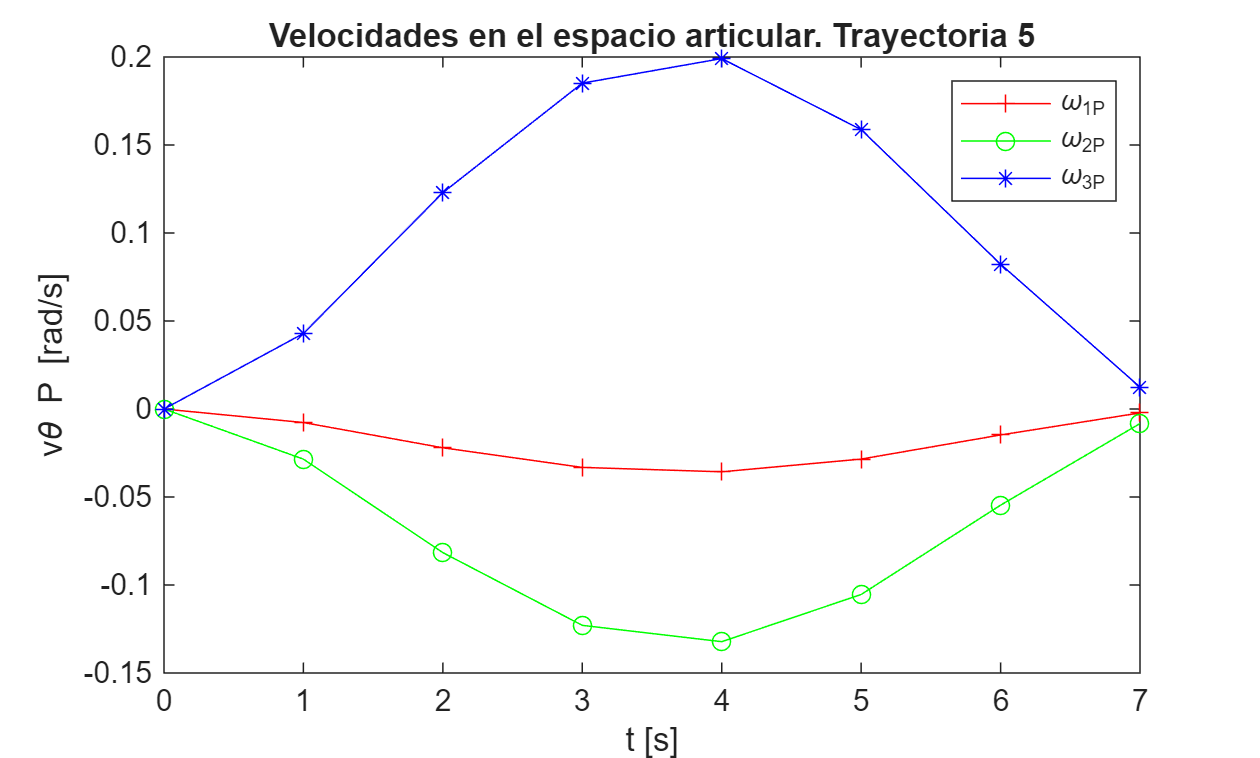

In [35]:

% Gráfica de las velocidades en el espacio articular

figure;

plot(tsim, theta_1_P_v, 'r-+');
hold on;
plot(tsim, theta_2_P_v, 'g-o');
plot(tsim, theta_3_P_v, 'b-*');

hold off;

legend('\omega_1_P','\omega_2_P','\omega_3_P')
title("Velocidades en el espacio articular. Trayectoria 5")
xlabel("t [s]")
ylabel("v\theta P [rad/s]")


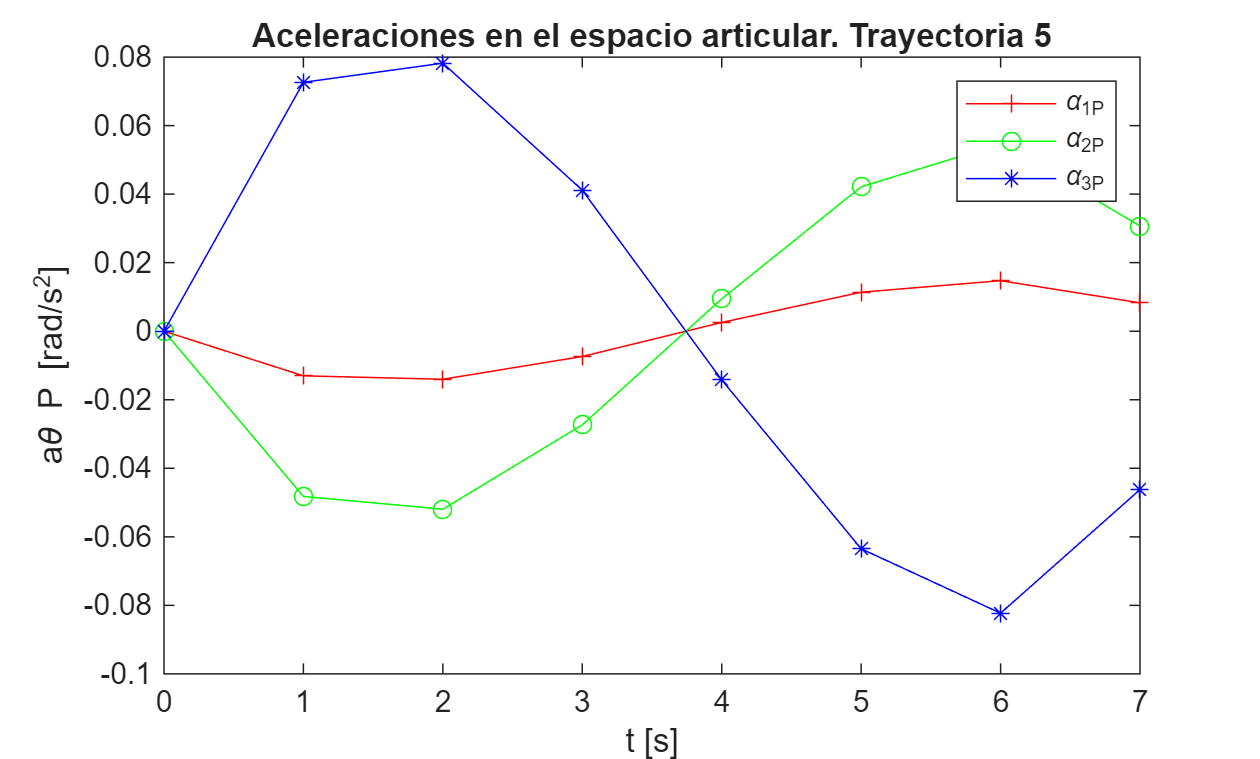

In [36]:

% Gráfica de las aceleraciones en el espacio articular

figure;

plot(tsim, theta_1_P_a, 'r-+');
hold on;
plot(tsim, theta_2_P_a, 'g-o');
plot(tsim, theta_3_P_a, 'b-*');

hold off;

legend('\alpha_1_P','\alpha_2_P','\alpha_3_P')
title("Aceleraciones en el espacio articular. Trayectoria 5")
xlabel("t [s]")
ylabel("a\theta P [rad/s^2]")


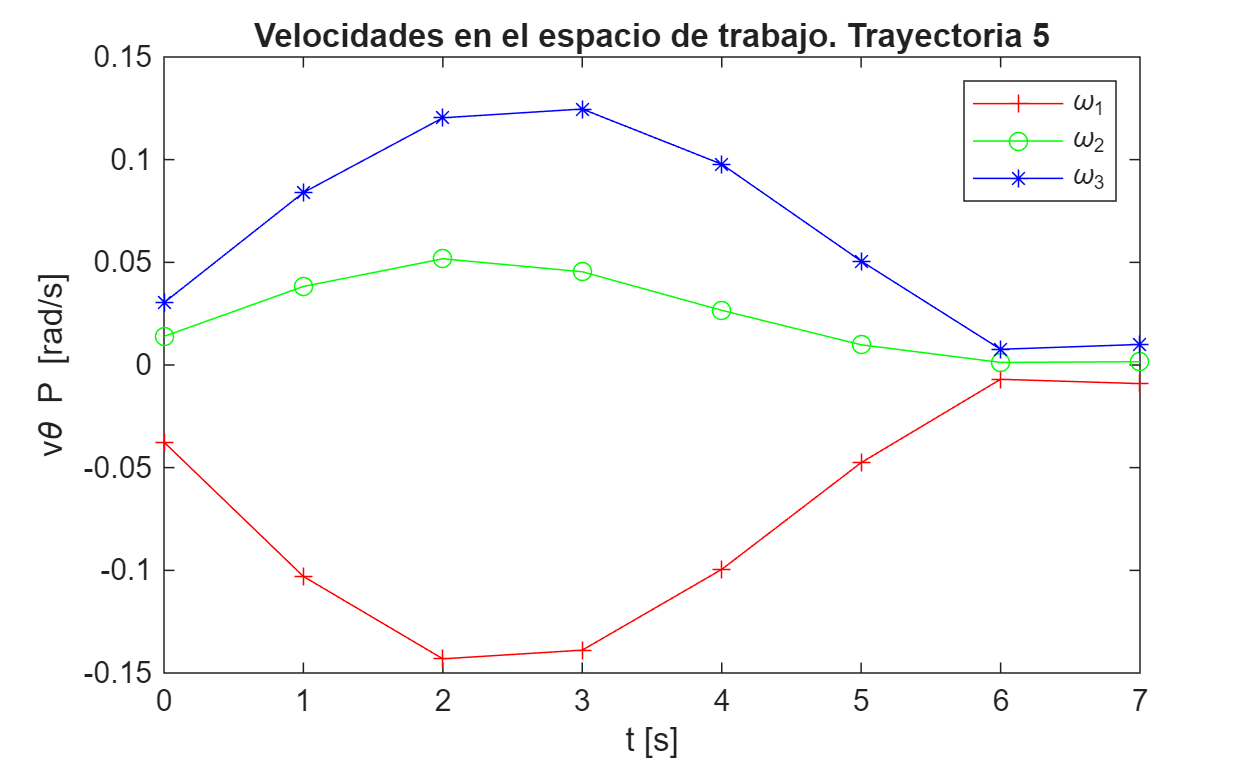

In [37]:

% Gráfica de las velocidades en el espacio de trabajo

figure;

plot(tsim, theta_1_v, 'r-+');
hold on;
plot(tsim, theta_2_v, 'g-o');
plot(tsim, theta_3_v, 'b-*');

hold off;

legend('\omega_1','\omega_2','\omega_3')
title("Velocidades en el espacio de trabajo. Trayectoria 5")
xlabel("t [s]")
ylabel("v\theta P [rad/s]")


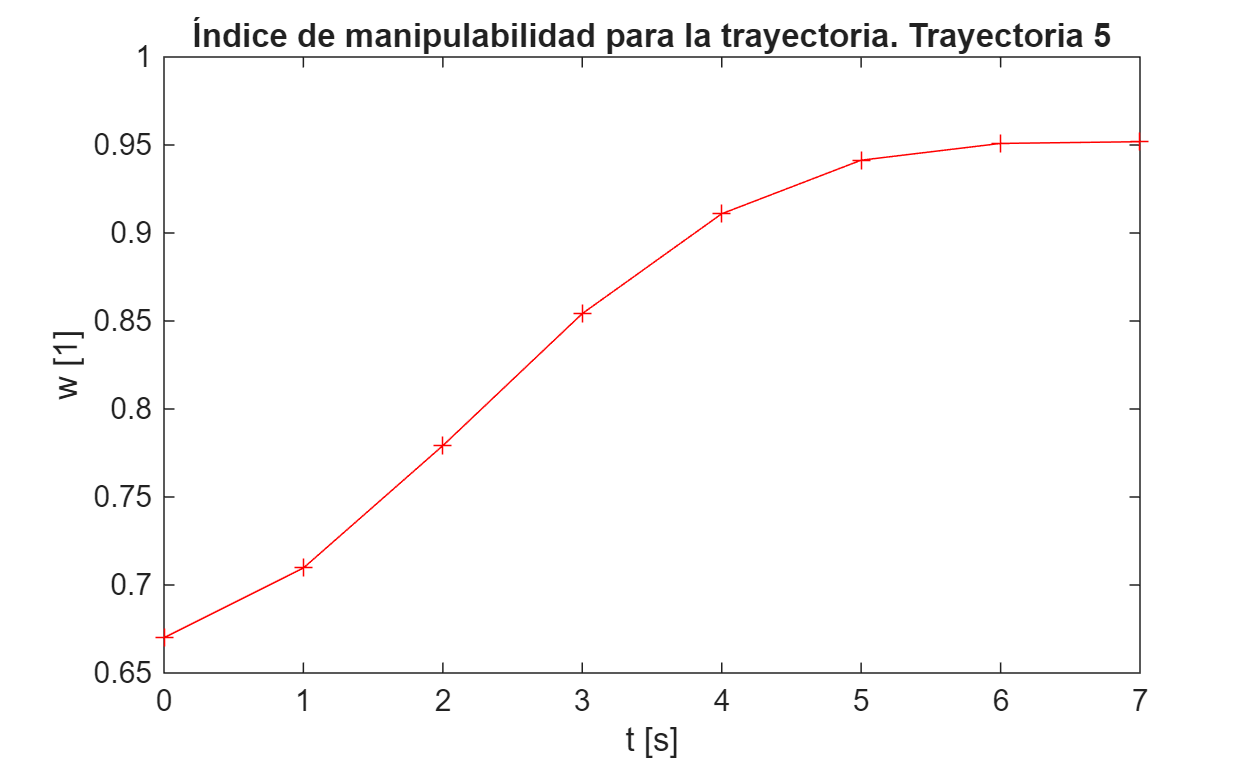

In [38]:

% Gráfica del índice de manipulabilidad

figure;

plot(tsim, w, 'r-+');

title("Índice de manipulabilidad para la trayectoria. Trayectoria 5")
xlabel("t [s]")
ylabel("w [1]")


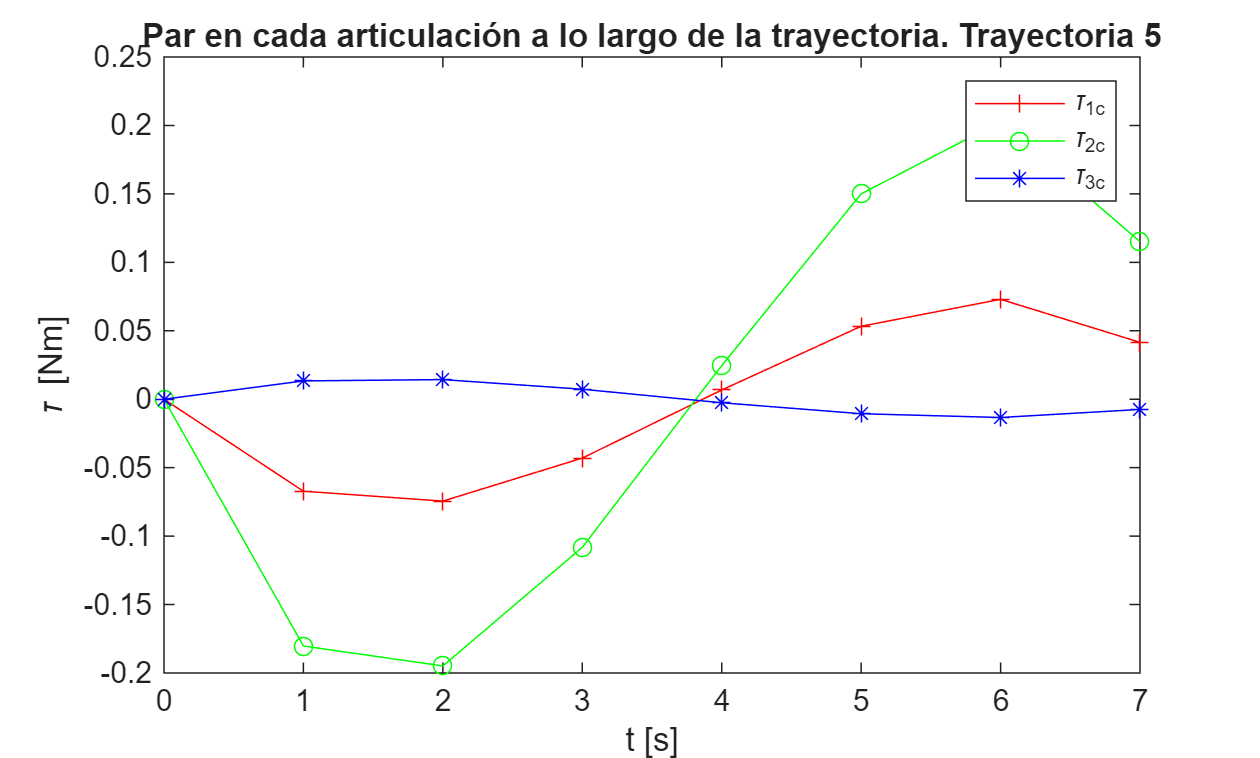

In [39]:

% Gráfica de los pares en las articulaciones

figure;

plot(tsim, tao_1_c, 'r-+');
hold on;
plot(tsim, tao_2_c, 'g-o');
plot(tsim, tao_3_c, 'b-*');

hold off;

legend('\tau_1_c','\tau_2_c','\tau_3_c')
title("Par en cada articulación a lo largo de la trayectoria. Trayectoria 5")
xlabel("t [s]")
ylabel("\tau [Nm]")


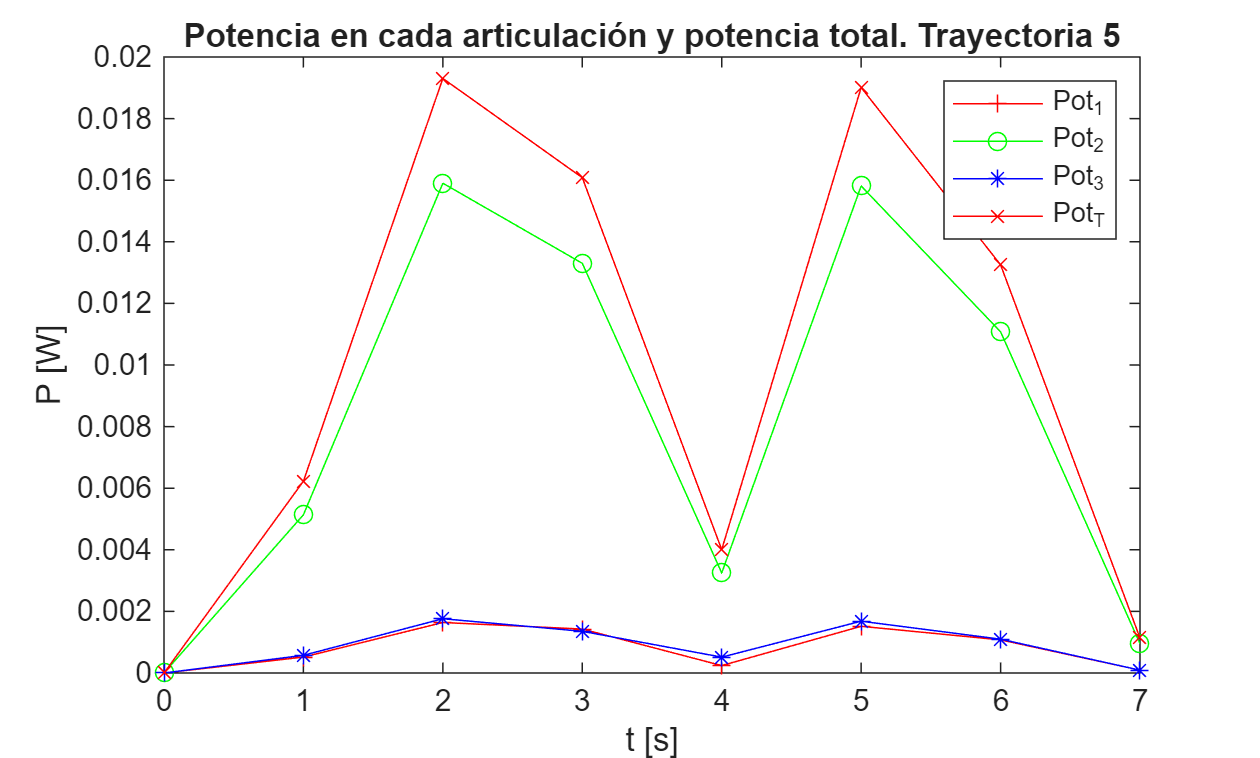

In [40]:

% Gráfica de la potencia en las articulaciones

figure;

plot(tsim, pot_1, 'r-+');
hold on;
plot(tsim, pot_2, 'g-o');
plot(tsim, pot_3, 'b-*');
plot(tsim, pot_total, 'r-x');

hold off;

legend('Pot_1','Pot_2','Pot_3','Pot_T')
title("Potencia en cada articulación y potencia total. Trayectoria 5")
xlabel("t [s]")
ylabel("P [W]")



$${\ddot{\theta} }_{O,1} \,{\left(\frac{\cos \left(\theta_{1,2} \right)}{4}+\frac{{\sigma_{12} }^2 }{2}+\frac{{\sigma_{14} }^2 }{2}+\frac{27}{8}\right)}-{\dot{\theta} }_{2,3} \,{\left(\frac{\sigma_{18} \,\sigma_{10} }{16}-\frac{\sigma_{16} \,\sigma_{11} }{16}+\frac{\sigma_{12} \,\sigma_4 }{2}-\frac{\sigma_5 \,\sigma_{14} }{2}\right)}+{\ddot{\theta} }_{1,2} \,\sigma_3 +{\ddot{\theta} }_{2,3} \,\sigma_6 -{\dot{\theta} }_{1,2} \,{\left(\sigma_8 -\frac{\sigma_{14} \,\sigma_2 }{2}+\frac{\sigma_1 \,\sigma_{12} }{2}-\sigma_9 +\frac{{\dot{\theta} }_{1,2} \,\sin \left(\theta_{1,2} \right)}{8}+\frac{{\dot{\theta} }_{O,1} \,\sin \left(\theta_{1,2} \right)}{4}\right)}$$

$$\frac{{{\dot{\theta} }_{O,1} }^2 \,\sin \left(\theta_{1,2} \right)}{8}-{\dot{\theta} }_{2,3} \,{\left(\frac{\sigma_{18} \,\sigma_{10} }{16}-\frac{{\left(\frac{\sigma_{18} }{8}+\sigma_{19} \right)}\,\sigma_5 }{2}+\frac{{\left(\frac{\sigma_{16} }{8}+\sigma_{17} \right)}\,\sigma_4 }{2}-\frac{\sigma_{16} \,\sigma_{11} }{16}\right)}+{\ddot{\theta} }_{2,3} \,\sigma_7 +\frac{\sigma_{10} \,\sigma_1 }{2}+{\ddot{\theta} }_{O,1} \,\sigma_3 -\frac{\sigma_{11} \,\sigma_2 }{2}+{\ddot{\theta} }_{1,2} \,{\left(\frac{{{\left(\frac{\sigma_{16} }{8}+\sigma_{17} \right)}}^2 }{2}+\frac{{{\left(\frac{\sigma_{18} }{8}+\sigma_{19} \right)}}^2 }{2}+\frac{33}{16}\right)}-{\dot{\theta} }_{1,2} \,{\left(\frac{{\left(\frac{\sigma_{16} }{8}+\sigma_{17} \right)}\,\sigma_1 }{2}-\frac{{\left(\frac{\sigma_{18} }{8}+\sigma_{19} \right)}\,\sigma_2 }{2}+\sigma_8 -\sigma_9 +\frac{{\dot{\theta} }_{O,1} \,\sin \left(\theta_{1,2} \right)}{8}\right)}+\frac{{\dot{\theta} }_{1,2} \,{\dot{\theta} }_{O,1} \,\sin \left(\theta_{1,2} \right)}{8}$$

$${\ddot{\theta} }_{2,3} \,{\left(\frac{{\sigma_{16} }^2 }{128}+\frac{{\sigma_{18} }^2 }{128}+1\right)}-\frac{\sigma_5 \,\sigma_{11} }{2}+{\ddot{\theta} }_{1,2} \,\sigma_7 -{\dot{\theta} }_{2,3} \,{\left(\frac{\sigma_{18} \,\sigma_{10} }{16}-\frac{\sigma_{18} \,\sigma_5 }{16}-\frac{\sigma_{16} \,\sigma_{11} }{16}+\frac{\sigma_{16} \,\sigma_4 }{16}\right)}+{\dot{\theta} }_{1,2} \,{\left(\frac{\sigma_{18} \,\sigma_2 }{16}-\frac{\sigma_{18} \,\sigma_{10} }{16}-\frac{\sigma_{16} \,\sigma_1 }{16}+\frac{\sigma_{16} \,\sigma_{11} }{16}\right)}+{\ddot{\theta} }_{O,1} \,\sigma_6 +\frac{\sigma_{10} \,\sigma_4 }{2}$$

**donde:**


$$\sigma_1 =\frac{{\dot{\theta} }_{2,3} \,\sigma_{18} }{8}+\sigma_{15} +{\dot{\theta} }_{O,1} \,{\left(\frac{\sigma_{18} }{8}+\sigma_{19} \right)}$$

$$\sigma_2 =\sigma_{13} +{\dot{\theta} }_{O,1} \,{\left(\frac{\sigma_{16} }{8}+\sigma_{17} \right)}+\frac{{\dot{\theta} }_{2,3} \,\sigma_{16} }{8}$$

$$\sigma_3 =\frac{\cos \left(\theta_{1,2} \right)}{8}+\frac{{\left(\frac{\sigma_{16} }{8}+\sigma_{17} \right)}\,\sigma_{12} }{2}+\frac{{\left(\frac{\sigma_{18} }{8}+\sigma_{19} \right)}\,\sigma_{14} }{2}+\frac{33}{16}$$

$$\sigma_4 =\frac{{\dot{\theta} }_{1,2} \,\sigma_{18} }{8}+\frac{{\dot{\theta} }_{2,3} \,\sigma_{18} }{8}+\frac{{\dot{\theta} }_{O,1} \,\sigma_{18} }{8}$$

$$\sigma_5 =\frac{{\dot{\theta} }_{1,2} \,\sigma_{16} }{8}+\frac{{\dot{\theta} }_{2,3} \,\sigma_{16} }{8}+\frac{{\dot{\theta} }_{O,1} \,\sigma_{16} }{8}$$

$$\sigma_6 =\frac{\sigma_{16} \,\sigma_{12} }{16}+\frac{\sigma_{18} \,\sigma_{14} }{16}+1$$

$$\sigma_7 =\frac{\sigma_{16} \,{\left(\frac{\sigma_{16} }{8}+\sigma_{17} \right)}}{16}+\frac{\sigma_{18} \,{\left(\frac{\sigma_{18} }{8}+\sigma_{19} \right)}}{16}+1$$

$$\sigma_8 =\frac{{\left(\frac{\sigma_{18} }{8}+\sigma_{19} \right)}\,\sigma_{10} }{2}$$

$$\sigma_9 =\frac{{\left(\frac{\sigma_{16} }{8}+\sigma_{17} \right)}\,\sigma_{11} }{2}$$

$$\sigma_{10} =\sigma_{13} +\frac{{\dot{\theta} }_{2,3} \,\sigma_{16} }{8}+{\dot{\theta} }_{O,1} \,\sigma_{12}$$

$$\sigma_{11} =\frac{{\dot{\theta} }_{2,3} \,\sigma_{18} }{8}+{\dot{\theta} }_{O,1} \,\sigma_{14} +\sigma_{15}$$

$$\sigma_{12} =\frac{\sigma_{16} }{8}+\sigma_{17} +\frac{\cos \left(\theta_{O,1} \right)}{2}$$

$$\sigma_{13} ={\dot{\theta} }_{1,2} \,{\left(\frac{\sigma_{16} }{8}+\sigma_{17} \right)}$$

$$\sigma_{14} =\frac{\sigma_{18} }{8}+\sigma_{19} +\frac{\sin \left(\theta_{O,1} \right)}{2}$$

$$\sigma_{15} ={\dot{\theta} }_{1,2} \,{\left(\frac{\sigma_{18} }{8}+\sigma_{19} \right)}$$

$$\sigma_{16} =\cos \left(\theta_{1,2} +\theta_{2,3} +\theta_{O,1} \right)$$

$$\sigma_{17} =\frac{\cos \left(\theta_{1,2} +\theta_{O,1} \right)}{2}$$

$$\sigma_{18} =\sin \left(\theta_{1,2} +\theta_{2,3} +\theta_{O,1} \right)$$

$$\sigma_{19} =\frac{\sin \left(\theta_{1,2} +\theta_{O,1} \right)}{2}$$
